# Initialization

In [1]:
# ---- Patch 0: safer GPU config (run once, near the top) ----
import tensorflow as tf
tf.config.set_soft_device_placement(True)  # let TF fallback to CPU if needed

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPU(s) found and memory growth enabled: {gpus}")
    except Exception as e:
        print("Could not enable memory growth:", e)
else:
    print("No GPU detected; running on CPU.")


2025-08-30 17:06:12.536864: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-30 17:06:12.957383: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-08-30 17:06:13.682260: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


GPU(s) found and memory growth enabled: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


2025-08-30 17:06:16.795578: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-08-30 17:06:16.975479: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-08-30 17:06:16.975629: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

In [2]:
import glob
import numpy as np

npy_files = glob.glob('cached_np/*.npy')
data_arrays = {file.split('/')[-1].replace('.npy', ''): np.load(file) for file in npy_files}

print(f"Loaded {len(data_arrays)} variables from .npy files.")


Loaded 7 variables from .npy files.


# Preprocessing

In [3]:
vars_to_check = [
    'X_all',
    'Y_all',
    'wrench_all',
    'Z_all',
    'angles_all',
    'wrench_out_all',
    'currents_all'
]

for name in vars_to_check:
    if name in data_arrays:
        arr = np.array(data_arrays[name])
        print(f"{name}: shape={arr.shape}, dtype={arr.dtype}, "
              f"min={np.nanmin(arr):.6f}, max={np.nanmax(arr):.6f}, "
              f"NaNs={np.isnan(arr).sum()}")
    else:
        print(f"{name}: NOT FOUND in data_arrays")


X_all: shape=(1, 1411344), dtype=float64, min=-0.150000, max=0.150000, NaNs=0
Y_all: shape=(1, 1411344), dtype=float64, min=-0.150000, max=0.150000, NaNs=0
wrench_all: shape=(6, 1411344), dtype=float64, min=-71.323061, max=67.910946, NaNs=0
Z_all: shape=(1, 1411344), dtype=float64, min=0.005000, max=0.005000, NaNs=0
angles_all: shape=(3, 1411344), dtype=float64, min=-3.141593, max=3.141593, NaNs=0
wrench_out_all: shape=(6, 1411344), dtype=float64, min=-43712933.130251, max=36944979.677285, NaNs=0
currents_all: shape=(16, 1411344), dtype=float64, min=-5885.689556, max=16889.743946, NaNs=0


In [4]:
# Build ARR as [N,16] from whatever you loaded. Then re-run the previous analysis cell.

import numpy as np

def find_currents_matrix(dct):
    # 2D with 16 cols
    for v in dct.values():
        a = np.array(v)
        if a.ndim == 2 and a.shape[1] == 16:
            return a
    # 2D with 16 rows -> transpose
    for v in dct.values():
        a = np.array(v)
        if a.ndim == 2 and a.shape[0] == 16:
            return a.T
    # 1D or weird -> reshape by 16
    for v in dct.values():
        a = np.array(v).ravel()
        if a.size % 16 == 0 and a.size >= 16:
            return a.reshape(-1, 16)
    raise ValueError("No 16-current structure found in data_arrays.")

ARR = find_currents_matrix(data_arrays)
print("ARR shape:", ARR.shape)

ARR shape: (1411344, 16)


In [5]:
# Ensure shape is [N_samples, N_channels]
W = np.array(data_arrays['wrench_out_all'], dtype=float)
if W.shape[0] < W.shape[1]:
    W = W.T  # transpose to get samples as rows

print("Fixed wrench_out_all shape:", W.shape)  # should be (1895400, 6)

Fixed wrench_out_all shape: (1411344, 6)


In [6]:
import numpy as np

# Preprocess into sample-aligned arrays

def to_samples_first(arr):
    arr = np.array(arr, dtype=float)
    if arr.shape[0] < arr.shape[1]:
        arr = arr.T
    return arr

# Flatten small coordinate arrays
def flatten_coord(arr):
    return np.array(arr, dtype=float).ravel()

X_all = flatten_coord(data_arrays['X_all'])
Y_all = flatten_coord(data_arrays['Y_all'])
Z_all = flatten_coord(data_arrays['Z_all'])
angles_all = np.array(data_arrays['angles_all'], dtype=float)
if angles_all.shape[0] < angles_all.shape[1]:
    angles_all = angles_all.T  # now shape [N, 3]

wrench_all = to_samples_first(data_arrays['wrench_all'])          # [N, 6]
wrench_out_all = to_samples_first(data_arrays['wrench_out_all'])  # [N, 6]
currents_all = to_samples_first(data_arrays['currents_all'])      # [N, 16]

# Sanity check: all sample counts
N_samples = max(len(X_all), wrench_all.shape[0], currents_all.shape[0])
print("Sample counts:")
print(f"X_all:           {X_all.shape}")
print(f"Y_all:           {Y_all.shape}")
print(f"Z_all:           {Z_all.shape}")
print(f"angles_all:      {angles_all.shape}")
print(f"wrench_all:      {wrench_all.shape}")
print(f"wrench_out_all:  {wrench_out_all.shape}")
print(f"currents_all:    {currents_all.shape}")

# Verify alignment
if not (len(X_all) == len(Y_all) == len(Z_all) == angles_all.shape[0] == wrench_all.shape[0] == wrench_out_all.shape[0] == currents_all.shape[0]):
    print("WARNING: Arrays differ in length, need resampling or trimming.")
else:
    print("All arrays aligned to", N_samples, "samples.")


Sample counts:
X_all:           (1411344,)
Y_all:           (1411344,)
Z_all:           (1411344,)
angles_all:      (1411344, 3)
wrench_all:      (1411344, 6)
wrench_out_all:  (1411344, 6)
currents_all:    (1411344, 16)
All arrays aligned to 1411344 samples.


## Creating the Dataframe

In [7]:
import numpy as np
import pandas as pd


# Build dataframe
df = pd.DataFrame()

# Y, Z from data
df['X'] = X_all
df['Y'] = Y_all
df['Z'] = Z_all

# Angles
for i in range(angles_all.shape[1]):
    df[f'angle_{i+1}'] = angles_all[:, i]

# Wrench (input)
for i, name in enumerate(["Fx", "Fy", "Fz", "Tx", "Ty", "Tz"]):
    df[f'wrench_{name}'] = wrench_all[:, i]

# Wrench out
for i, name in enumerate(["Fx", "Fy", "Fz", "Tx", "Ty", "Tz"]):
    df[f'wrench_out_{name}'] = wrench_out_all[:, i]

# Currents
for i in range(currents_all.shape[1]):
    df[f'current_{i+1}'] = currents_all[:, i]

print("Final dataset shape:", df.shape)
print(df.head(10))


Final dataset shape: (1411344, 34)
          X     Y      Z   angle_1   angle_2   angle_3  wrench_Fx  wrench_Fy  \
0 -0.150000 -0.15  0.005 -0.087266 -0.087266 -3.141593        1.0        0.0   
1 -0.140625 -0.15  0.005 -0.087266 -0.087266 -3.141593        1.0        0.0   
2 -0.131250 -0.15  0.005 -0.087266 -0.087266 -3.141593        1.0        0.0   
3 -0.121875 -0.15  0.005 -0.087266 -0.087266 -3.141593        1.0        0.0   
4 -0.112500 -0.15  0.005 -0.087266 -0.087266 -3.141593        1.0        0.0   
5 -0.103125 -0.15  0.005 -0.087266 -0.087266 -3.141593        1.0        0.0   
6 -0.093750 -0.15  0.005 -0.087266 -0.087266 -3.141593        1.0        0.0   
7 -0.084375 -0.15  0.005 -0.087266 -0.087266 -3.141593        1.0        0.0   
8 -0.075000 -0.15  0.005 -0.087266 -0.087266 -3.141593        1.0        0.0   
9 -0.065625 -0.15  0.005 -0.087266 -0.087266 -3.141593        1.0        0.0   

   wrench_Fz  wrench_Tx  ...  current_7  current_8  current_9  current_10  \
0      

# Data Analysis

## Wrench Investigation

In [8]:
# Run full analysis for wrench_out_all (reuses same plotting style)

FS = None  # set if you know sampling rate
cols = W.shape[1]

# Channel names guess
if cols == 6:
    CH = ["Fx","Fy","Fz","Tx","Ty","Tz"]
elif cols == 12:
    CH = [f"F{i}" for i in range(1,7)] + [f"T{i}" for i in range(1,7)]
else:
    CH = [f"C{i:02d}" for i in range(1, cols+1)]

UNITS = ""          # leave blank if mixed units
SAVE_DIR = "analysis_plots_wrench"
CLIP_QUANTILES = (0.001, 0.999)
SMOOTH_WINDOW = 0

import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import signal, stats

X = np.array(W, dtype=float)
X[~np.isfinite(X)] = np.nan
mask_valid = ~np.all(np.isnan(X), axis=1)
X = X[mask_valid]

if CLIP_QUANTILES:
    lo, hi = np.nanquantile(X, CLIP_QUANTILES[0]), np.nanquantile(X, CLIP_QUANTILES[1])
    X = np.clip(X, lo, hi)

if SMOOTH_WINDOW and SMOOTH_WINDOW > 1:
    k = np.ones(SMOOTH_WINDOW)/SMOOTH_WINDOW
    X = np.apply_along_axis(lambda s: np.convolve(np.nan_to_num(s, nan=np.nanmean(s)), k, mode='same'), 0, X)

t = np.arange(X.shape[0]) if not FS else np.arange(X.shape[0])/float(FS)
txlabel = "Sample" if not FS else "Time (s)"

os.makedirs(SAVE_DIR, exist_ok=True)

# Summary
summary = pd.DataFrame({
    "channel": CH,
    "min":   np.nanmin(X, axis=0),
    "p01":   np.nanpercentile(X, 1, axis=0),
    "p25":   np.nanpercentile(X, 25, axis=0),
    "median":np.nanmedian(X, axis=0),
    "mean":  np.nanmean(X, axis=0),
    "p75":   np.nanpercentile(X, 75, axis=0),
    "p99":   np.nanpercentile(X, 99, axis=0),
    "max":   np.nanmax(X, axis=0),
    "std":   np.nanstd(X, axis=0, ddof=1),
    "skew":  [stats.skew(X[:,i], nan_policy='omit', bias=False) for i in range(cols)],
    "kurt":  [stats.kurtosis(X[:,i], nan_policy='omit', bias=False) for i in range(cols)],
})
print("Wrench summary:")
print(summary.round(6))




Wrench summary:
  channel        min        p01       p25    median      mean        p75  \
0      Fx -71.762163 -35.896928 -7.649506 -0.000000 -2.004577   1.960230   
1      Fy -71.762163 -30.437419 -3.339252  0.022254  2.602734   8.828112   
2      Fz -71.762163 -68.943046 -2.149142  0.553492  6.656157  17.823183   
3      Tx -71.762163 -14.189055 -2.521515 -0.000000 -0.551370   1.014062   
4      Ty -66.109715 -13.550148 -0.965381  0.000000  0.083460   1.450946   
5      Tz -71.762163 -10.271214 -0.110946  0.341150  1.190018   2.892426   

         p99        max        std      skew       kurt  
0  28.626263  72.990359  13.312557 -0.141276   2.333586  
1  41.769258  72.990359  14.248236  0.500969   2.029865  
2  68.505280  72.990359  30.118061 -0.020711   0.486861  
3  13.673413  72.990359   4.541524 -0.022875   7.745742  
4  13.975309  72.990359   4.276740  0.062824  11.279306  
5  12.477598  72.990359   3.992579  0.552637  44.553678  


## Currents Investigation

### Statistical plots of the currents in the dataset

In [9]:
# Use existing ARR = [N,16] to run full analysis

# === CONFIG ===
FS = None          # sampling rate in Hz (None => x-axis in samples)
CHANNEL_NAMES = [f"I{i:02d}" for i in range(1,17)]
UNITS = "A"
CLIP_QUANTILES = (0.001, 0.999)  # None to disable
SMOOTH_WINDOW = 0                # 0/None to disable
SAVE_DIR = "analysis_plots"
# ==============

import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import signal, stats

assert ARR.ndim == 2 and ARR.shape[1] == 16, "ARR must be [N,16]"

# --- Preprocess ---
X = np.array(ARR, dtype=float)
X[~np.isfinite(X)] = np.nan
mask_valid = ~np.all(np.isnan(X), axis=1)
X = X[mask_valid]

if CLIP_QUANTILES:
    lo, hi = np.nanquantile(X, CLIP_QUANTILES[0]), np.nanquantile(X, CLIP_QUANTILES[1])
    X = np.clip(X, lo, hi)

if SMOOTH_WINDOW and SMOOTH_WINDOW > 1:
    k = np.ones(SMOOTH_WINDOW) / SMOOTH_WINDOW
    X = np.apply_along_axis(lambda s: np.convolve(np.nan_to_num(s, nan=np.nanmean(s)), k, mode='same'), 0, X)

t = np.arange(X.shape[0]) if not FS else np.arange(X.shape[0]) / float(FS)
txlabel = "Sample" if not FS else "Time (s)"

os.makedirs(SAVE_DIR, exist_ok=True)

# --- Summary stats ---
summary = pd.DataFrame({
    "channel": CHANNEL_NAMES,
    "min":   np.nanmin(X, axis=0),
    "p01":   np.nanpercentile(X, 1, axis=0),
    "p25":   np.nanpercentile(X, 25, axis=0),
    "median":np.nanmedian(X, axis=0),
    "mean":  np.nanmean(X, axis=0),
    "p75":   np.nanpercentile(X, 75, axis=0),
    "p99":   np.nanpercentile(X, 99, axis=0),
    "max":   np.nanmax(X, axis=0),
    "std":   np.nanstd(X, axis=0, ddof=1),
    "skew":  [stats.skew(X[:,i], nan_policy='omit', bias=False) for i in range(16)],
    "kurt":  [stats.kurtosis(X[:,i], nan_policy='omit', bias=False) for i in range(16)],
})
print("Summary:")
print(summary.round(6))




Summary:
   channel   min   p01        p25  median      mean        p75   p99   max  \
0      I01 -10.0 -10.0  -9.999998     0.0 -0.014177   9.999997  10.0  10.0   
1      I02 -10.0 -10.0 -10.000000     0.0 -0.009607  10.000000  10.0  10.0   
2      I03 -10.0 -10.0 -10.000000     0.0 -0.007018  10.000000  10.0  10.0   
3      I04 -10.0 -10.0  -9.999947     0.0 -0.004106   9.999942  10.0  10.0   
4      I05 -10.0 -10.0 -10.000000     0.0 -0.001412  10.000000  10.0  10.0   
5      I06 -10.0 -10.0 -10.000000     0.0  0.006206  10.000000  10.0  10.0   
6      I07 -10.0 -10.0 -10.000000     0.0  0.005911  10.000000  10.0  10.0   
7      I08 -10.0 -10.0  -9.676148     0.0 -0.003654   9.650259  10.0  10.0   
8      I09 -10.0 -10.0  -8.193575     0.0 -0.001812   8.162526  10.0  10.0   
9      I10 -10.0 -10.0  -8.487969     0.0  0.006065   8.543623  10.0  10.0   
10     I11 -10.0 -10.0  -6.750586     0.0  0.005555   6.812999  10.0  10.0   
11     I12 -10.0 -10.0  -5.005669     0.0 -0.003962   4

### Currents values over the plane at fixed orientation and input

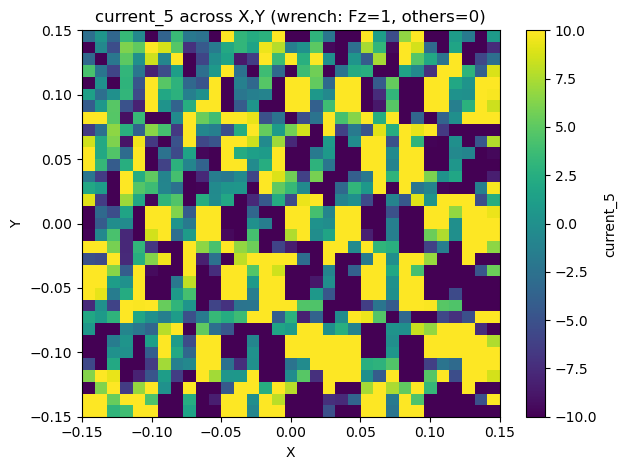

In [10]:
# filter to the fixed input wrench: Fx=Fy=Tx=Ty=Tz=0, Fz=1
w_cols = ['wrench_Fx','wrench_Fy','wrench_Fz','wrench_Tx','wrench_Ty','wrench_Tz']
df_ = df[(df['wrench_Fx']==1)&(df['wrench_Fy']==0)&(df['wrench_Fz']==0)&
         (df['wrench_Tx']==0)&(df['wrench_Ty']==0)&(df['wrench_Tz']==0)].copy()

# drop/ignore wrench_out*
df_ = df_.drop(columns=[c for c in df_.columns if c.startswith('wrench_out_')], errors='ignore')

# keep other things fixed: pick one unique value for every non-(X,Y,current_*,wrench_*) column
fixed_candidates = [
    c for c in df_.columns
    if c not in ['X','Y','current_1'] and not c.startswith('current_') and not c.startswith('wrench_')
]
for c in fixed_candidates:
    vals = df_[c].dropna().unique()
    if len(vals) > 0:
        df_ = df_[df_[c] == vals[0]]

# make a grid of current_1 over X,Y
grid = df_.pivot_table(index='Y', columns='X', values='current_16', aggfunc='mean')
grid = grid.sort_index().sort_index(axis=1)

# plot
import matplotlib.pyplot as plt
plt.figure()
plt.imshow(
    grid.values, origin='lower', aspect='auto',
    extent=[grid.columns.min(), grid.columns.max(), grid.index.min(), grid.index.max()]
)
plt.colorbar(label='current_5')
plt.xlabel('X'); plt.ylabel('Y')
plt.title('current_5 across X,Y (wrench: Fz=1, others=0)')
plt.tight_layout()


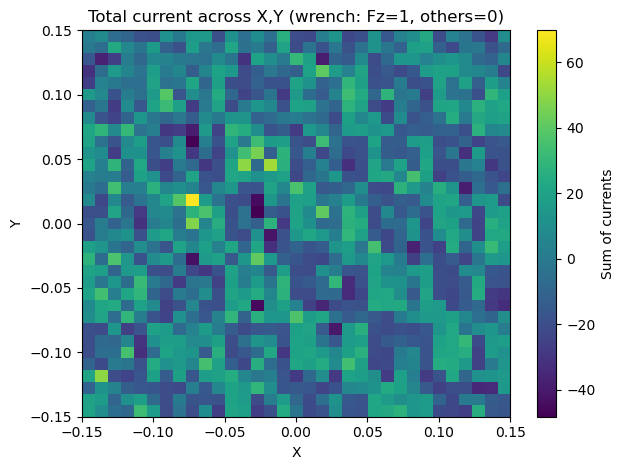

In [11]:
# sum all currents
current_cols = [c for c in df_.columns if c.startswith('current_')]
df_['current_sum'] = df_[current_cols].sum(axis=1)

# make grid over X,Y for the sum
grid = df_.pivot_table(index='Y', columns='X', values='current_sum', aggfunc='mean')
grid = grid.sort_index().sort_index(axis=1)

# plot
import matplotlib.pyplot as plt
plt.figure()
plt.imshow(
    grid.values, origin='lower', aspect='auto',
    extent=[grid.columns.min(), grid.columns.max(), grid.index.min(), grid.index.max()]
)
plt.colorbar(label='Sum of currents')
plt.xlabel('X'); plt.ylabel('Y')
plt.title('Total current across X,Y (wrench: Fz=1, others=0)')
plt.tight_layout()

### Currents dependancy on angles analysis

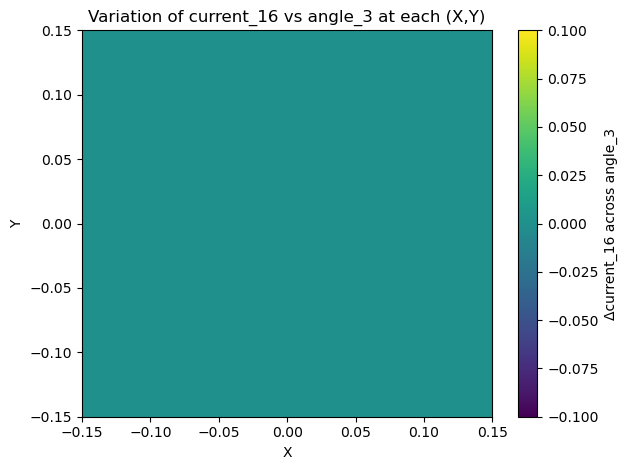

In [12]:
# keep angle_3 free; fix everything else (angles 1&2 fixed)
fixed_cols = [
    c for c in df_.columns
    if c not in ['X','Y','angle_1'] and not c.startswith('current_') and not c.startswith('wrench_')
]
for c in fixed_cols:
    vals = df_[c].dropna().unique()
    if len(vals): df_ = df_[df_[c] == vals[0]]

# ---- choose what to measure ----
# (A) total current variation across angle_3
current_cols = [c for c in df_.columns if c.startswith('current_')]
df_['current_sum'] = df_[current_cols].sum(axis=1)
target = 'current_sum'

# # (B) single coil instead (uncomment to use)
target = 'current_16'

# range (max - min) over angle_3 at each (X,Y)
delta_xy = (df_.groupby(['X','Y'])[target]
              .agg(lambda s: s.max() - s.min())
              .reset_index(name='delta'))

# heatmap
grid = delta_xy.pivot(index='Y', columns='X', values='delta').sort_index().sort_index(axis=1)

import matplotlib.pyplot as plt
plt.figure()
plt.imshow(
    grid.values, origin='lower', aspect='auto',
    extent=[grid.columns.min(), grid.columns.max(), grid.index.min(), grid.index.max()]
)
plt.colorbar(label=f'Δ{target} across angle_3')
plt.xlabel('X'); plt.ylabel('Y')
plt.title(f'Variation of {target} vs angle_3 at each (X,Y)')
plt.tight_layout()


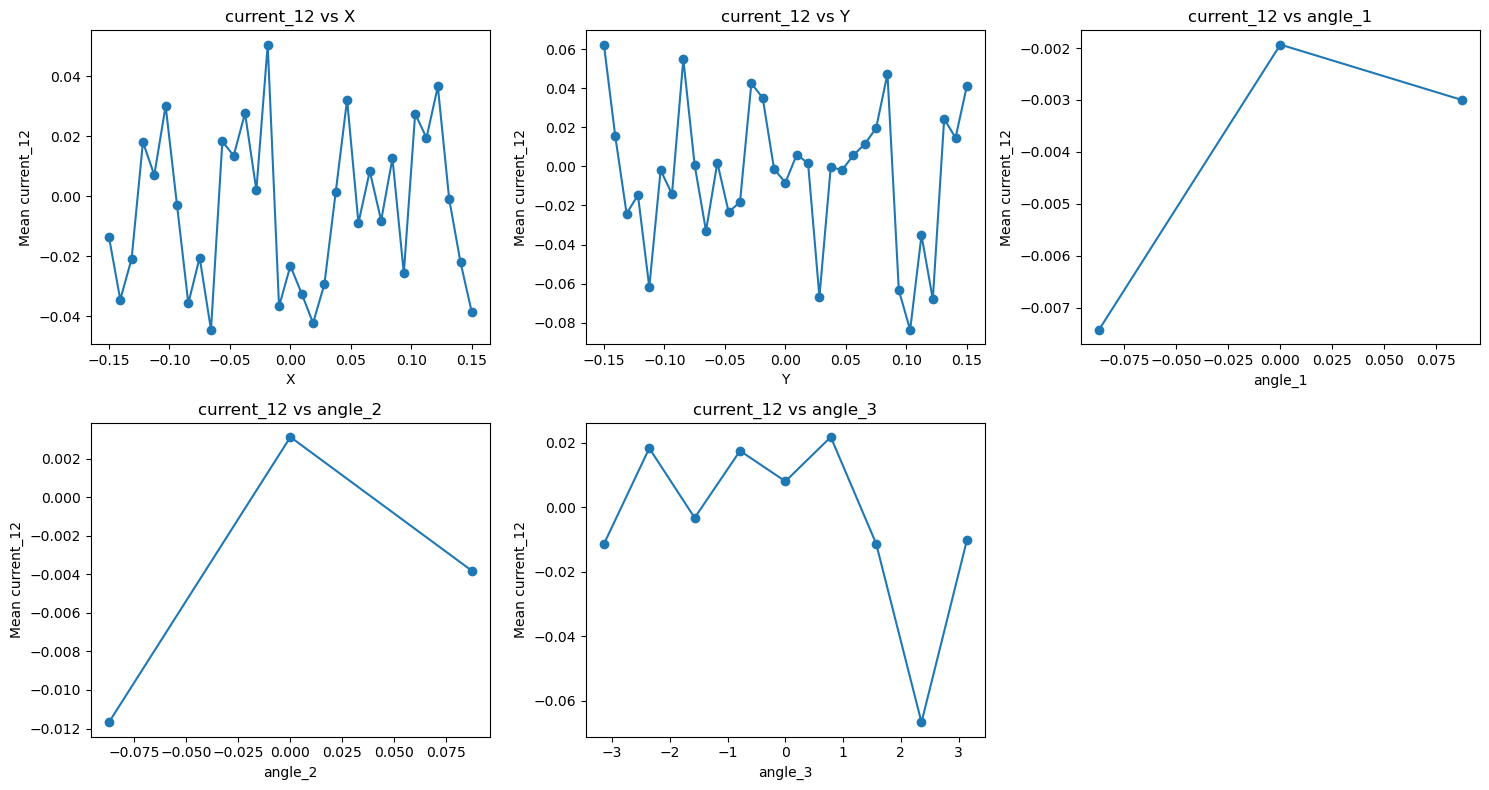

In [13]:
import matplotlib.pyplot as plt

target = 'current_12'  # change to current_5 or others if you want

vars_to_check = ['X', 'Y', 'angle_1', 'angle_2', 'angle_3']

plt.figure(figsize=(15, 8))

for i, var in enumerate(vars_to_check, 1):
    mean_vals = df.groupby(var)[target].mean().reset_index()
    plt.subplot(2, 3, i)
    plt.plot(mean_vals[var], mean_vals[target], marker='o')
    plt.xlabel(var)
    plt.ylabel(f"Mean {target}")
    plt.title(f"{target} vs {var}")

plt.tight_layout()
plt.show()


### Current values over dataset samples

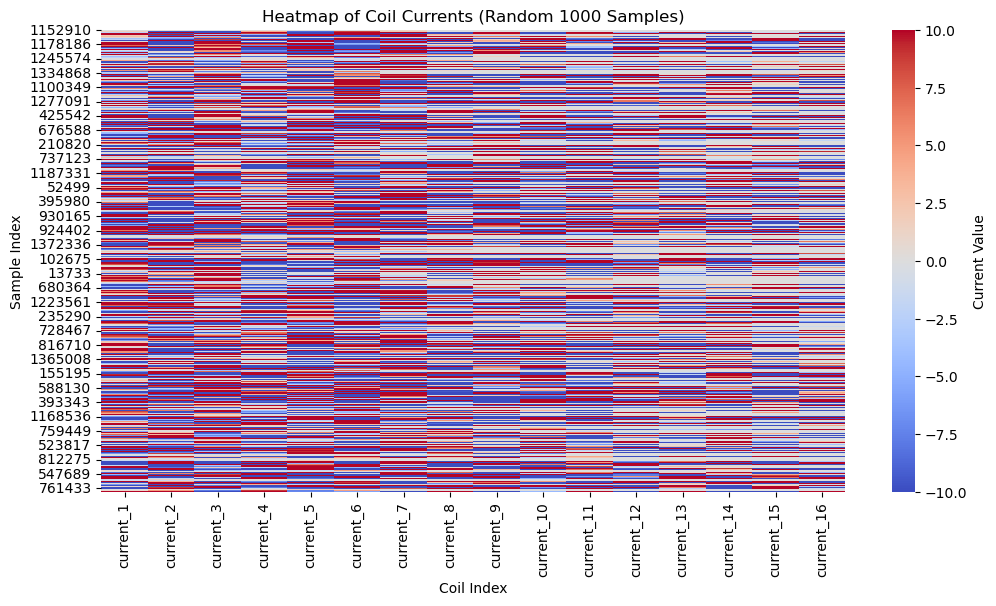

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Pick 1000 random samples
curr_cols = [c for c in df.columns if c.startswith('current_')]
rand_idx = np.random.choice(df.index, size=1000, replace=False)
currents_subset = df.loc[rand_idx, curr_cols]

plt.figure(figsize=(12, 6))
sns.heatmap(currents_subset, cmap='coolwarm', center=0, cbar_kws={'label': 'Current Value'})
plt.xlabel('Coil Index')
plt.ylabel('Sample Index')
plt.title('Heatmap of Coil Currents (Random 1000 Samples)')
plt.show()


### Frequency Analysis of currents over X-Y Plane

Visualize for one coil as an example

Dominant spatial frequency vector: (9.6970, -9.6970)
Dominant wavelength: 0.0729 units
Orientation of bands: -45.00 degrees


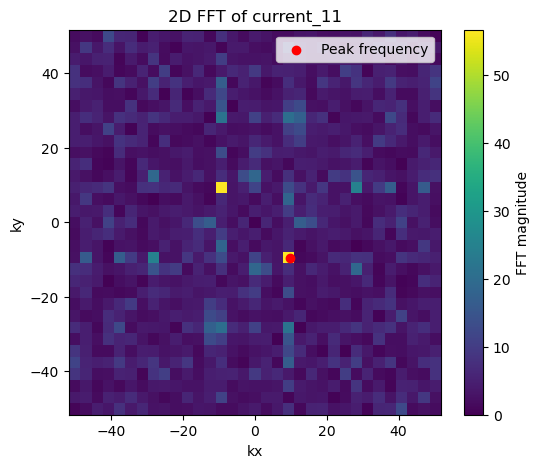

In [15]:
import numpy as np
import matplotlib.pyplot as plt

target = 'current_11'  # change if you want another coil

# Pivot into a 2D grid
grid = df.pivot_table(index='Y', columns='X', values=target, aggfunc='mean')
grid = grid.sort_index().sort_index(axis=1)  # sort axes

# Coordinates
X_coords = grid.columns.to_numpy()
Y_coords = grid.index.to_numpy()

# FFT
F = np.fft.fftshift(np.fft.fft2(grid.fillna(0).to_numpy()))
F_mag = np.abs(F)

# Find dominant frequency (ignore DC component)
center = tuple(np.array(F_mag.shape) // 2)
F_mag[center] = 0
peak_idx = np.unravel_index(np.argmax(F_mag), F_mag.shape)

# Frequency steps
dx = X_coords[1] - X_coords[0]
dy = Y_coords[1] - Y_coords[0]
kx = np.fft.fftshift(np.fft.fftfreq(len(X_coords), d=dx))
ky = np.fft.fftshift(np.fft.fftfreq(len(Y_coords), d=dy))

peak_kx = kx[peak_idx[1]]
peak_ky = ky[peak_idx[0]]

# Wavelength & orientation
wavelength = 1 / np.sqrt(peak_kx**2 + peak_ky**2)
orientation_deg = np.degrees(np.arctan2(peak_ky, peak_kx))

print(f"Dominant spatial frequency vector: ({peak_kx:.4f}, {peak_ky:.4f})")
print(f"Dominant wavelength: {wavelength:.4f} units")
print(f"Orientation of bands: {orientation_deg:.2f} degrees")

# Plot FFT magnitude
plt.figure(figsize=(6,5))
plt.imshow(F_mag, extent=[kx.min(), kx.max(), ky.min(), ky.max()], origin='lower', aspect='auto')
plt.colorbar(label='FFT magnitude')
plt.scatter([peak_kx], [peak_ky], color='red', label='Peak frequency')
plt.xlabel('kx')
plt.ylabel('ky')
plt.title(f'2D FFT of {target}')
plt.legend()
plt.show()


The report of FFt for all coils

In [16]:
import numpy as np
import pandas as pd

def fft_xy_params_for_all_coils(df, current_prefix='current_'):
    results = []
    Xs = np.sort(df['X'].unique())
    Ys = np.sort(df['Y'].unique())
    dx = np.diff(Xs).mean()
    dy = np.diff(Ys).mean()
    kx = np.fft.fftshift(np.fft.fftfreq(len(Xs), d=dx))
    ky = np.fft.fftshift(np.fft.fftfreq(len(Ys), d=dy))

    for col in [c for c in df.columns if c.startswith(current_prefix)]:
        grid = (df.pivot_table(index='Y', columns='X', values=col, aggfunc='mean')
                  .reindex(index=Ys, columns=Xs))
        A = grid.interpolate(axis=0).interpolate(axis=1).fillna(method='ffill').fillna(method='bfill').to_numpy()

        F = np.fft.fftshift(np.fft.fft2(A))
        M = np.abs(F)
        cy, cx = np.array(M.shape)//2
        M[cy, cx] = 0  # drop DC
        py, px = np.unravel_index(np.argmax(M), M.shape)

        kx_peak = kx[px]
        ky_peak = ky[py]
        k_mag = np.hypot(kx_peak, ky_peak)
        wavelength = 1.0/k_mag if k_mag > 0 else np.nan

        k_angle_deg = np.degrees(np.arctan2(ky_peak, kx_peak))            # wavevector angle
        bands_angle_deg = (k_angle_deg + 90.0 + 180.0) % 180.0            # stripe orientation

        results.append({
            'coil': col,
            'kx': kx_peak,
            'ky': ky_peak,
            'k_mag': k_mag,
            'wavelength': wavelength,
            'k_angle_deg': k_angle_deg,
            'bands_angle_deg': bands_angle_deg
        })

    return pd.DataFrame(results).sort_values('coil').reset_index(drop=True)

# usage:
params_df = fft_xy_params_for_all_coils(df)
print(params_df)


/tmp/ipykernel_10056/2115705781.py:16: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  A = grid.interpolate(axis=0).interpolate(axis=1).fillna(method='ffill').fillna(method='bfill').to_numpy()
/tmp/ipykernel_10056/2115705781.py:16: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  A = grid.interpolate(axis=0).interpolate(axis=1).fillna(method='ffill').fillna(method='bfill').to_numpy()
/tmp/ipykernel_10056/2115705781.py:16: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  A = grid.interpolate(axis=0).interpolate(axis=1).fillna(method='ffill').fillna(method='bfill').to_numpy()
/tmp/ipykernel_10056/2115705781.py:16: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() 

          coil         kx         ky      k_mag  wavelength  k_angle_deg  \
0    current_1   9.696970  -9.696970  13.713586    0.072920   -45.000000   
1   current_10   9.696970  -9.696970  13.713586    0.072920   -45.000000   
2   current_11   9.696970  -9.696970  13.713586    0.072920   -45.000000   
3   current_12   9.696970  -9.696970  13.713586    0.072920   -45.000000   
4   current_13  -9.696970  -9.696970  13.713586    0.072920  -135.000000   
5   current_14   9.696970  -9.696970  13.713586    0.072920   -45.000000   
6   current_15  -9.696970  -9.696970  13.713586    0.072920  -135.000000   
7   current_16  -9.696970  -9.696970  13.713586    0.072920  -135.000000   
8    current_2  -9.696970  -9.696970  13.713586    0.072920  -135.000000   
9    current_3  -9.696970  -9.696970  13.713586    0.072920  -135.000000   
10   current_4  -9.696970  -9.696970  13.713586    0.072920  -135.000000   
11   current_5 -42.020202 -51.717172  66.636051    0.015007  -129.093859   
12   current

/tmp/ipykernel_10056/2115705781.py:16: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  A = grid.interpolate(axis=0).interpolate(axis=1).fillna(method='ffill').fillna(method='bfill').to_numpy()
/tmp/ipykernel_10056/2115705781.py:16: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  A = grid.interpolate(axis=0).interpolate(axis=1).fillna(method='ffill').fillna(method='bfill').to_numpy()
/tmp/ipykernel_10056/2115705781.py:16: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  A = grid.interpolate(axis=0).interpolate(axis=1).fillna(method='ffill').fillna(method='bfill').to_numpy()
/tmp/ipykernel_10056/2115705781.py:16: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() 

# Feature Extraction

In [17]:
df.head()

,X,Y,Z,angle_1,angle_2,angle_3,wrench_Fx,wrench_Fy,wrench_Fz,wrench_Tx,...,current_7,current_8,current_9,current_10,current_11,current_12,current_13,current_14,current_15,current_16
0,-0.150000,-0.15,0.005,-0.087266,-0.087266,-3.141593,1.0,0.0,0.0,0.0,...,-10.000000,-4.312420,-10.000000,10.000000,9.380868,-10.000000,10.000000,-10.000000,10.000000,10.000000
1,-0.140625,-0.15,0.005,-0.087266,-0.087266,-3.141593,1.0,0.0,0.0,0.0,...,-10.000000,-6.186670,-10.000000,10.000000,5.427733,-10.000000,10.000000,-10.000000,3.694898,10.000000
2,-0.131250,-0.15,0.005,-0.087266,-0.087266,-3.141593,1.0,0.0,0.0,0.0,...,10.000000,9.186635,-5.858047,10.000000,-0.703584,-1.272686,-0.492354,0.891581,-1.653864,3.078829
3,-0.121875,-0.15,0.005,-0.087266,-0.087266,-3.141593,1.0,0.0,0.0,0.0,...,-10.000000,-10.000000,-10.000000,9.134971,10.000000,-1.060216,10.000000,-5.549140,-10.000000,3.863199
4,-0.112500,-0.15,0.005,-0.087266,-0.087266,-3.141593,1.0,0.0,0.0,0.0,...,1.232469,-2.340074,-10.000000,10.000000,10.000000,-10.000000,10.000000,-10.000000,5.231467,10.000000


In [18]:
df.columns

Index(['X', 'Y', 'Z', 'angle_1', 'angle_2', 'angle_3', 'wrench_Fx',
       'wrench_Fy', 'wrench_Fz', 'wrench_Tx', 'wrench_Ty', 'wrench_Tz',
       'wrench_out_Fx', 'wrench_out_Fy', 'wrench_out_Fz', 'wrench_out_Tx',
       'wrench_out_Ty', 'wrench_out_Tz', 'current_1', 'current_2', 'current_3',
       'current_4', 'current_5', 'current_6', 'current_7', 'current_8',
       'current_9', 'current_10', 'current_11', 'current_12', 'current_13',
       'current_14', 'current_15', 'current_16'],
      dtype='object')

## Phase1: 

In [19]:
# Shuffle the dataframe for randomness
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

import re
import pandas as pd

# --- Canonical sets ---
WRENCH_COLS = ["wrench_Fx","wrench_Fy","wrench_Fz",
               "wrench_Tx","wrench_Ty","wrench_Tz"]

WRENCH_OUT_COLS = ["wrench_out_Fx","wrench_out_Fy","wrench_out_Fz",
                   "wrench_out_Tx","wrench_out_Ty","wrench_out_Tz"]

# Current target columns (numeric order)
current_cols = sorted(
    [c for c in df.columns if c.startswith("current_")],
    key=lambda x: int(re.search(r"\d+", x).group())
)

### Drop current outliers

In [20]:
def clean_current_rows(df, current_cols, wrench_cols, 
                       outlier_thr=10.0, min_total_thr=1e-2, drop_wrench_sum=1.0):
    """
    Clean dataset based on coil current and wrench rules:
    1. Drop rows with any coil |current| > outlier_thr.
    2. Drop rows where total coil activity is too small (all nearly zero).
    3. Drop rows where sum of wrench components == drop_wrench_sum.
    
    Args:
        df: DataFrame
        current_cols: list of coil current column names
        wrench_cols: list of wrench column names
        outlier_thr: absolute threshold for outlier removal (default ±10)
        min_total_thr: threshold on total L1 norm of currents to consider "nonzero"
        drop_wrench_sum: value of wrench sum that should be dropped (default = 1.0)
    
    Returns:
        df_clean: cleaned DataFrame
        dropped_mask: boolean mask of dropped rows
    """
    import pandas as pd

    # Convert currents to numeric
    abs_curr = df.loc[:, current_cols].apply(pd.to_numeric, errors="coerce").abs()

    # 1) Drop outliers
    too_big = abs_curr.gt(outlier_thr).any(axis=1).fillna(False)

    # 2) Drop rows where all currents are too small
    total_activity = abs_curr.sum(axis=1)
    too_small = total_activity.lt(min_total_thr).fillna(True)

    # 3) Drop rows where wrench sum == drop_wrench_sum
    wrench_sum = df[wrench_cols].sum(axis=1)
    bad_wrench = wrench_sum.eq(drop_wrench_sum)

    # Combine masks
    drop_mask = too_big | too_small | bad_wrench
    df_clean = df.loc[~drop_mask].copy()

    return df_clean, drop_mask

# Example usage:
df_clean, dropped_mask = clean_current_rows(
    df,
    current_cols=current_cols,
    wrench_cols=WRENCH_COLS,
    outlier_thr=10.0,
    min_total_thr=1,
    drop_wrench_sum=1.0
)
df_clean = df_clean[df_clean["wrench_out_Tz"].abs() < 1e3]  # example cutoff

print(f"Original size: {len(df)}, Cleaned size: {len(df_clean)}, Dropped: {dropped_mask.sum()}")


Original size: 1411344, Cleaned size: 788381, Dropped: 622959


In [21]:
df = df_clean

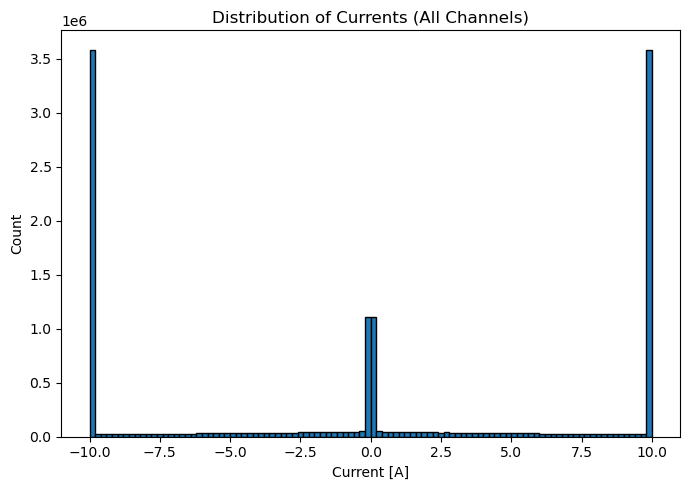

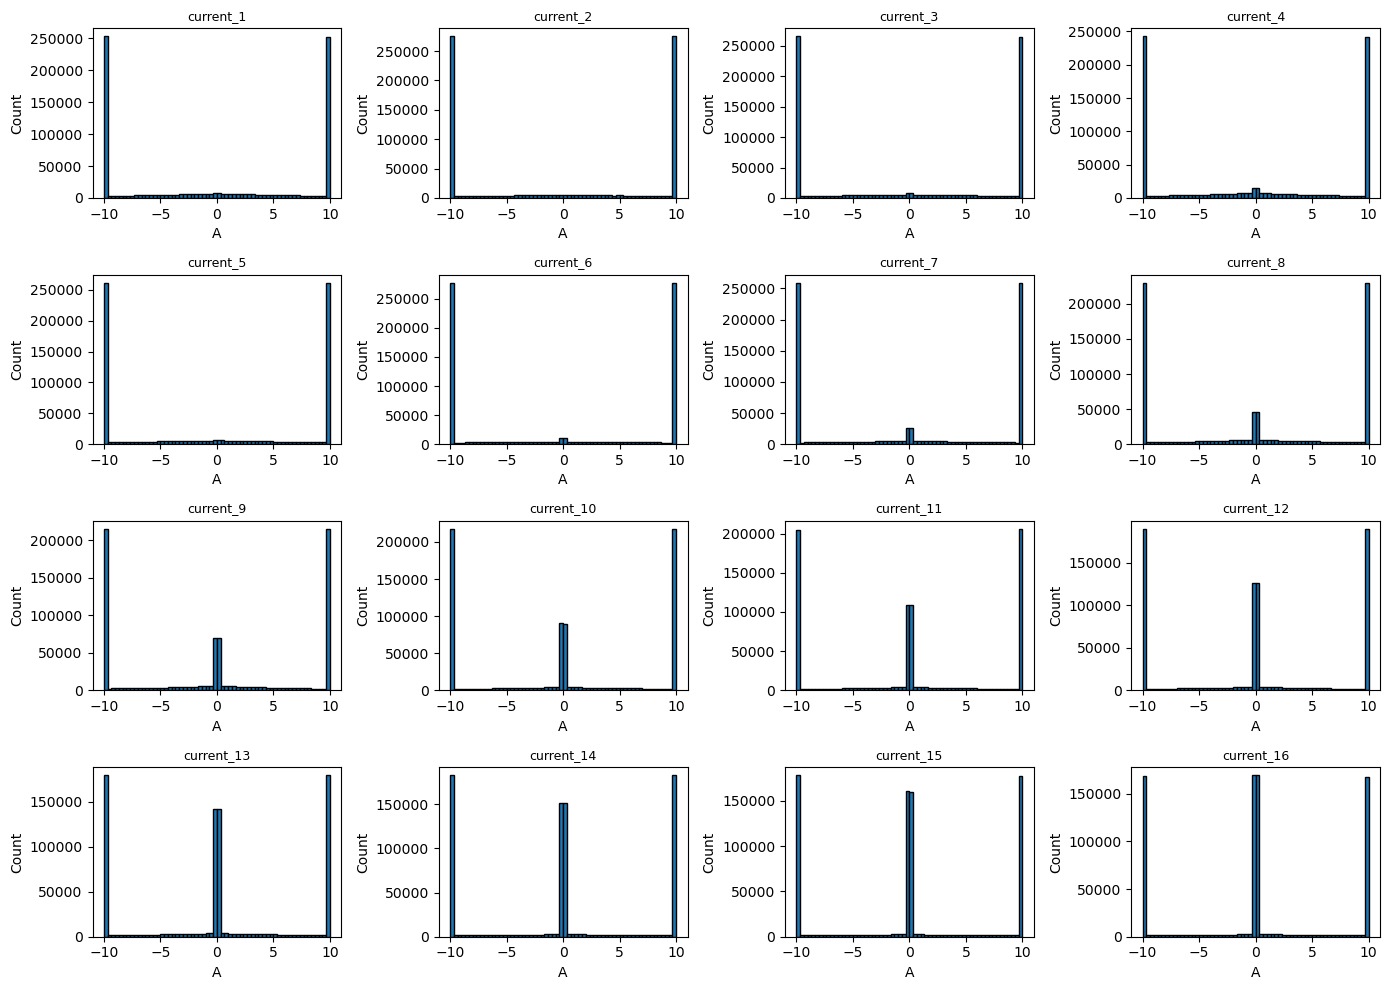

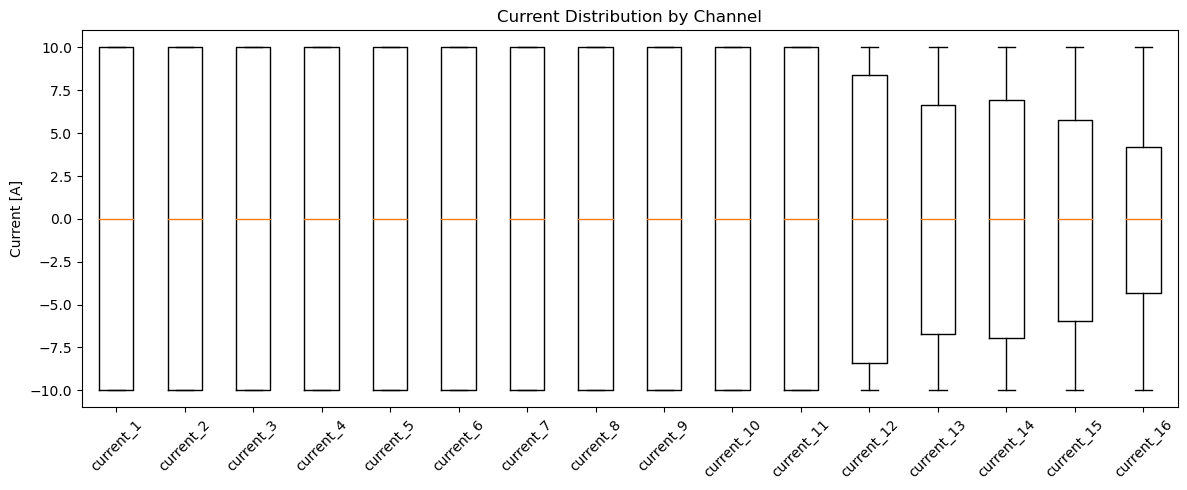

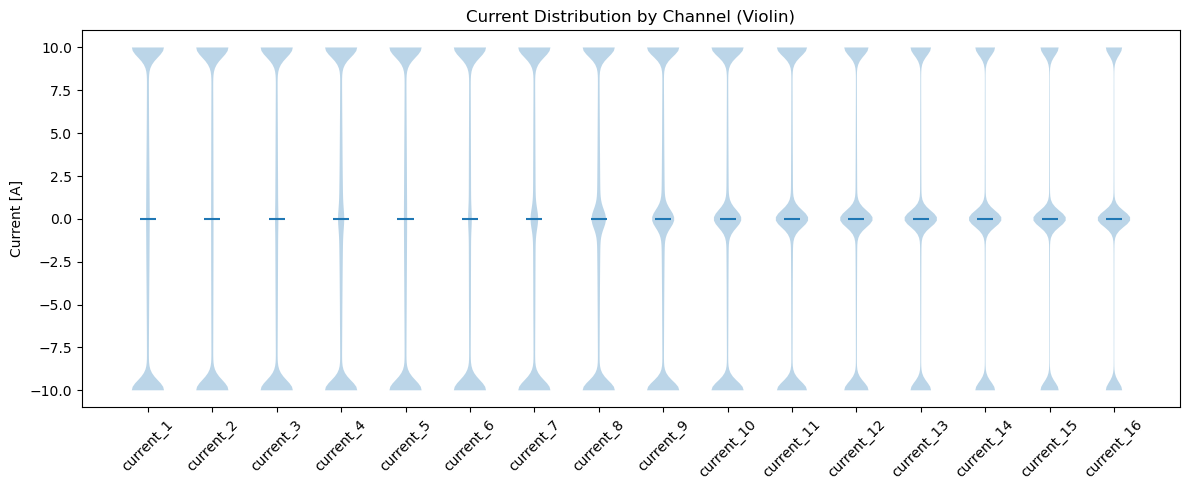

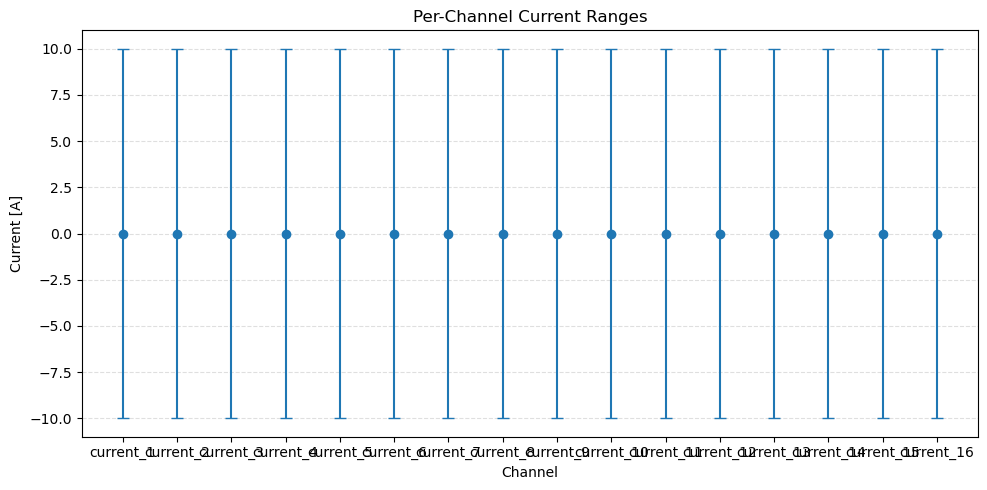

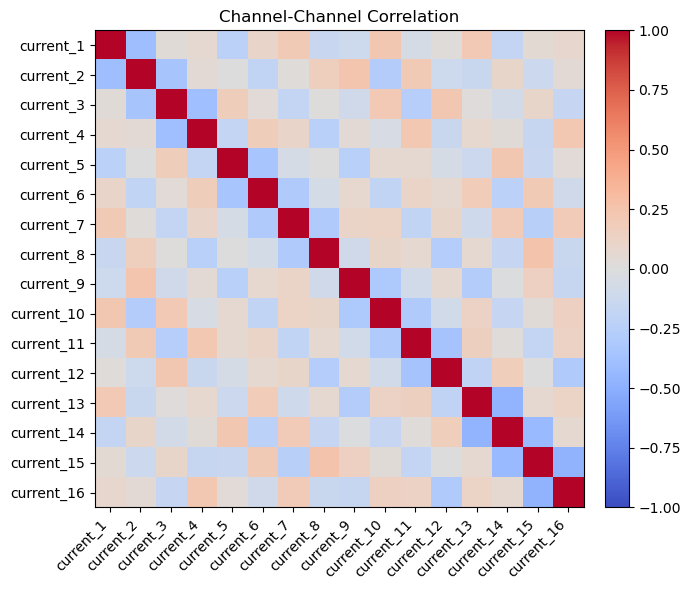

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# --- Extract current matrix ---
X = df_clean[current_cols].to_numpy()

# --- Overall distribution ---
plt.figure(figsize=(7,5))
plt.hist(X.ravel(), bins=100, edgecolor='black')
plt.title("Distribution of Currents (All Channels)")
plt.xlabel("Current [A]"); plt.ylabel("Count")
plt.tight_layout()
plt.show()

# --- Per-channel hist (4x4 grid) ---
fig, axes = plt.subplots(4,4, figsize=(14,10))
axes = axes.ravel()
for i in range(len(current_cols)):
    axes[i].hist(X[:, i], bins=60, edgecolor='black')
    axes[i].set_title(current_cols[i], fontsize=9)
    axes[i].set_xlabel("A"); axes[i].set_ylabel("Count")
plt.tight_layout()
plt.show()

# --- Boxplot ---
plt.figure(figsize=(12,5))
plt.boxplot([X[:,i] for i in range(X.shape[1])],
            showfliers=False, labels=current_cols)
plt.title("Current Distribution by Channel")
plt.ylabel("Current [A]"); plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- Violin ---
plt.figure(figsize=(12,5))
plt.violinplot([X[:,i] for i in range(X.shape[1])],
               showmeans=True, showextrema=False)
plt.title("Current Distribution by Channel (Violin)")
plt.ylabel("Current [A]")
plt.xticks(ticks=np.arange(1, X.shape[1]+1),
           labels=current_cols, rotation=45)
plt.tight_layout()
plt.show()

# --- Range per channel ---
col_min, col_max = np.nanmin(X,0), np.nanmax(X,0)
centers, half_rng = (col_min+col_max)/2, (col_max-col_min)/2
x = np.arange(1, X.shape[1]+1)
plt.figure(figsize=(10,5))
plt.errorbar(x, centers, yerr=half_rng, fmt='o', capsize=4)
plt.xticks(x, current_cols); 
plt.title("Per-Channel Current Ranges")
plt.xlabel("Channel"); plt.ylabel("Current [A]")
plt.grid(True, axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# --- Correlation heatmap ---
corr = np.corrcoef(X.T)
plt.figure(figsize=(7,6))
im = plt.imshow(corr, vmin=-1, vmax=1, aspect='auto', cmap="coolwarm")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(np.arange(X.shape[1]), current_cols, rotation=45, ha='right')
plt.yticks(np.arange(X.shape[1]), current_cols)
plt.title("Channel-Channel Correlation")
plt.tight_layout()
plt.show()


In [23]:
# Assuming df_clean is your working dataframe
# and WRENCH_COLS is already defined as the 6 wrench component names

import pandas as pd

# Get unique wrench combinations
unique_wrenches = df_clean[WRENCH_COLS].drop_duplicates().reset_index(drop=True)

print(f"Found {len(unique_wrenches)} unique wrench combinations.")
print(unique_wrenches)

# If you want them as a NumPy array:
unique_wrench_array = unique_wrenches.to_numpy()


Found 10 unique wrench combinations.
   wrench_Fx  wrench_Fy  wrench_Fz  wrench_Tx  wrench_Ty  wrench_Tz
0  -5.732240  18.311640  67.249300  -6.310591   0.436784  -0.184348
1  20.506213  41.769258   1.979486   0.600467   3.603379   0.094274
2  -4.265443  19.474788 -14.420433  -8.784565   2.081424   0.721901
3 -13.381404  16.334480 -62.279050  -4.121966   4.450079  -2.565989
4  -8.912334  -9.557766  63.590473  -2.517007  -2.907864   6.159570
5 -14.460079 -13.662422  67.910946   2.730096  -4.553195   3.140987
6  -6.002476  21.575356 -71.323061   1.410924  -0.042340   5.203526
7 -22.372319   3.787195  60.733533   3.060779  -4.956699   2.929608
8 -31.114817 -18.770681  50.741715  -2.396658  -0.101788   3.959753
9  25.198885  -9.518419   6.847363  -3.349440   1.755440   7.497163


In [24]:
# Get unique wrench combinations
unique_wrenches = df_clean[WRENCH_COLS].drop_duplicates().reset_index(drop=True)

# Add a "sum" column
unique_wrenches["wrench_sum"] = unique_wrenches.sum(axis=1)

print(unique_wrenches)


   wrench_Fx  wrench_Fy  wrench_Fz  wrench_Tx  wrench_Ty  wrench_Tz  \
0  -5.732240  18.311640  67.249300  -6.310591   0.436784  -0.184348   
1  20.506213  41.769258   1.979486   0.600467   3.603379   0.094274   
2  -4.265443  19.474788 -14.420433  -8.784565   2.081424   0.721901   
3 -13.381404  16.334480 -62.279050  -4.121966   4.450079  -2.565989   
4  -8.912334  -9.557766  63.590473  -2.517007  -2.907864   6.159570   
5 -14.460079 -13.662422  67.910946   2.730096  -4.553195   3.140987   
6  -6.002476  21.575356 -71.323061   1.410924  -0.042340   5.203526   
7 -22.372319   3.787195  60.733533   3.060779  -4.956699   2.929608   
8 -31.114817 -18.770681  50.741715  -2.396658  -0.101788   3.959753   
9  25.198885  -9.518419   6.847363  -3.349440   1.755440   7.497163   

   wrench_sum  
0   73.770546  
1   68.553077  
2   -5.192328  
3  -61.563850  
4   45.855072  
5   41.106333  
6  -49.178071  
7   43.182098  
8    2.317525  
9   28.430991  


In [25]:
df.head

<bound method NDFrame.head of                 X         Y      Z   angle_1   angle_2   angle_3  wrench_Fx  \
1       -0.131250  0.140625  0.005  0.087266  0.000000 -2.356194  -5.732240   
3       -0.009375 -0.075000  0.005  0.000000 -0.087266  3.141593  20.506213   
4        0.028125  0.112500  0.005  0.087266  0.000000  3.141593  -5.732240   
6        0.028125  0.150000  0.005 -0.087266  0.000000  0.785398  -4.265443   
8       -0.150000 -0.075000  0.005  0.000000 -0.087266  3.141593 -13.381404   
...           ...       ...    ...       ...       ...       ...        ...   
1411337 -0.075000  0.084375  0.005  0.087266  0.000000 -2.356194  25.198885   
1411338 -0.065625  0.009375  0.005 -0.087266  0.000000 -3.141593  -8.912334   
1411339 -0.009375 -0.131250  0.005  0.000000  0.087266 -2.356194  -5.732240   
1411340  0.121875 -0.093750  0.005 -0.087266 -0.087266  0.000000  -5.732240   
1411343  0.065625 -0.131250  0.005  0.087266  0.000000  0.785398 -13.381404   

         wrench_Fy  w

# Input-Target Definition

## Current loading

In [31]:


# Feature columns = everything else (not wrench, not current, not wrench_out)
feature_cols = [c for c in df.columns 
                if c not in set(WRENCH_COLS + current_cols + WRENCH_OUT_COLS)]

# --- Build blocks ---
X_feat     = df.loc[:, feature_cols].apply(pd.to_numeric, errors="coerce").copy()   # Pose features
W          = df.loc[:, WRENCH_COLS].apply(pd.to_numeric, errors="coerce").copy()    # Desired wrench
I          = df.loc[:, current_cols].apply(pd.to_numeric, errors="coerce").copy()   # Currents
W_out      = df.loc[:, WRENCH_OUT_COLS].apply(pd.to_numeric, errors="coerce").copy()# Realized wrench


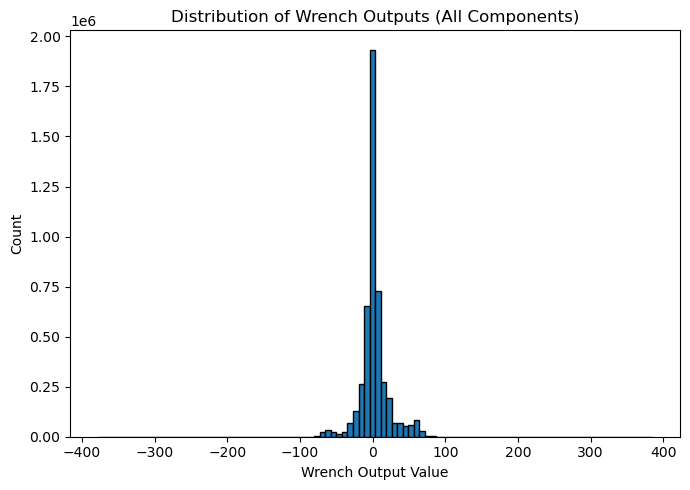

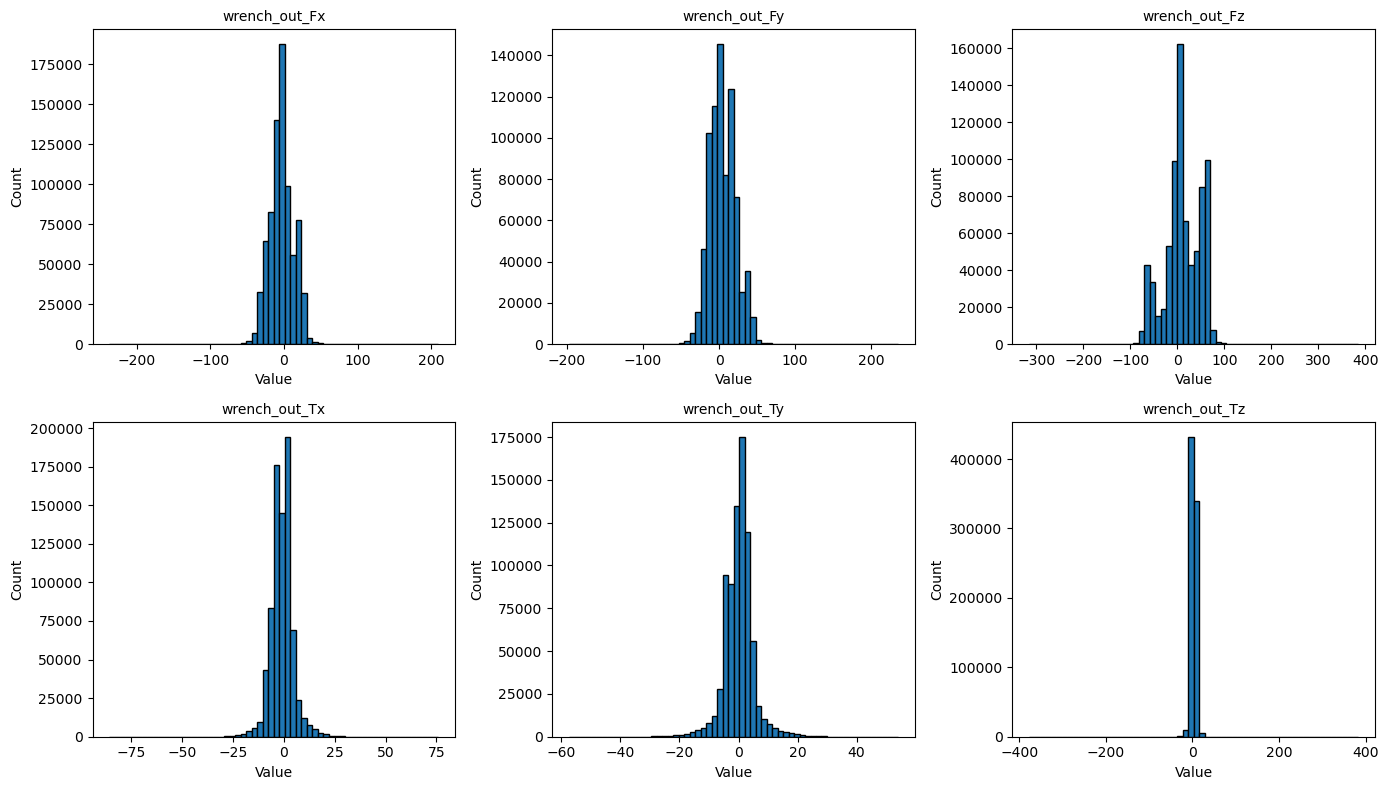

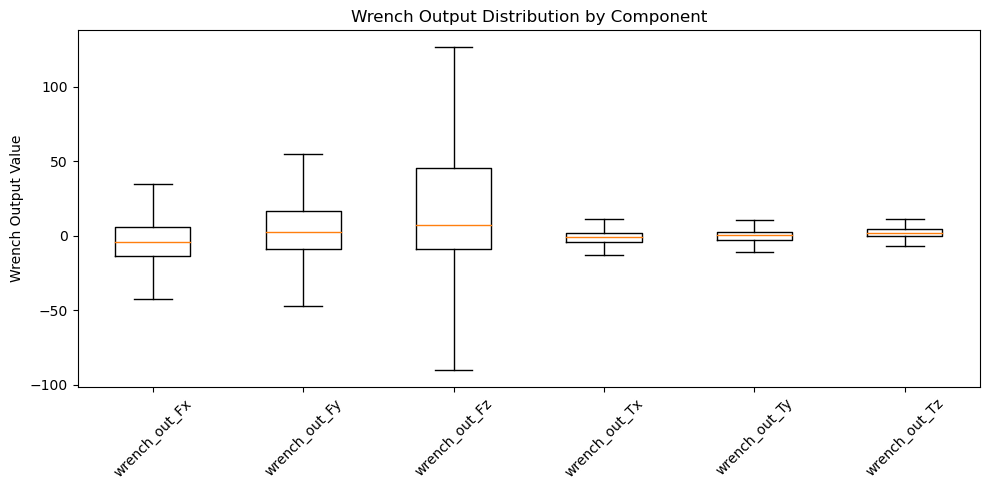

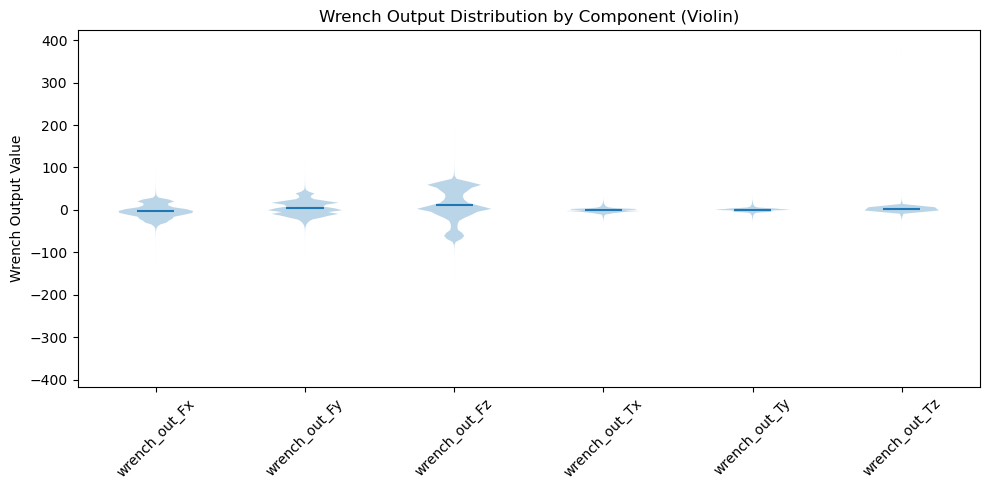

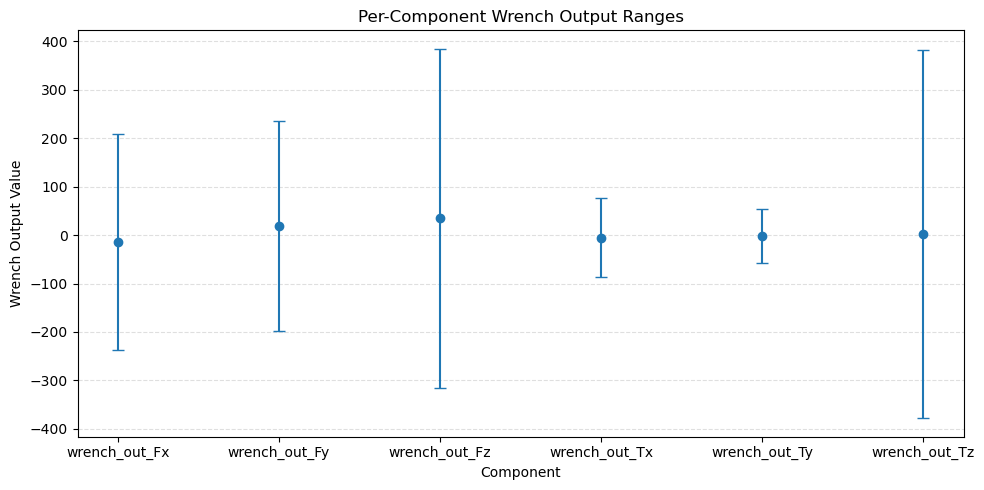

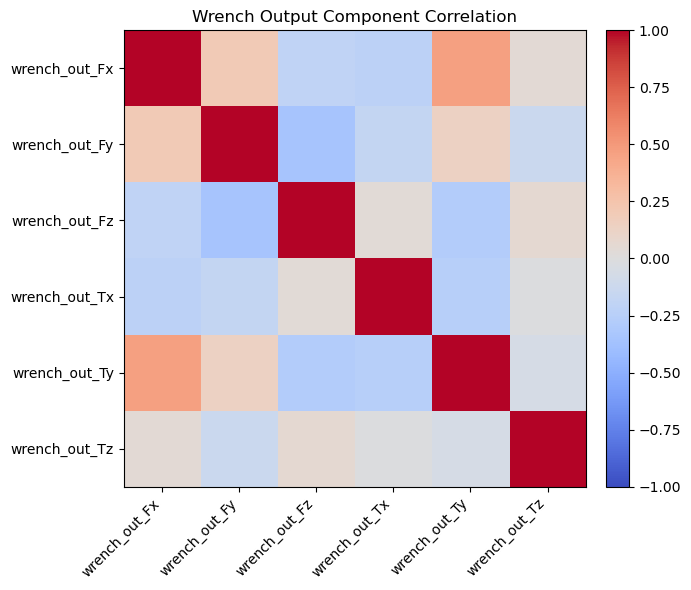

In [32]:
import matplotlib.pyplot as plt
import numpy as np

# --- Define output wrench columns ---
WRENCH_OUT_COLS = ["wrench_out_Fx","wrench_out_Fy","wrench_out_Fz",
                   "wrench_out_Tx","wrench_out_Ty","wrench_out_Tz"]

# --- Extract wrench outputs ---
W_out = df_clean[WRENCH_OUT_COLS].to_numpy()

# --- Overall histogram (all components combined) ---
plt.figure(figsize=(7,5))
plt.hist(W_out.ravel(), bins=100, edgecolor='black')
plt.title("Distribution of Wrench Outputs (All Components)")
plt.xlabel("Wrench Output Value"); plt.ylabel("Count")
plt.tight_layout()
plt.show()

# --- Per-component histograms (2x3 grid for 6 components) ---
fig, axes = plt.subplots(2,3, figsize=(14,8))
axes = axes.ravel()
for i, col in enumerate(WRENCH_OUT_COLS):
    axes[i].hist(W_out[:, i], bins=60, edgecolor='black')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("Value"); axes[i].set_ylabel("Count")
plt.tight_layout()
plt.show()

# --- Boxplot across components ---
plt.figure(figsize=(10,5))
plt.boxplot([W_out[:,i] for i in range(W_out.shape[1])],
            showfliers=False, labels=WRENCH_OUT_COLS)
plt.title("Wrench Output Distribution by Component")
plt.ylabel("Wrench Output Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- Violin plot ---
plt.figure(figsize=(10,5))
plt.violinplot([W_out[:,i] for i in range(W_out.shape[1])],
               showmeans=True, showextrema=False)
plt.title("Wrench Output Distribution by Component (Violin)")
plt.ylabel("Wrench Output Value")
plt.xticks(ticks=np.arange(1, W_out.shape[1]+1),
           labels=WRENCH_OUT_COLS, rotation=45)
plt.tight_layout()
plt.show()

# --- Range per component ---
col_min, col_max = np.nanmin(W_out,0), np.nanmax(W_out,0)
centers, half_rng = (col_min+col_max)/2, (col_max-col_min)/2
x = np.arange(1, W_out.shape[1]+1)
plt.figure(figsize=(10,5))
plt.errorbar(x, centers, yerr=half_rng, fmt='o', capsize=4)
plt.xticks(x, WRENCH_OUT_COLS)
plt.title("Per-Component Wrench Output Ranges")
plt.xlabel("Component"); plt.ylabel("Wrench Output Value")
plt.grid(True, axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# --- Correlation heatmap across components ---
corr = np.corrcoef(W_out.T)
plt.figure(figsize=(7,6))
im = plt.imshow(corr, vmin=-1, vmax=1, aspect='auto', cmap="coolwarm")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(np.arange(W_out.shape[1]), WRENCH_OUT_COLS, rotation=45, ha='right')
plt.yticks(np.arange(W_out.shape[1]), WRENCH_OUT_COLS)
plt.title("Wrench Output Component Correlation")
plt.tight_layout()
plt.show()


In [33]:
X_feat.head()

,X,Y,Z,angle_1,angle_2,angle_3
1,-0.131250,0.140625,0.005,0.087266,0.000000,-2.356194
3,-0.009375,-0.075000,0.005,0.000000,-0.087266,3.141593
4,0.028125,0.112500,0.005,0.087266,0.000000,3.141593
6,0.028125,0.150000,0.005,-0.087266,0.000000,0.785398
8,-0.150000,-0.075000,0.005,0.000000,-0.087266,3.141593


In [34]:
W.head()

,wrench_Fx,wrench_Fy,wrench_Fz,wrench_Tx,wrench_Ty,wrench_Tz
1,-5.732240,18.311640,67.249300,-6.310591,0.436784,-0.184348
3,20.506213,41.769258,1.979486,0.600467,3.603379,0.094274
4,-5.732240,18.311640,67.249300,-6.310591,0.436784,-0.184348
6,-4.265443,19.474788,-14.420433,-8.784565,2.081424,0.721901
8,-13.381404,16.334480,-62.279050,-4.121966,4.450079,-2.565989


In [35]:
I.head()

,current_1,current_2,current_3,current_4,current_5,current_6,current_7,current_8,current_9,current_10,current_11,current_12,current_13,current_14,current_15,current_16
1,-2.430517,10.000000,10.000000,10.000000,10.0,-10.000000,-10.000000,-1.000000e+01,1.000000e+01,-4.875169e+00,1.000000e+01,-6.411752e+00,-1.000000e+01,-1.000000e+01,-1.000000e+01,3.830143e+00
3,-10.000000,10.000000,10.000000,6.148687,10.0,-10.000000,-10.000000,-1.000000e+01,-1.000000e+01,-9.886118e+00,1.000000e+01,1.000000e+01,1.000000e+01,1.000000e+01,-1.000000e+01,7.218699e+00
4,10.000000,-10.000000,10.000000,-10.000000,10.0,-10.000000,6.071420,1.000000e+01,-1.000000e+01,1.000000e+01,-1.000000e+01,1.000000e+01,-9.999998e+00,-8.084336e+00,-1.000000e+01,7.854739e+00
6,-1.479198,0.249377,4.627703,-4.581372,10.0,-2.695952,-5.949799,3.816541e-08,-6.137605e-09,-5.416733e-08,-8.299663e-08,-2.327361e-08,1.151381e-07,4.267340e-08,2.813500e-09,8.728927e-08
8,-10.000000,10.000000,-10.000000,-9.713987,10.0,-10.000000,10.000000,9.999996e+00,1.000000e+01,-1.000000e+01,9.437516e+00,9.999993e+00,-1.000000e+01,1.000000e+01,-1.000000e+01,-9.028634e+00


# PINN Model

In [36]:
import tensorflow as tf
import numpy as np

# --- Global constants ---
PI       = tf.constant(np.pi, dtype=tf.float32)
TAU      = tf.constant(0.0508, dtype=tf.float32)
BETA_K   = tf.constant(-87.14, dtype=tf.float32)
ALPHA_X  = tf.constant(3.9021, dtype=tf.float32)
ALPHA_Y  = tf.constant(3.9021, dtype=tf.float32)
ALPHA_Z  = tf.constant(5.5209, dtype=tf.float32)
ALPHA_M1 = tf.constant(-0.0715, dtype=tf.float32)
ALPHA_M2 = tf.constant(-0.1046, dtype=tf.float32)
BETA_M1  = tf.constant(-0.123, dtype=tf.float32)
BETA_M2  = tf.constant(-0.0203, dtype=tf.float32)
ALPHA_RZ = tf.constant(-0.0146, dtype=tf.float32)

# --- Safe math ---
def safe_exp(x, clip_val=50.0):
    """Clipped exponential to avoid overflow."""
    return tf.exp(tf.clip_by_value(x, -clip_val, clip_val))

def safe_tan(x, eps=1e-3):
    """Safe tan, wrapping into [-pi/2, pi/2] to avoid poles."""
    x_mod = tf.math.floormod(x + np.pi/2, np.pi) - np.pi/2
    return tf.tan(tf.clip_by_value(x_mod, -np.pi/2+eps, np.pi/2-eps))

# --- Coil positions (4x4 grid) ---
def coil_positions(tau=TAU, n_rows=4, n_cols=4):
    pos = []
    for i in range(n_rows):
        for j in range(n_cols):
            # corrected: j and i start at 0 in Python
            x_center = j * float(tau) - ((n_cols - 1) * float(tau) / 2)
            y_center = i * float(tau) - ((n_rows - 1) * float(tau) / 2)
            z_center = 0.0
            pos.append([x_center, y_center, z_center])
    return tf.constant(pos, dtype=tf.float32)  # (16,3)

COIL_POS = coil_positions()

# --- Compute Gamma(p) ---
def compute_gamma(pose):
    """
    pose: (batch, 6) = [x_m, y_m, z_m, alpha_rot, beta_rot, gamma_rot]
    returns: Gamma (batch, 6, 16)
    """
    x_m, y_m, z_m, a_rot, b_rot, g_rot = tf.unstack(pose, axis=-1)

    # Rotation matrices (batch,3,3)
    Rx = tf.stack([
        tf.ones_like(a_rot), tf.zeros_like(a_rot), tf.zeros_like(a_rot),
        tf.zeros_like(a_rot), tf.cos(a_rot), -tf.sin(a_rot),
        tf.zeros_like(a_rot), tf.sin(a_rot),  tf.cos(a_rot)
    ], axis=-1)
    Rx = tf.reshape(Rx, (-1,3,3))

    Ry = tf.stack([
        tf.cos(b_rot), tf.zeros_like(b_rot), tf.sin(b_rot),
        tf.zeros_like(b_rot), tf.ones_like(b_rot), tf.zeros_like(b_rot),
        -tf.sin(b_rot), tf.zeros_like(b_rot), tf.cos(b_rot)
    ], axis=-1)
    Ry = tf.reshape(Ry, (-1,3,3))

    Rz = tf.stack([
        tf.cos(g_rot), -tf.sin(g_rot), tf.zeros_like(g_rot),
        tf.sin(g_rot),  tf.cos(g_rot), tf.zeros_like(g_rot),
        tf.zeros_like(g_rot), tf.zeros_like(g_rot), tf.ones_like(g_rot)
    ], axis=-1)
    Rz = tf.reshape(Rz, (-1,3,3))

    # Combined rotation: R = Rz^T * Ry^T * Rx^T
    R = tf.matmul(tf.matmul(tf.transpose(Rz, perm=[0,2,1]),
                            tf.transpose(Ry, perm=[0,2,1])),
                  tf.transpose(Rx, perm=[0,2,1]))  # (batch,3,3)

    n_coils = COIL_POS.shape[0]
    gamma_list = []

    for i in range(n_coils):
        coil_pos = COIL_POS[i]  # (3,)
        pos_diff = tf.stack([
            coil_pos[0] - x_m,
            coil_pos[1] - y_m,
            coil_pos[2] - z_m
        ], axis=-1)  # (batch,3)

        cm = tf.matmul(R, tf.expand_dims(pos_diff, -1))  # (batch,3,1)
        cm = tf.squeeze(cm, -1)  # (batch,3)

        # η_x, η_y
        eta_x = (PI / TAU) * cm[:,0]
        eta_y = (PI / TAU) * cm[:,1]

        # Force constants (safe)
        Kx = ALPHA_X * safe_exp(BETA_K * cm[:,2])
        Ky = ALPHA_Y * safe_exp(BETA_K * cm[:,2])
        Kz = ALPHA_Z * safe_exp(BETA_K * cm[:,2])

        # Forces
        Fx = Kx * tf.cos(eta_x) * tf.sin(eta_y)
        Fy = Ky * tf.sin(eta_x) * tf.cos(eta_y)
        Fz = Kz * tf.sin(eta_x) * tf.sin(eta_y)

        # Moments
        m1 = ALPHA_M1 * cm[:,2] + BETA_M1
        m2 = ALPHA_M2 * cm[:,2] + BETA_M2
        n  = PI / TAU

        r_eff_x1 = cm[:,0] - m1 * safe_tan(n*cm[:,0] + PI/2)
        r_eff_x2 = cm[:,0] - m2 * safe_tan(n*cm[:,0] + PI/2)
        r_eff_y1 = cm[:,1] - m1 * safe_tan(n*cm[:,1] + PI/2)
        r_eff_y2 = cm[:,1] - m2 * safe_tan(n*cm[:,1] + PI/2)
        r_eff_z1 = -cm[:,2] - ALPHA_RZ
        r_eff_z2 = -cm[:,2] - ALPHA_RZ

        # Torques
        T_x = r_eff_y1*Fz - r_eff_z1*Fy
        T_y = -r_eff_x1*Fz + r_eff_z2*Fx
        T_z = r_eff_x2*Fy - r_eff_y2*Fx

        gamma_i = tf.stack([Fx,Fy,Fz,T_x,T_y,T_z], axis=-1)  # (batch,6)
        gamma_list.append(gamma_i)

    Gamma = tf.stack(gamma_list, axis=-1)  # (batch,6,16)
    Gamma = tf.clip_by_value(Gamma, -1e6, 1e6)
    return Gamma


2025-08-30 17:07:07.442549: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-08-30 17:07:07.442741: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-08-30 17:07:07.442817: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

## Run the RL


In [518]:
from sklearn.preprocessing import StandardScaler

# Fit scalers on your full dataset
pose_scaler = StandardScaler().fit(X_feat.values)
wrench_scaler = StandardScaler().fit(W.values)
current_scaler = StandardScaler().fit(I.values)


# Keep them for later use


In [519]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions import Normal
import gymnasium as gym
from gymnasium import spaces


In [520]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions import Normal
import gymnasium as gym
from gymnasium import spaces
from scipy.linalg import svd

class GammaInverseEnv(gym.Env):
    def __init__(self, X_feat, W, I, compute_gamma,
                 pose_scaler, wrench_scaler,
                 max_current=10.0, coil_weights=None):
        super(GammaInverseEnv, self).__init__()

        self.X_feat = X_feat
        self.W = W
        self.I = I
        self.compute_gamma = compute_gamma
        self.max_current = max_current

        self.pose_scaler = pose_scaler
        self.wrench_scaler = wrench_scaler

        self.n_samples = self.X_feat.shape[0]
        self.pose_dim = self.X_feat.shape[1]
        self.wrench_dim = self.W.shape[1]
        self.n_coils = I.shape[1]

        obs_dim = self.pose_dim + self.wrench_dim
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf,
                                            shape=(obs_dim,), dtype=np.float32)
        self.action_space = spaces.Box(low=-max_current, high=max_current,
                                       shape=(self.n_coils,), dtype=np.float32)

        self.idx = 0

        # --- store coil weights (numpy) ---
        if coil_weights is not None:
            self.coil_weights = coil_weights.cpu().numpy()
        else:
            self.coil_weights = np.ones(self.n_coils, dtype=np.float32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.idx = np.random.randint(0, self.n_samples)
        pose = self.X_feat.iloc[self.idx].values.astype(np.float32)
        wrench = self.W.iloc[self.idx].values.astype(np.float32)

        pose_norm = self.pose_scaler.transform(pose.reshape(1,-1))[0]
        wrench_norm = self.wrench_scaler.transform(wrench.reshape(1,-1))[0]
        obs = np.concatenate([pose_norm, wrench_norm]).astype(np.float32)
        
        return obs, {}

    def compute_null_space_corrected(self, Gamma):
        """Robust null space computation"""
        try:
            # SVD for null space
            U, s, Vt = np.linalg.svd(Gamma, full_matrices=True)
            
            # Determine rank and null space dimension
            tol = 1e-6 * max(Gamma.shape) * s[0]
            rank = np.sum(s > tol)
            null_dim = Gamma.shape[1] - rank
            
            if null_dim > 0:
                # Null space is the last null_dim columns of V
                null_space = Vt[rank:, :].T  # Shape: (16, null_dim)
                return null_space
            else:
                # Trivial null space
                return np.zeros((16, 1))
        except Exception as e:
            return np.zeros((16, 1))

    def step(self, action):
        # --- existing physics computation ---
        pose = self.X_feat.iloc[self.idx].values.astype(np.float32)
        wrench = self.W.iloc[self.idx].values.astype(np.float32)
        true_currents = self.I.iloc[self.idx].values.astype(np.float32)

        Gamma = self.compute_gamma(pose)
        if not isinstance(Gamma, np.ndarray):
            Gamma = Gamma.numpy()
        if Gamma.ndim == 3:
            Gamma = Gamma[0]

        W_out = Gamma @ action

        # --- WRENCH ERROR ---
        wrench_error_vec = W_out - wrench
        wrench_error_magnitude = np.linalg.norm(wrench_error_vec)

        # --- SUCCESS DETECTION ---
        r_success = 0.0
        is_successful = False
        
        # Check if wrench error is low enough
        if wrench_error_magnitude < 1.0:  # Sub-meter accuracy
            # Check current constraints
            max_current_violation = np.max(np.abs(action)) - 10.0
            if max_current_violation <= 0:  # Within limits
                # Check sign agreement (at least 80% of non-zero currents have correct sign)
                non_zero_mask = np.abs(true_currents) > 0.1
                if np.sum(non_zero_mask) > 0:  # If there are non-zero currents
                    sign_correct = np.sum(np.sign(action[non_zero_mask]) == np.sign(true_currents[non_zero_mask]))
                    sign_accuracy = sign_correct / np.sum(non_zero_mask)
                    if sign_accuracy >= 0.8:  # 80% sign accuracy
                        r_success = 100.0  # Big positive reward
                        is_successful = True
                else:
                    r_success = 50.0  # Good for zero-current cases
                    is_successful = True

        # --- PENALTIES (only if not successful) ---
        if not is_successful:
            # Severe wrench error penalties
            if wrench_error_magnitude > 100.0:
                r_wrench = -1000.0
            elif wrench_error_magnitude > 10.0:
                r_wrench = -100.0 * (wrench_error_magnitude / 10.0)
            else:
                r_wrench = -wrench_error_magnitude
                
            # Current limit violations
            max_current = np.max(np.abs(action))
            if max_current > 10.0:
                r_current_limit = -100.0 * (max_current - 10.0)
            else:
                r_current_limit = 0.0
                
            # Sign-sensitive imitation (weakened when close)
            def compute_sign_reward(pred, target):
                sign_agreement = np.where(np.sign(pred) == np.sign(target), 1.0, 0.0)
                sign_penalty = 20.0 * (1.0 - sign_agreement)  # Reduced from 50
                mag_penalty = 0.5 * np.abs(pred - target)     # Reduced from 1.0
                return -(sign_penalty + mag_penalty)
            
            r_imit = compute_sign_reward(action, true_currents)
            
            # Sparsity and null space penalties
            r_sparse = -0.1 * np.mean(np.abs(action))
            
            try:
                null_space = self.compute_null_space_corrected(Gamma)
                if null_space.shape[1] > 0:
                    action_projection = null_space.T @ action
                    null_space_penalty = np.sum(np.square(action_projection))
                    r_null = -5.0 * null_space_penalty  # Reduced penalty
                else:
                    r_null = 0.0
            except:
                r_null = 0.0
                
            # Total reward when not successful
            reward = r_wrench + r_current_limit + r_imit + r_sparse + r_null
        else:
            # Big positive reward when successful
            reward = r_success

        # Clip reward
        reward = np.clip(reward, -2000.0, 100.0)

        # --- ENSURE REWARD IS SCALAR ---
        # Convert to scalar (this was in the wrong place)
        if isinstance(reward, (np.ndarray, list, tuple)):
            if hasattr(reward, '__len__') and len(reward) > 0:
                reward = float(reward[0])  # Take first element
            else:
                reward = 0.0  # Fallback
        else:
            reward = float(reward)  # Ensure it's float

        # Diagnostic info
        if is_successful:
            print(f"✅ SUCCESS! Wrench error: {wrench_error_magnitude:.3f} N")

        # --- next observation ---
        pose_norm = self.pose_scaler.transform(pose.reshape(1, -1))[0]
        wrench_norm_obs = self.wrench_scaler.transform(wrench.reshape(1, -1))[0]
        next_obs = np.concatenate([pose_norm, wrench_norm_obs]).astype(np.float32)

        return next_obs, reward, True, False, {"true_currents": action}

In [521]:
# class GammaInverseEnv(gym.Env):
#     def __init__(self, X_feat, W, I, compute_gamma,
#                  pose_scaler, wrench_scaler,
#                  max_current=10.0, coil_weights=None):
#         super(GammaInverseEnv, self).__init__()
        
#         self.X_feat = X_feat
#         self.W = W
#         self.I = I
#         self.compute_gamma = compute_gamma
#         self.max_current = max_current

#         self.pose_scaler = pose_scaler
#         self.wrench_scaler = wrench_scaler
        
#         self.n_samples = self.X_feat.shape[0]
#         self.pose_dim = self.X_feat.shape[1]
#         self.wrench_dim = self.W.shape[1]
#         self.n_coils = I.shape[1]
        
#         obs_dim = self.pose_dim + self.wrench_dim
#         self.observation_space = spaces.Box(low=-np.inf, high=np.inf,
#                                             shape=(obs_dim,), dtype=np.float32)
#         self.action_space = spaces.Box(low=-max_current, high=max_current,
#                                        shape=(self.n_coils,), dtype=np.float32)
        
#         self.idx = 0

#         # --- store coil weights (numpy) ---
#         if coil_weights is not None:
#             self.coil_weights = coil_weights.cpu().numpy()
#         else:
#             self.coil_weights = np.ones(self.n_coils, dtype=np.float32)

#     def reset(self):
#         self.idx = np.random.randint(0, self.n_samples)
#         pose = self.X_feat.iloc[self.idx].values.astype(np.float32)
#         wrench = self.W.iloc[self.idx].values.astype(np.float32)
        
#         pose_norm = self.pose_scaler.transform(pose.reshape(1,-1))[0]
#         wrench_norm = self.wrench_scaler.transform(wrench.reshape(1,-1))[0]
#         return np.concatenate([pose_norm, wrench_norm]).astype(np.float32)

#     def step(self, action):
#         # --- raw values for physics ---
#         pose = self.X_feat.iloc[self.idx].values.astype(np.float32)
#         wrench = self.W.iloc[self.idx].values.astype(np.float32)
#         true_currents = self.I.iloc[self.idx].values.astype(np.float32)
    
#         # --- forward dynamics ---
#         Gamma = self.compute_gamma(pose)
#         if not isinstance(Gamma, np.ndarray):
#             Gamma = Gamma.numpy()
#         W_out = Gamma @ action
    
#         def huber_vec(x, delta=1e3):
#             abs_x = np.abs(x)
#             quad = 0.5 * np.square(x)
#             lin  = delta * (abs_x - 0.5 * delta)
#             return np.where(abs_x <= delta, quad, lin)

#         # --- 1. Wrench error (normalized, Huber) ---
#         err_vec = W_out - wrench        # shape (6,)
#         wrench_err = np.sum(huber_vec(err_vec, delta=1e3))
#         wrench_norm = np.linalg.norm(wrench, ord=2) + 1e-6  # L2 norm, not squared
#         r_wrench = -(wrench_err / wrench_norm)

#         # make sure coil_weights is stored in env as a numpy array
#         err_vec = action - true_currents
#         current_err = np.sum(self.coil_weights * np.square(err_vec))
#         current_norm = np.sum(self.coil_weights * (np.square(true_currents))) + 1e-6
#         r_imit = -(current_err / current_norm)
            
#         # --- 3. Penalty for "all-off" currents ---
#         eps = 1e-2
#         if np.max(np.abs(action)) < eps:
#             r_penalty = -1.0
#         else:
#             r_penalty = 0.0

#         r_sparse = -0.1 * np.mean(np.abs(action))

    
#         # --- Weighted total reward ---
#         reward = (
#             5.0 * r_wrench +      # Prioritize wrench accuracy
#             0.5 * r_imit +        # Downweight imitation
#             0.03 * r_penalty +
#             1.0 * r_sparse        # Maintain sparsity
#         )


#         reward = np.clip(reward, -500.0, 0.0)

    
#         # --- next observation (normalized for agent) ---
#         pose_norm = self.pose_scaler.transform(pose.reshape(1, -1))[0]
#         wrench_norm_obs = self.wrench_scaler.transform(wrench.reshape(1, -1))[0]
#         next_obs = np.concatenate([pose_norm, wrench_norm_obs]).astype(np.float32)
    
#         return next_obs, reward, True, {"true_currents": true_currents}
    


In [522]:
# class Actor(nn.Module):
#     def __init__(self, pose_dim, wrench_dim, n_coils):
#         super(Actor, self).__init__()
#         input_dim = pose_dim + wrench_dim   # NEW: now includes wrench too
#         self.fc1 = nn.Linear(input_dim, 256)
#         self.fc2 = nn.Linear(256, 256)
        
#         # output: 16×6 matrix flattened
#         self.fc_out = nn.Linear(256, n_coils * wrench_dim)
        
#         # log std for exploration (per matrix element)
#         self.log_std = nn.Parameter(torch.zeros(n_coils * wrench_dim))
        
#         self.n_coils = n_coils
#         self.wrench_dim = wrench_dim

#     def forward(self, pose, wrench):
#         # combine pose + wrench into one input
#         x = torch.cat([pose, wrench], dim=-1)
        
#         x = F.relu(self.fc1(x))
#         x = F.relu(self.fc2(x))
        
#         mean = self.fc_out(x)  # (batch, 96)
#         std = torch.exp(self.log_std).unsqueeze(0).expand_as(mean)
        
#         dist = Normal(mean, std)
#         z = dist.rsample()  # reparam trick
#         mat = z.view(-1, self.n_coils, self.wrench_dim)
        
#         # multiply matrix by wrench to get currents
#         currents = torch.einsum("bij,bj->bi", mat, wrench)
#         currents = torch.tanh(currents) * 10.0  # scale to [-10,10]
        
#         return currents, dist


In [523]:
# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# from torch.distributions import Normal

# class ResidualBlock(nn.Module):
#     def __init__(self, dim: int):
#         super().__init__()
#         self.ln1 = nn.LayerNorm(dim)
#         self.fc1 = nn.Linear(dim, dim)
#         self.ln2 = nn.LayerNorm(dim)
#         self.fc2 = nn.Linear(dim, dim)

#     def forward(self, x):
#         h = self.fc1(F.gelu(self.ln1(x)))
#         h = self.fc2(F.gelu(self.ln2(h)))
#         return x + h

# class Actor(nn.Module):
#     """
#     Pose+Wrench -> Γ⁻¹(p,w) via low-rank factorization: U(16xr) @ V(6xr)^T + bias
#     Then currents = Γ⁻¹ * wrench, squashed to [-10, 10].
#     """
#     def __init__(self, pose_dim, wrench_dim, n_coils, rank_r=16, hidden=512, n_blocks=7):
#         super().__init__()
#         self.n_coils = n_coils          # 16
#         self.wrench_dim = wrench_dim    # 6
#         self.rank_r = rank_r

#         in_dim = pose_dim + wrench_dim

#         # deeper backbone
#         self.inp = nn.Linear(in_dim, hidden)
#         self.blocks = nn.ModuleList([ResidualBlock(hidden) for _ in range(n_blocks)])
#         self.out_ln = nn.LayerNorm(hidden)

#         # low-rank heads
#         self.head_U = nn.Linear(hidden, n_coils * rank_r)      # (16*r)
#         self.head_V = nn.Linear(hidden, wrench_dim * rank_r)   # (6*r)
#         # bias: per-coil + per-wrench (rank-2 bias)
#         self.head_b_coil   = nn.Linear(hidden, n_coils)        # (16,)
#         self.head_b_wrench = nn.Linear(hidden, wrench_dim)     # (6,)

#         # keep a matrix-space log_std so your existing SAC code path still works
#         self.log_std_mat = nn.Parameter(torch.full((n_coils * wrench_dim,), -1.0))

#     def forward(self, pose, wrench):
#         # concatenate normalized pose+wrench (as you already do)
#         x = torch.cat([pose, wrench], dim=-1)

#         h = F.gelu(self.inp(x))
#         for blk in self.blocks:
#             h = blk(h)
#         h = self.out_ln(h)

#         B = h.size(0)

#         U = self.head_U(h).view(B, self.n_coils, self.rank_r)         # (B,16,r)
#         V = self.head_V(h).view(B, self.wrench_dim, self.rank_r)      # (B,6,r)
#         b_coil   = self.head_b_coil(h).view(B, self.n_coils, 1)       # (B,16,1)
#         b_wrench = self.head_b_wrench(h).view(B, 1, self.wrench_dim)  # (B,1,6)

#         # Γ⁻¹ = U V^T + bias
#         mat_lr = torch.einsum('bir,bjr->bij', U, V)   # (B,16,6)
#         mat = mat_lr + b_coil + b_wrench              # (B,16,6)

#         # distribution over matrix (to keep your SAC code unchanged)
#         mean_flat = mat.view(B, -1)
#         std_flat  = torch.exp(self.log_std_mat).unsqueeze(0).expand_as(mean_flat)
#         dist = Normal(mean_flat, std_flat)

#         # currents = (Γ⁻¹ * wrench), THEN squash to [-10,10]
#         currents = torch.einsum('bij,bj->bi', mat, wrench)
#         currents = torch.tanh(currents) * 10.0

#         return currents, dist


In [524]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Normal

class Actor(nn.Module):
    """
    Pose + Wrench -> 16 currents directly
    No matrix inversion, no low-rank factorization
    Just learns the mapping directly with physics enforcement in loss
    """
    def __init__(self, pose_dim, wrench_dim, n_coils, hidden=256):
        super().__init__()
        self.n_coils = n_coils
        
        # Simple neural network that maps inputs to 16 currents
        self.net = nn.Sequential(
            nn.Linear(pose_dim + wrench_dim, hidden),      # Input layer
            nn.ReLU(),                                     # Activation
            nn.Linear(hidden, hidden),                     # Hidden layer
            nn.ReLU(),                                     # Activation
            nn.Linear(hidden, hidden),                     # Hidden layer
            nn.ReLU(),                                     # Activation
            nn.Linear(hidden, n_coils),                    # Output layer (16 currents)
            nn.Tanh()                                      # Bounded output [-1, 1]
        )
        
        # For SAC compatibility - we need a distribution
        # We'll use the same log_std as before
        self.log_std = nn.Parameter(torch.full((n_coils,), -1.0))  # Per-coil log_std

    def forward(self, pose, wrench):
        """
        Input: pose (B,6), wrench (B,6)
        Output: currents (B,16), distribution
        """
        # Combine inputs
        x = torch.cat([pose, wrench], dim=-1)  # (B, 12)
        
        # Forward pass through network
        raw_currents = self.net(x)  # (B, 16) in [-1, 1]
        
        # Scale to [-10, 10] A
        currents = raw_currents * 10.0  # (B, 16)
        
        # Create distribution for SAC (needed for exploration)
        mean = currents
        std = torch.exp(self.log_std).unsqueeze(0).expand_as(mean)  # (B, 16)
        dist = Normal(mean, std)
        
        return currents, dist

In [525]:
class Critic(nn.Module):
    def __init__(self, pose_dim, wrench_dim, n_coils):
        super(Critic, self).__init__()
        input_dim = pose_dim + wrench_dim + n_coils
        self.fc1 = nn.Linear(input_dim, 256)
        self.fc2 = nn.Linear(256, 256)
        self.fc_out = nn.Linear(256, 1)

    def forward(self, pose, wrench, currents):

        
        x = torch.cat([pose, wrench, currents], dim=-1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        result = self.fc_out(x)
        return result

In [526]:
class ReplayBuffer:
    def __init__(self, max_size=100000):
        self.storage = []
        self.max_size = max_size
        self.ptr = 0

    def push(self, data):
        if len(self.storage) == self.max_size:
            self.storage[int(self.ptr)] = data
            self.ptr = (self.ptr + 1) % self.max_size
        else:
            self.storage.append(data)

    def sample(self, batch_size):
        ind = np.random.randint(0, len(self.storage), size=batch_size)
        states, actions, rewards, next_states, currents_true = [], [], [], [], []
        for i in ind:
            s, a, r, ns, it = self.storage[i]
            states.append(s)
            actions.append(a)
            rewards.append(float(r))  # Ensure r is scalar
            next_states.append(ns)
            currents_true.append(it)
        
        # Convert to tensors with proper shapes
        states_tensor = torch.tensor(np.array(states), dtype=torch.float32)      # (batch, 12)
        actions_tensor = torch.tensor(np.array(actions), dtype=torch.float32)    # (batch, 16)
        rewards_tensor = torch.tensor(rewards, dtype=torch.float32).unsqueeze(-1)  # (batch, 1) - FIXED!
        next_states_tensor = torch.tensor(np.array(next_states), dtype=torch.float32)  # (batch, 12)
        currents_true_tensor = torch.tensor(np.array(currents_true), dtype=torch.float32)  # (batch, 16)
        
        return (
            states_tensor,
            actions_tensor,
            rewards_tensor,
            next_states_tensor,
            currents_true_tensor
        )


In [527]:
def make_coil_weights(I_df, alpha=1, clip=(1.0, 3.0), device='cpu'):
    I = I_df.values
    zero_rate = (np.abs(I) < 1e-6).mean(axis=0)   # per-coil fraction of zeros
    w = 1.0 + alpha * zero_rate                   # boost often-zero coils
    w = np.clip(w, clip[0], clip[1])
    return torch.tensor(w, dtype=torch.float32, device=device)


# ---- Build agent ----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
coil_weights = make_coil_weights(I, alpha=0.6, clip=(1.0, 3.0), device=device)


In [528]:
# class SACAgent:
#     def __init__(self, pose_dim, wrench_dim, n_coils, device="cpu", gamma=0.99, tau=0.005, lr=1e-4, alpha=0.3, sup_weight=0.5, coil_weights=None):
#         self.device = device

#         self.actor = Actor(pose_dim, wrench_dim, n_coils).to(device)
#         self.critic1 = Critic(pose_dim, wrench_dim, n_coils).to(device)
#         self.critic2 = Critic(pose_dim, wrench_dim, n_coils).to(device)
#         self.critic1_target = Critic(pose_dim, wrench_dim, n_coils).to(device)
#         self.critic2_target = Critic(pose_dim, wrench_dim, n_coils).to(device)
#         self.critic1_target.load_state_dict(self.critic1.state_dict())
#         self.critic2_target.load_state_dict(self.critic2.state_dict())
        
#         self.actor_opt = optim.Adam(self.actor.parameters(), lr=lr)
#         self.critic1_opt = optim.Adam(self.critic1.parameters(), lr=lr)
#         self.critic2_opt = optim.Adam(self.critic2.parameters(), lr=lr)
        
#         self.gamma = gamma
#         self.tau = tau
#         self.alpha = alpha
#         self.sup_weight = sup_weight
#         self.coil_weights = coil_weights

#     def update(self, replay_buffer, batch_size=64):
#         states, actions, rewards, next_states, currents_true = replay_buffer.sample(batch_size)
        
#         # DEBUG: Check all shapes before processing

        
#         # FIX: Ensure rewards has correct shape
#         rewards = rewards.squeeze()
#         while rewards.dim() > 1:
#             rewards = rewards.squeeze()
#         if rewards.dim() == 0:
#             rewards = rewards.unsqueeze(0)
#         rewards = rewards.unsqueeze(-1)
        
        
#         states, actions, rewards, next_states, currents_true = (
#             states.to(self.device),
#             actions.to(self.device),
#             rewards.to(self.device),
#             next_states.to(self.device),
#             currents_true.to(self.device)
#         )

#         pose = states[:, :pose_dim]
#         wrench = states[:, pose_dim:]
#         pose_next = next_states[:, :pose_dim]
#         wrench_next = next_states[:, pose_dim:]
        
#         # --- Critic update ---
#         with torch.no_grad():
#             next_currents, next_dist = self.actor(pose_next, wrench_next)
#             next_sample = next_dist.rsample()
#             log_prob = next_dist.log_prob(next_sample).sum(dim=-1, keepdim=True)
            
            
#             target_q1 = self.critic1_target(pose_next, wrench_next, next_currents)
#             target_q2 = self.critic2_target(pose_next, wrench_next, next_currents)
            
#             target_q = torch.min(target_q1, target_q2) - self.alpha * log_prob
            
#             y = rewards + self.gamma * target_q
        
#         # --- Check critic outputs ---
#         q1 = self.critic1(pose, wrench, actions)
#         q2 = self.critic2(pose, wrench, actions)
        
        
#         # If shapes don't match, we have a problem
#         if q1.shape != y.shape:
#             print(f"❌ SHAPE MISMATCH! Q1: {q1.shape} vs Y: {y.shape}")
#             # Force them to match
#             y = y.expand_as(q1) if y.shape[0] == q1.shape[0] else y
        
#         critic1_loss = F.smooth_l1_loss(q1, y)
#         critic2_loss = F.smooth_l1_loss(q2, y)

#         self.critic1_opt.zero_grad()
#         critic1_loss.backward()
#         self.critic1_opt.step()
        
#         self.critic2_opt.zero_grad()
#         critic2_loss.backward()
#         self.critic2_opt.step()
        
#         # --- Actor update ---
#         currents_pred, dist = self.actor(pose, wrench)
#         log_prob = dist.log_prob(dist.rsample()).sum(dim=-1, keepdim=True)
#         q1_pi = self.critic1(pose, wrench, currents_pred)
#         q2_pi = self.critic2(pose, wrench, currents_pred)
#         q_pi = torch.min(q1_pi, q2_pi)

#         actor_loss = (self.alpha * log_prob - q_pi).mean()

#         # Add supervised term
#         sup_loss = F.mse_loss(currents_pred, currents_true)
#         actor_loss = actor_loss + self.sup_weight * sup_loss

#         self.actor_opt.zero_grad()
#         actor_loss.backward()
#         self.actor_opt.step()
        
#         # --- Soft target update ---
#         for target_param, param in zip(self.critic1_target.parameters(), self.critic1.parameters()):
#             target_param.data.copy_(self.tau * param.data + (1 - self.tau) * target_param.data)
#         for target_param, param in zip(self.critic2_target.parameters(), self.critic2.parameters()):
#             target_param.data.copy_(self.tau * param.data + (1 - self.tau) * target_param.data)

In [ ]:
class SACAgent:
    def __init__(self, pose_dim, wrench_dim, n_coils, device="cpu", gamma=0.99, tau=0.005, lr=1e-4, alpha=0.3, sup_weight=0.5, coil_weights=None, physics_weight=1.0):
        self.device = device

        self.actor = Actor(pose_dim, wrench_dim, n_coils).to(device)
        self.critic1 = Critic(pose_dim, wrench_dim, n_coils).to(device)
        self.critic2 = Critic(pose_dim, wrench_dim, n_coils).to(device)
        self.critic1_target = Critic(pose_dim, wrench_dim, n_coils).to(device)
        self.critic2_target = Critic(pose_dim, wrench_dim, n_coils).to(device)
        self.critic1_target.load_state_dict(self.critic1.state_dict())
        self.critic2_target.load_state_dict(self.critic2.state_dict())
        
        self.actor_opt = optim.Adam(self.actor.parameters(), lr=lr)
        self.critic1_opt = optim.Adam(self.critic1.parameters(), lr=lr)
        self.critic2_opt = optim.Adam(self.critic2.parameters(), lr=lr)
        
        self.gamma = gamma
        self.tau = tau
        self.alpha = alpha
        self.sup_weight = sup_weight
        self.physics_weight = physics_weight  # New tunable weight
        self.coil_weights = coil_weights

    def update(self, replay_buffer, batch_size=64):
        states, actions, rewards, next_states, currents_true = replay_buffer.sample(batch_size)
        

        print("Starting update...")

        # FIX: Ensure rewards has correct shape
        rewards = rewards.squeeze()
        while rewards.dim() > 1:
            rewards = rewards.squeeze()
        if rewards.dim() == 0:
            rewards = rewards.unsqueeze(0)
        rewards = rewards.unsqueeze(-1)
        
        states, actions, rewards, next_states, currents_true = (
            states.to(self.device),
            actions.to(self.device),
            rewards.to(self.device),
            next_states.to(self.device),
            currents_true.to(self.device)
        )

        pose = states[:, :pose_dim]
        wrench = states[:, pose_dim:]
        pose_next = next_states[:, :pose_dim]
        wrench_next = next_states[:, pose_dim:]
        
        # --- Critic update (keep existing) ---
        with torch.no_grad():
            next_currents, next_dist = self.actor(pose_next, wrench_next)
            next_sample = next_dist.rsample()
            log_prob = next_dist.log_prob(next_sample).sum(dim=-1, keepdim=True)
            
            target_q1 = self.critic1_target(pose_next, wrench_next, next_currents)
            target_q2 = self.critic2_target(pose_next, wrench_next, next_currents)
            
            target_q = torch.min(target_q1, target_q2) - self.alpha * log_prob
            y = rewards + self.gamma * target_q
        
        q1 = self.critic1(pose, wrench, actions)
        q2 = self.critic2(pose, wrench, actions)
        critic1_loss = F.smooth_l1_loss(q1, y)
        critic2_loss = F.smooth_l1_loss(q2, y)

        self.critic1_opt.zero_grad()
        critic1_loss.backward()
        self.critic1_opt.step()
        
        self.critic2_opt.zero_grad()
        critic2_loss.backward()
        self.critic2_opt.step()
        
    # --- Actor update: ORIGINAL SAC + PHYSICS CONSTRAINTS ---
        currents_pred, dist = self.actor(pose, wrench)
        
        # ORIGINAL SAC LOSS
        log_prob = dist.log_prob(dist.rsample()).sum(dim=-1, keepdim=True)
        q1_pi = self.critic1(pose, wrench, currents_pred)
        q2_pi = self.critic2(pose, wrench, currents_pred)
        q_pi = torch.min(q1_pi, q2_pi)
        
        sac_loss = (self.alpha * log_prob - q_pi).mean()

        # ✅ SAMPLE-BASED PHYSICS LOSS (Your Idea!)
        physics_sample_size = min(16, batch_size)  # Only compute for 16 samples
        physics_indices = np.random.choice(batch_size, physics_sample_size, replace=False)
        
        physics_losses = []
        for i in physics_indices:
            if i % 8 == 0:
                print(f"  Physics computation: {i}/{batch_size}")
            
            pose_np = pose[i].cpu().detach().numpy()
            Gamma = env.compute_gamma(pose_np)
            if not isinstance(Gamma, np.ndarray):
                Gamma = Gamma.numpy()
            if Gamma.ndim == 3:
                Gamma = Gamma[0]
            
            pred_currents_np = currents_pred[i].cpu().detach().numpy()
            pred_wrench = Gamma @ pred_currents_np
            target_wrench = wrench[i].cpu().detach().numpy()
            
            physics_error = np.linalg.norm(pred_wrench - target_wrench)
            physics_losses.append(min(physics_error, 100.0))
        
        physics_loss = torch.tensor(np.mean(physics_losses), device=self.device, dtype=torch.float32)
        
        # Add physics loss with high weight (your "shock" idea)
        actor_loss = sac_loss + /
                    10.0 * physics_loss +   # High weight - makes it impactful
                    0.01 * torch.mean(torch.abs(currents_pred)) + /
                    self.sup_weight * sup_loss

        self.actor_opt.zero_grad()
        actor_loss.backward()
        self.actor_opt.step()
        
        # --- Soft target update ---
        for target_param, param in zip(self.critic1_target.parameters(), self.critic1.parameters()):
            target_param.data.copy_(self.tau * param.data + (1 - self.tau) * target_param.data)
        for target_param, param in zip(self.critic2_target.parameters(), self.critic2.parameters()):
            target_param.data.copy_(self.tau * param.data + (1 - self.tau) * target_param.data)

In [530]:
def train_sac(env, agent, buffer_size=10000, batch_size=64, episodes=2000, start_steps=1000, updates_per_step=1):
    replay_buffer = ReplayBuffer(max_size=buffer_size)
    rewards_history = []

    # Warmup
    print("Warming up...")
    for i in range(min(start_steps, 1000)):
        state, _ = env.reset()
        action = np.random.uniform(-10, 10, size=16)
        next_state, reward, terminated, truncated, info = env.step(action)
        replay_buffer.push((state, action, reward, next_state, action))  # Use action as "true_currents"

    print("Starting training...")
    for ep in range(episodes):
        state, _ = env.reset()
        ep_reward = 0

        # Take one step per episode (more efficient for your problem)
        pose = torch.tensor(state[:pose_dim], dtype=torch.float32, device=agent.device).unsqueeze(0)
        wrench = torch.tensor(state[pose_dim:], dtype=torch.float32, device=agent.device).unsqueeze(0)

        with torch.no_grad():
            currents, _ = agent.actor(pose, wrench)
        action = currents.cpu().numpy()[0]

        next_state, reward, terminated, truncated, info = env.step(action)
        replay_buffer.push((state, action, reward, next_state, action))

        ep_reward += reward

        if len(replay_buffer.storage) > batch_size:
            for _ in range(updates_per_step):
                agent.update(replay_buffer, batch_size)

        rewards_history.append(ep_reward)

        if (ep + 1) % 100 == 0:
            avg_reward = np.mean(rewards_history[-100:])
            print(f"Episode {ep+1}, Avg Reward: {avg_reward:.3f}")

    return rewards_history

Warming up...
Starting training...
Starting update...
  Physics computation: 0/32
Starting update...
  Physics computation: 0/32
Starting update...
  Physics computation: 0/32
Starting update...
  Physics computation: 0/32
Starting update...
  Physics computation: 0/32
Starting update...
  Physics computation: 0/32
Starting update...
  Physics computation: 0/32
Starting update...
  Physics computation: 0/32
Starting update...
  Physics computation: 0/32
Starting update...
  Physics computation: 0/32
Starting update...
  Physics computation: 0/32
Starting update...
  Physics computation: 0/32
Starting update...
  Physics computation: 0/32
Starting update...
  Physics computation: 0/32
Starting update...
  Physics computation: 0/32
Starting update...
  Physics computation: 0/32
Starting update...
  Physics computation: 0/32
Starting update...
  Physics computation: 0/32
Starting update...
  Physics computation: 0/32
Starting update...
  Physics computation: 0/32
Starting update...
  Phys

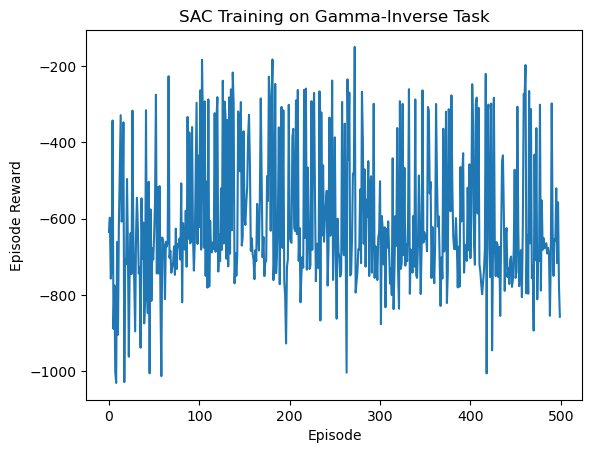

In [531]:
# ========================
# SAC Training for Gamma-Inverse Policy
# ========================

# ---- Define dimensions from your dataset ----
pose_dim = X_feat.shape[1]      # e.g. 6
wrench_dim = W.shape[1]         # should be 6
n_coils = 16

# ---- Build environment ----
# env = GammaInverseEnv(X_feat, W, I, compute_gamma, max_current=10.0)
env = GammaInverseEnv(
    X_feat, W, I,
    compute_gamma,
    pose_scaler, wrench_scaler,
    max_current=10.0,
    coil_weights=coil_weights   # <— pass it here
)



# ---- Build agent ----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# In your training setup:
agent = SACAgent(pose_dim, wrench_dim, n_coils, device=device,
                 physics_weight=1.0,    # Adjust this: higher = more physics focus
                 sup_weight=0.5,        # Imitation weight
                 alpha=0.3)             # SAC entropy coefficient

# ---- Train ----
rewards_history = train_sac(env, agent,
                            buffer_size=5000,
                            batch_size=32,
                            episodes=500,
                            start_steps=1000,
                            updates_per_step=1)

# ---- Plot training curve ----
import matplotlib.pyplot as plt
plt.plot(rewards_history)
plt.xlabel("Episode")
plt.ylabel("Episode Reward")
plt.title("SAC Training on Gamma-Inverse Task")
plt.show()


## End of run of RL

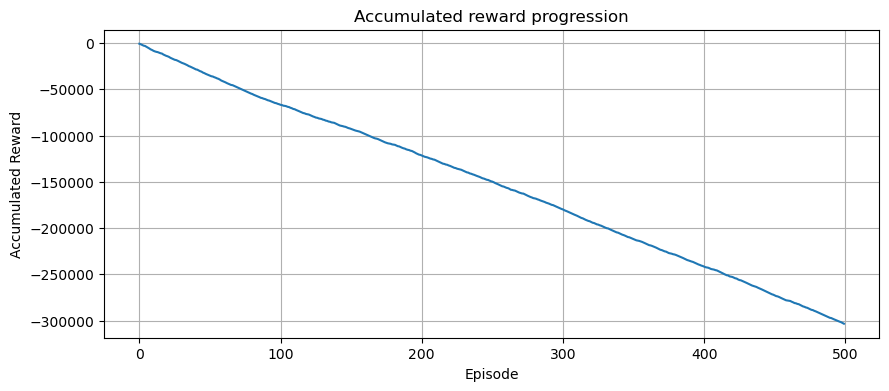

In [532]:
import matplotlib.pyplot as plt
import numpy as np

def plot_accumulated_reward(rewards_history):
    cumulative = np.cumsum(rewards_history)

    plt.figure(figsize=(10,4))
    plt.plot(cumulative)
    plt.xlabel("Episode")
    plt.ylabel("Accumulated Reward")
    plt.title("Accumulated reward progression")
    plt.grid(True)
    plt.show()


plot_accumulated_reward(rewards_history)


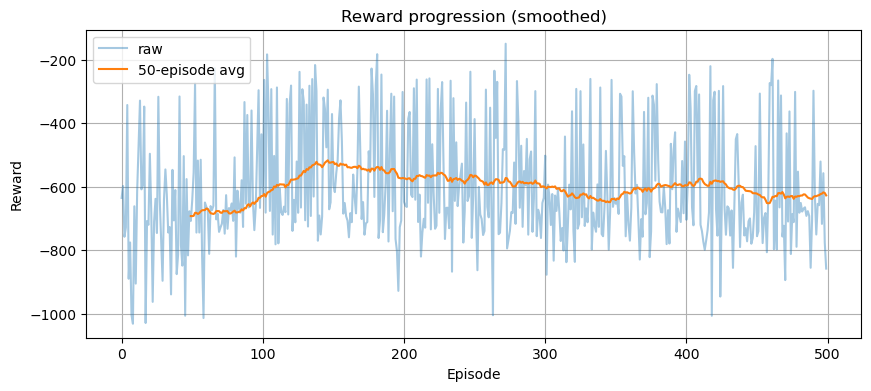

ValueError: expected sequence of length 12 at dim 1 (got 0)

In [533]:
import numpy as np
import matplotlib.pyplot as plt

def training_diagnostics(agent, env, rewards_history, n_eval=200):
    # --- 1. Plot moving average reward ---
    window = 50
    smoothed = np.convolve(rewards_history, np.ones(window)/window, mode="valid")
    plt.figure(figsize=(10,4))
    plt.plot(rewards_history, alpha=0.4, label="raw")
    plt.plot(range(window-1, len(rewards_history)), smoothed, label=f"{window}-episode avg")
    plt.xlabel("Episode")
    plt.ylabel("Reward")
    plt.title("Reward progression (smoothed)")
    plt.legend()
    plt.grid(True)
    plt.show()

    # --- 2. Distribution of wrench reproduction error ---
    errors = []
    for _ in range(n_eval):
        state = env.reset()
        pose = torch.tensor(state[:env.pose_dim], dtype=torch.float32, device=agent.device).unsqueeze(0)
        wrench = torch.tensor(state[env.pose_dim:], dtype=torch.float32, device=agent.device).unsqueeze(0)
        with torch.no_grad():
            pred_currents, _ = agent.actor(pose, wrench)
        pred_currents = pred_currents[0].cpu().numpy()
        Gamma = env.compute_gamma(state[:env.pose_dim])
        if not isinstance(Gamma, np.ndarray):
            Gamma = Gamma.numpy()
        W_out = Gamma @ pred_currents
        err = np.linalg.norm(W_out - state[env.pose_dim:])
        errors.append(err)
    plt.figure(figsize=(6,4))
    plt.hist(errors, bins=20)
    plt.xlabel("‖W_out - W‖ error norm")
    plt.ylabel("Frequency")
    plt.title("Distribution of wrench reproduction errors")
    plt.grid(True)
    plt.show()
    print(f"Mean wrench error: {np.mean(errors):.4f} ± {np.std(errors):.4f}")

    # --- 3. Predicted vs true currents scatter ---
    true_vals, pred_vals = [], []
    for _ in range(n_eval):
        idx = np.random.randint(0, env.n_samples)
        pose = torch.tensor(env.X_feat.iloc[idx].values.astype(np.float32), device=agent.device).unsqueeze(0)
        wrench = torch.tensor(env.W.iloc[idx].values.astype(np.float32), device=agent.device).unsqueeze(0)
        true_currents = env.I.iloc[idx].values.astype(np.float32)
        with torch.no_grad():
            pred_currents, _ = agent.actor(pose, wrench)
        pred_currents = pred_currents[0].cpu().numpy()
        true_vals.extend(true_currents)
        pred_vals.extend(pred_currents)
    plt.figure(figsize=(5,5))
    plt.scatter(true_vals, pred_vals, alpha=0.5)
    lims = [min(true_vals+pred_vals), max(true_vals+pred_vals)]
    plt.plot(lims, lims, "r--")
    plt.xlabel("True currents")
    plt.ylabel("Predicted currents")
    plt.title("True vs Predicted currents")
    plt.grid(True)
    plt.show()

    # --- 4. Coil activation histogram ---
    act_counts = np.zeros(env.n_coils)
    for _ in range(n_eval):
        state = env.reset()
        pose = torch.tensor(state[:env.pose_dim], dtype=torch.float32, device=agent.device).unsqueeze(0)
        wrench = torch.tensor(state[env.pose_dim:], dtype=torch.float32, device=agent.device).unsqueeze(0)
        with torch.no_grad():
            pred_currents, _ = agent.actor(pose, wrench)
        pred_currents = pred_currents[0].cpu().numpy()
        act_counts += (np.abs(pred_currents) > 1e-2).astype(int)
    plt.figure(figsize=(10,4))
    plt.bar(range(env.n_coils), act_counts)
    plt.xlabel("Coil index")
    plt.ylabel("Activation count (nonzero currents)")
    plt.title("Coil usage across evaluation samples")
    plt.show()

training_diagnostics(agent, env, rewards_history, n_eval=200)


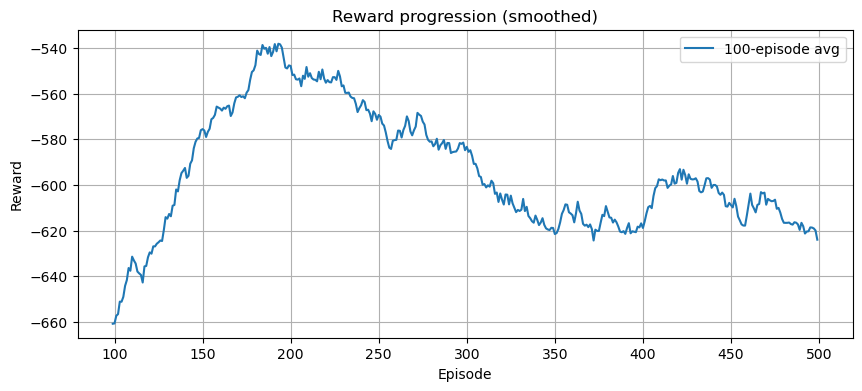

In [535]:
window = 100
smoothed = np.convolve(rewards_history, np.ones(window)/window, mode="valid")

plt.figure(figsize=(10,4))
plt.plot(range(window-1, len(rewards_history)), smoothed, label=f"{window}-episode avg")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Reward progression (smoothed)")
plt.legend()
plt.grid(True)
plt.show()


In [483]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def diagnostics_random_sample(agent, env):
    # --- pick a random index
    idx = np.random.randint(0, env.n_samples)
    pose = env.X_feat.iloc[idx].values.astype(np.float32)
    wrench = env.W.iloc[idx].values.astype(np.float32)
    true_currents = env.I.iloc[idx].values.astype(np.float32)

    pose_t = torch.tensor(pose, dtype=torch.float32, device=agent.device).unsqueeze(0)
    wrench_t = torch.tensor(wrench, dtype=torch.float32, device=agent.device).unsqueeze(0)

    with torch.no_grad():
        # actor forward pass → pred currents
        pred_currents, _ = agent.actor(pose_t, wrench_t)
        pred_currents = pred_currents[0].cpu().numpy()

        # reconstruct Γ⁻¹(p,w) explicitly from ActorLowRank
        x = torch.cat([pose_t, wrench_t], dim=-1)
        h = F.gelu(agent.actor.inp(x))
        for blk in agent.actor.blocks:
            h = blk(h)
        h = agent.actor.out_ln(h)

        U = agent.actor.head_U(h).view(1, agent.actor.n_coils, agent.actor.rank_r)
        V = agent.actor.head_V(h).view(1, agent.actor.wrench_dim, agent.actor.rank_r)
        b_coil   = agent.actor.head_b_coil(h).view(1, agent.actor.n_coils, 1)
        b_wrench = agent.actor.head_b_wrench(h).view(1, 1, agent.actor.wrench_dim)
        mat = (torch.einsum('bir,bjr->bij', U, V) + b_coil + b_wrench)[0].cpu().numpy()  # (16,6)

    # compute realized wrench from pred currents
    Gamma = env.compute_gamma(pose)
    if not isinstance(Gamma, np.ndarray):
        Gamma = Gamma.numpy()
    pred_wrench = Gamma @ pred_currents

    # --- Plotting ---
    fig, axs = plt.subplots(2, 2, figsize=(12, 8))

    # 1. Currents comparison
    axs[0,0].bar(np.arange(env.n_coils)-0.2, true_currents, width=0.4, label="True")
    axs[0,0].bar(np.arange(env.n_coils)+0.2, pred_currents, width=0.4, label="Pred")
    axs[0,0].set_title("Currents (True vs Pred)")
    axs[0,0].set_xlabel("Coil index")
    axs[0,0].set_ylabel("Current (A)")
    axs[0,0].legend()

    # 2. Wrench comparison
    # 2. Wrench comparison
    wrench = np.array(wrench).flatten()
    pred_wrench = np.array(pred_wrench).flatten()

    axs[0,1].bar(np.arange(env.wrench_dim)-0.2, wrench, width=0.4, label="Target")
    axs[0,1].bar(np.arange(env.wrench_dim)+0.2, pred_wrench, width=0.4, label="Pred")
    axs[0,1].set_title("Wrench (Target vs Pred)")
    axs[0,1].set_xlabel("Wrench dim")
    axs[0,1].legend()


    # 3. Gamma inverse heatmap
    im = axs[1,0].imshow(mat, cmap="bwr", aspect="auto")
    axs[1,0].set_title("Learned Γ⁻¹(p,w) matrix")
    axs[1,0].set_xlabel("Wrench dim (6)")
    axs[1,0].set_ylabel("Coil index (16)")
    fig.colorbar(im, ax=axs[1,0])

    # 4. Random placeholder (to illustrate multiple runs)
    axs[1,1].axis("off")
    axs[1,1].text(0.5, 0.5, f"Sample idx = {idx}", fontsize=14,
                  ha="center", va="center")

    plt.tight_layout()
    plt.show()


diagnostics_random_sample(agent, env)


AttributeError: 'Actor' object has no attribute 'inp'

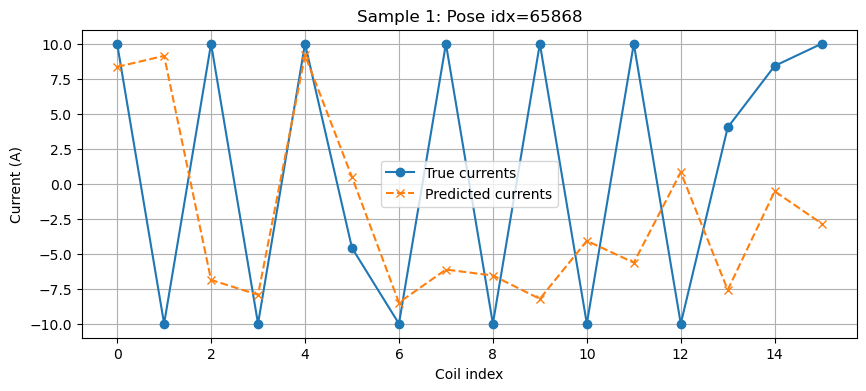

Sample 1 → Error norm: 45.4672


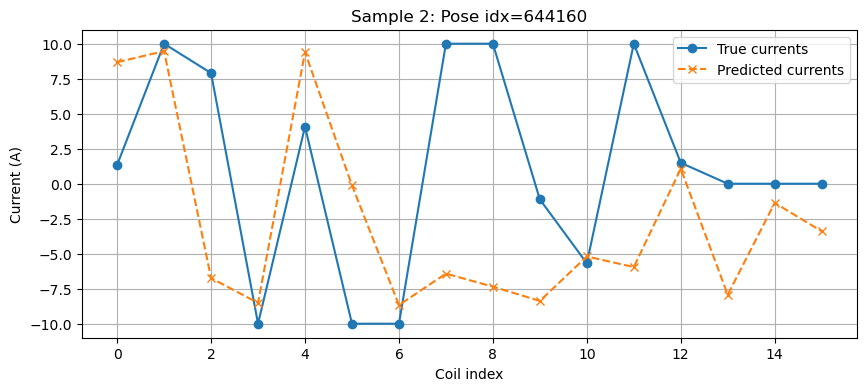

Sample 2 → Error norm: 36.7852


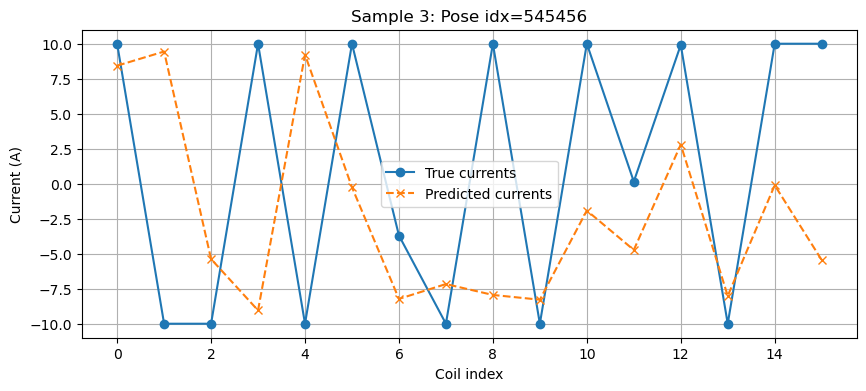

Sample 3 → Error norm: 46.4092


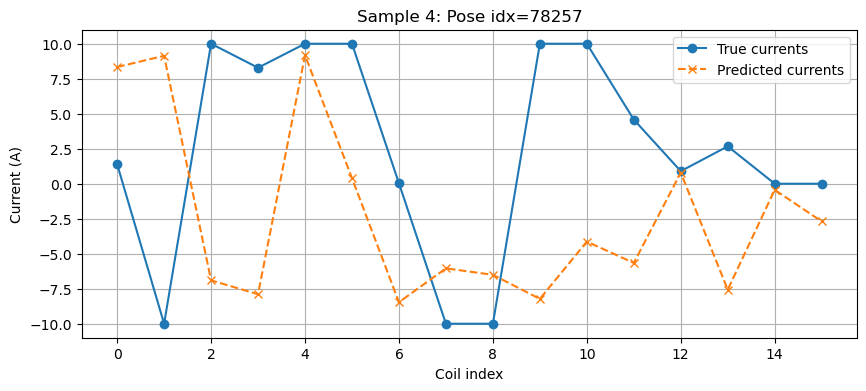

Sample 4 → Error norm: 43.6341


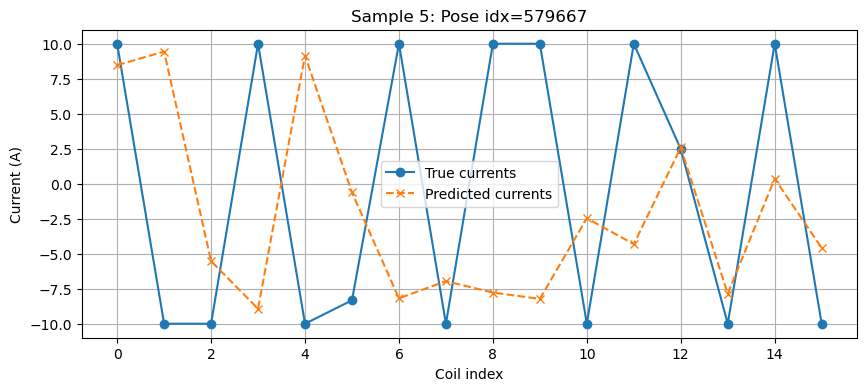

Sample 5 → Error norm: 50.6090


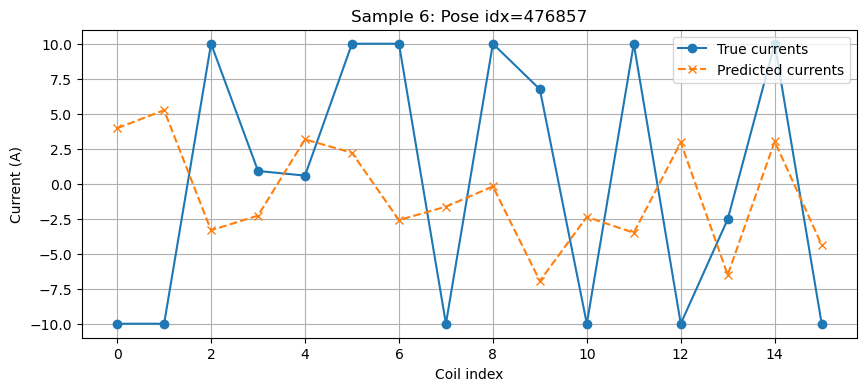

Sample 6 → Error norm: 41.3180


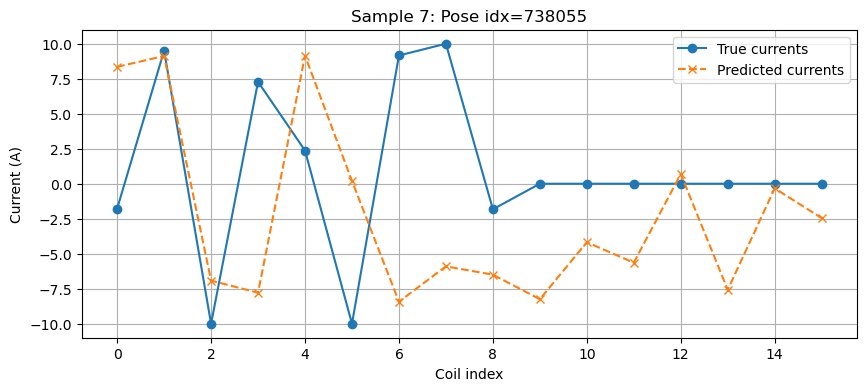

Sample 7 → Error norm: 35.4177


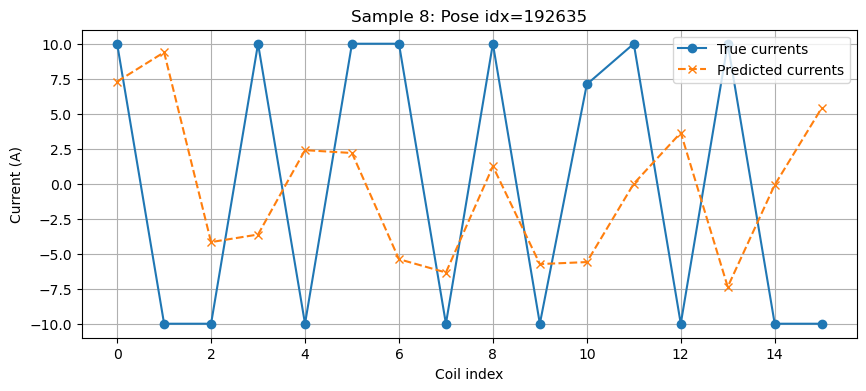

Sample 8 → Error norm: 47.4037


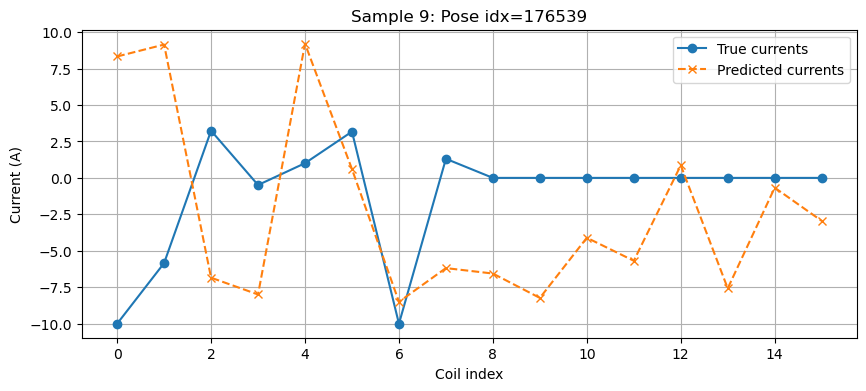

Sample 9 → Error norm: 32.8283


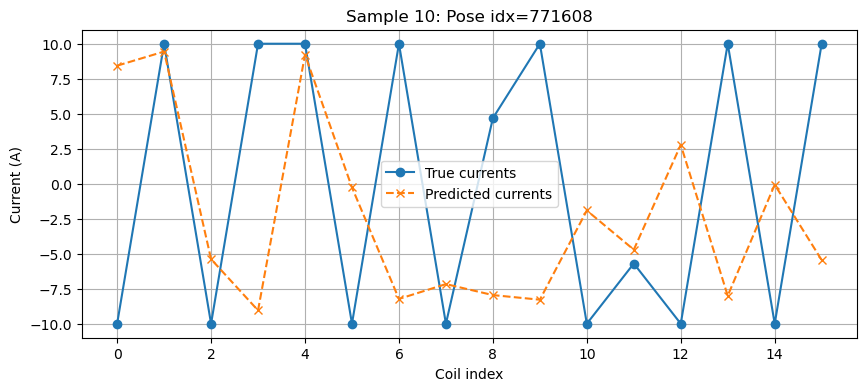

Sample 10 → Error norm: 50.4482


In [536]:
import matplotlib.pyplot as plt

def plot_currents_comparison(agent, env, n_samples=5):
    for i in range(n_samples):
        # pick a random sample from dataset
        idx = np.random.randint(0, env.n_samples)
        pose = torch.tensor(env.X_feat.iloc[idx].values.astype(np.float32), device=agent.device).unsqueeze(0)
        wrench = torch.tensor(env.W.iloc[idx].values.astype(np.float32), device=agent.device).unsqueeze(0)
        true_currents = env.I.iloc[idx].values.astype(np.float32)

        # predict with actor
        with torch.no_grad():
            pred_currents, _ = agent.actor(pose, wrench)
        pred_currents = pred_currents[0].cpu().numpy()

        # --- Plot ---
        plt.figure(figsize=(10,4))
        plt.plot(true_currents, "o-", label="True currents")
        plt.plot(pred_currents, "x--", label="Predicted currents")
        plt.title(f"Sample {i+1}: Pose idx={idx}")
        plt.xlabel("Coil index")
        plt.ylabel("Current (A)")
        plt.legend()
        plt.grid(True)
        plt.show()

        # print error norm for reference
        err = np.linalg.norm(pred_currents - true_currents)
        print(f"Sample {i+1} → Error norm: {err:.4f}")

plot_currents_comparison(agent, env, n_samples=10)


In [538]:
import matplotlib.pyplot as plt
import numpy as np

def performance_diagnostics(agent, env, n_eval=500):
    wrench_norms, error_norms = [], []
    error_per_dim = []

    for _ in range(n_eval):
        idx = np.random.randint(0, env.n_samples)
        pose = torch.tensor(env.X_feat.iloc[idx].values.astype(np.float32), device=agent.device).unsqueeze(0)
        wrench = torch.tensor(env.W.iloc[idx].values.astype(np.float32), device=agent.device).unsqueeze(0)

        with torch.no_grad():
            pred_currents, _ = agent.actor(pose, wrench)
        pred_currents = pred_currents[0].cpu().numpy()

        Gamma = env.compute_gamma(env.X_feat.iloc[idx].values.astype(np.float32))
        if not isinstance(Gamma, np.ndarray):
            Gamma = Gamma.numpy()
        W_out = Gamma @ pred_currents

        target = env.W.iloc[idx].values.astype(np.float32)
        error = W_out - target

        wrench_norms.append(np.linalg.norm(target))
        error_norms.append(np.linalg.norm(error))
        error_per_dim.append(error)

    error_per_dim = np.array(error_per_dim)

    # --- 1. Scatter of error vs wrench magnitude ---
    plt.figure(figsize=(6,5))
    plt.scatter(wrench_norms, error_norms, alpha=0.5)
    plt.xlabel("‖W target‖")
    plt.ylabel("‖W_out - W target‖ (error)")
    plt.title("Error magnitude vs. target wrench magnitude")
    plt.grid(True)
    plt.show()

    # --- 2. Histogram of target wrench magnitudes ---
    plt.figure(figsize=(6,4))
    plt.hist(wrench_norms, bins=30, alpha=0.7)
    plt.xlabel("‖W target‖")
    plt.ylabel("Frequency")
    plt.title("Distribution of target wrench magnitudes")
    plt.grid(True)
    plt.show()

    # --- 3. Boxplot of per-dimension errors ---
    plt.figure(figsize=(8,5))
    if error_per_dim.ndim == 1 or env.wrench_dim == 1:
        # Single wrench dimension → just plot one box
        plt.boxplot(error_per_dim, labels=["W1"])
    else:
        plt.boxplot([error_per_dim[:, i] for i in range(env.wrench_dim)],
                    labels=[f"W{i+1}" for i in range(env.wrench_dim)])
    plt.xlabel("Wrench dimension")
    plt.ylabel("Error (W_out - W)")
    plt.title("Per-dimension wrench error distribution")
    plt.grid(True)
    plt.show()
    
    


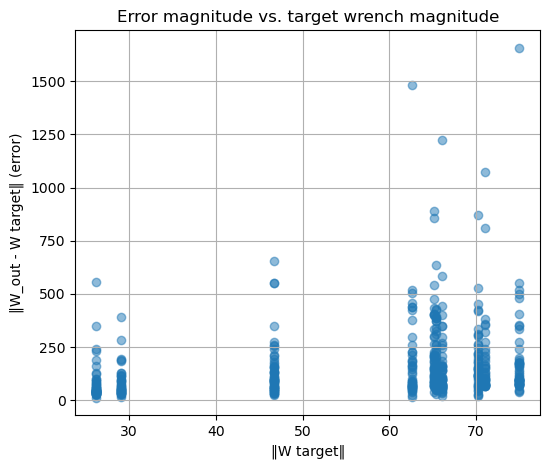

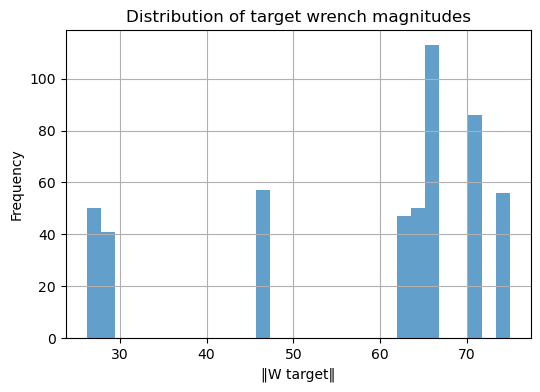

IndexError: index 1 is out of bounds for axis 1 with size 1

<Figure size 800x500 with 0 Axes>

In [539]:
performance_diagnostics(agent, env, n_eval=500)


## Keep other RLs away

In [41]:
import numpy as np
import tensorflow as tf
import gymnasium as gym
from gymnasium import spaces
from sklearn.preprocessing import StandardScaler

# ----------------------------
# Environment
# ----------------------------
class GammaInverseEnv(gym.Env):
    metadata = {"render_modes": []}

    def __init__(self, X_feat, W, W_out, max_current=10.0, episode_len=50):
        super().__init__()

        # Normalize poses once with StandardScaler
        self.scaler = StandardScaler()
        self.X_feat = self.scaler.fit_transform(X_feat)
        self.W      = np.asarray(W, dtype=np.float32)
        self.W_out  = np.asarray(W_out, dtype=np.float32)

        self.n_samples  = self.X_feat.shape[0]
        self.pose_dim   = self.X_feat.shape[1]   # usually 6
        self.wrench_dim = self.W.shape[1]        # 6
        self.n_coils    = 16

        # Spaces
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(self.pose_dim,), dtype=np.float32
        )
        self.action_space = spaces.Box(
            low=-max_current, high=max_current, shape=(self.n_coils,), dtype=np.float32
        )

        # Episode settings
        self.episode_len = episode_len
        self.t = 0
        self.ptr = 0
        self.desired_wrench = None

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.ptr = np.random.randint(0, self.n_samples)
        self.desired_wrench = self.W[self.ptr]
        self.t = 0
        obs = self.X_feat[self.ptr]
        return obs.astype(np.float32), {}

    def step(self, action):
        pose_tf   = tf.convert_to_tensor(self.X_feat[self.ptr][None, :], dtype=tf.float32)
        action_tf = tf.convert_to_tensor(action[None, :], dtype=tf.float32)
    
        Gamma = compute_gamma(pose_tf)
        w_out = tf.matmul(Gamma, tf.expand_dims(action_tf, -1))
        w_out = tf.squeeze(w_out, axis=[0, -1]).numpy()
    
        # reward vs desired wrench
        err = self.desired_wrench - w_out
        reward = -float(np.sum(err**2)) / 1e12
    
        # advance to next sample so obs actually changes
        self.ptr = np.random.randint(0, self.n_samples)
        self.desired_wrench = self.W[self.ptr]
    
        self.t += 1
        terminated = self.t >= self.episode_len
    
        obs = self.X_feat[self.ptr]
        info = {"w_out": w_out, "target": self.desired_wrench}
        return obs.astype(np.float32), reward, terminated, False, info

    def render(self):
        pass

    def close(self):
        pass


In [44]:
import gymnasium as gym
from stable_baselines3 import SAC
from stable_baselines3.common.callbacks import EvalCallback
import numpy as np

# -----------------------
# 1. Wrap your environment
# -----------------------
# --- normalize before env ---
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_feat_norm = scaler.fit_transform(X_feat)

# use normalized features in env
env = GammaInverseEnv(X_feat_norm, W, W_out, max_current=10.0)
eval_env = GammaInverseEnv(X_feat_norm, W, W_out, max_current=10.0)


# Gymnasium → SB3 compatibility wrapper
env = gym.wrappers.TimeLimit(env, max_episode_steps=100)

# -----------------------
# 2. Define SAC model
# -----------------------
model = SAC(
    policy="MlpPolicy",
    env=env,
    learning_rate=3e-4,
    buffer_size=100000,   # replay buffer
    batch_size=256,
    tau=0.005,
    gamma=0.99,
    train_freq=1,
    gradient_steps=1000,
    ent_coef="auto",      # entropy coefficient auto-tuned
    policy_kwargs=dict(
        net_arch=[512, 256, 128]  # actor-critic NN layers
    ),
    verbose=2,
    device="cuda"   # use GPU
)

# -----------------------
# 3. Setup evaluation
# -----------------------
eval_env = GammaInverseEnv(X_feat, W, W_out, max_current=10.0)
eval_env = gym.wrappers.TimeLimit(eval_env, max_episode_steps=100)

eval_callback = EvalCallback(
    eval_env,
    best_model_save_path="./logs/",
    log_path="./logs/",
    eval_freq=5000,
    deterministic=True,
    render=False
)

# -----------------------
# 4. Train the agent
# -----------------------
model.learn(
    total_timesteps=150,  # increase if needed
    callback=eval_callback,
    log_interval=1
)

# -----------------------
# 5. Save trained agent
# -----------------------
model.save("sac_gamma_inverse")


Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
----------------------------------
| rollout/           |           |
|    ep_len_mean     | 50        |
|    ep_rew_mean     | -4.26e+04 |
| time/              |           |
|    episodes        | 1         |
|    fps             | 14        |
|    time_elapsed    | 3         |
|    total_timesteps | 50        |
----------------------------------
----------------------------------
| rollout/           |           |
|    ep_len_mean     | 50        |
|    ep_rew_mean     | -4.41e+04 |
| time/              |           |
|    episodes        | 2         |
|    fps             | 15        |
|    time_elapsed    | 6         |
|    total_timesteps | 100       |
----------------------------------


KeyboardInterrupt: 

In [41]:
import torch
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))


AttributeError: partially initialized module 'torch' has no attribute 'version' (most likely due to a circular import)

In [1]:
import torch
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))


2.5.1+cu121
12.1
True
NVIDIA GeForce RTX 3050 Laptop GPU


# Other things before

In [34]:
import tensorflow as tf
from tensorflow.keras import layers, Model, regularizers

pose_dim   = X_feat.shape[1]   # number of pose features
wrench_dim = W.shape[1]        # should be 6
n_coils    = I.shape[1]        # should be 16
# low-rank dimension (hyperparameter)
rank_r = 16   # can try 8, 16, 32 ...


pose_in   = layers.Input(shape=(pose_dim,), name="pose_input")
wrench_in = layers.Input(shape=(wrench_dim,), name="wrench_input")


# --- Inputs ---
pose_in   = layers.Input(shape=(pose_dim,), name="pose_input")
wrench_in = layers.Input(shape=(wrench_dim,), name="wrench_input")

# --- Pose encoder (deep) ---
x = layers.Dense(512, activation="gelu", kernel_regularizer=regularizers.l2(1e-6))(pose_in)
x = layers.BatchNormalization()(x)
x = layers.Dense(512, activation="gelu", kernel_regularizer=regularizers.l2(1e-6))(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation="gelu", kernel_regularizer=regularizers.l2(1e-6))(x)
x = layers.Dense(128, activation="gelu", kernel_regularizer=regularizers.l2(1e-6))(x)
x = layers.Dense(64, activation="gelu", kernel_regularizer=regularizers.l2(1e-6))(x)


# --- Low-rank factor outputs ---
U_flat = layers.Dense(n_coils * rank_r, name="U_out")(x)
V_flat = layers.Dense(rank_r * wrench_dim, name="V_out")(x)

U = layers.Reshape((n_coils, rank_r), name="U_matrix")(U_flat)
V = layers.Reshape((rank_r, wrench_dim), name="V_matrix")(V_flat)

# --- Construct A(p) ---
A = layers.Lambda(lambda uv: tf.matmul(uv[0], uv[1]),
                  output_shape=(n_coils, wrench_dim),
                  name="A_matrix")([U, V])

# --- Predict currents ---
wrench_exp = layers.Lambda(lambda w: tf.expand_dims(w, -1),
                           output_shape=(wrench_dim,1),
                           name="wrench_expand")(wrench_in)

I_pred = layers.Lambda(lambda x: tf.matmul(x[0], x[1]),
                       output_shape=(n_coils,1),
                       name="I_matmul")([A, wrench_exp])

I_pred = layers.Lambda(lambda i: tf.squeeze(i, -1),
                       output_shape=(n_coils,),
                       name="I_squeezed")(I_pred)

I_pred = layers.Lambda(lambda i: 10.0 * tf.tanh(i),
                       output_shape=(n_coils,),
                       name="currents_pred")(I_pred)

# --- Forward physics Γ(p) ---
Gamma = layers.Lambda(lambda p: compute_gamma(p),
                      output_shape=(6,n_coils),
                      name="Gamma_matrix")(pose_in)

I_exp = layers.Lambda(lambda i: tf.expand_dims(i, -1),
                      output_shape=(n_coils,1),
                      name="I_expand")(I_pred)

W_pred = layers.Lambda(lambda x: tf.matmul(x[0], x[1]),
                       output_shape=(6,1),
                       name="W_matmul")([Gamma, I_exp])

W_pred = layers.Lambda(lambda w: tf.squeeze(w, -1),
                       output_shape=(6,),
                       name="wrench_pred")(W_pred)

# --- Model ---
model = Model(inputs=[pose_in, wrench_in],
              outputs=[I_pred, W_pred],
              name="GammaInversePhysicsNet")

model.summary()


Model: "GammaInversePhysicsNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ pose_input          │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │      3,584 │ pose_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 512)       │      2,048 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 512)       │    262,656 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │    131,328 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128)       │     32,896 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │      8,256 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ U_out (Dense)       │ (None, 256)       │     16,640 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ V_out (Dense)       │ (None, 96)        │      6,240 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ U_matrix (Reshape)  │ (None, 16, 16)    │          0 │ U_out[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ V_matrix (Reshape)  │ (None, 16, 6)     │          0 │ V_out[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ wrench_input        │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ A_matrix (Lambda)   │ (None, 16, 6)     │          0 │ U_matrix[0][0],   │
│                     │                   │            │ V_matrix[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ wrench_expand       │ (None, 6, 1)      │          0 │ wrench_input[0][… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ I_matmul (Lambda)   │ (None, 16, 1)     │          0 │ A_matrix[0][0],   │
│                     │                   │            │ wrench_expand[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ I_squeezed (Lambda) │ (None, 16)        │          0 │ I_matmul[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ currents_pred       │ (None, 16)        │          0 │ I_squeezed[0][0]  │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Gamma_matrix        │ (None, 6, 16)     │          0 │ pose_input[0][0]  │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ I_expand (Lambda)   │ (None, 16, 1)     │          0 │ currents_pred[0]… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 465,696 (1.78 MB)

 Trainable params: 463,648 (1.77 MB)

 Non-trainable params: 2,048 (8.00 KB)

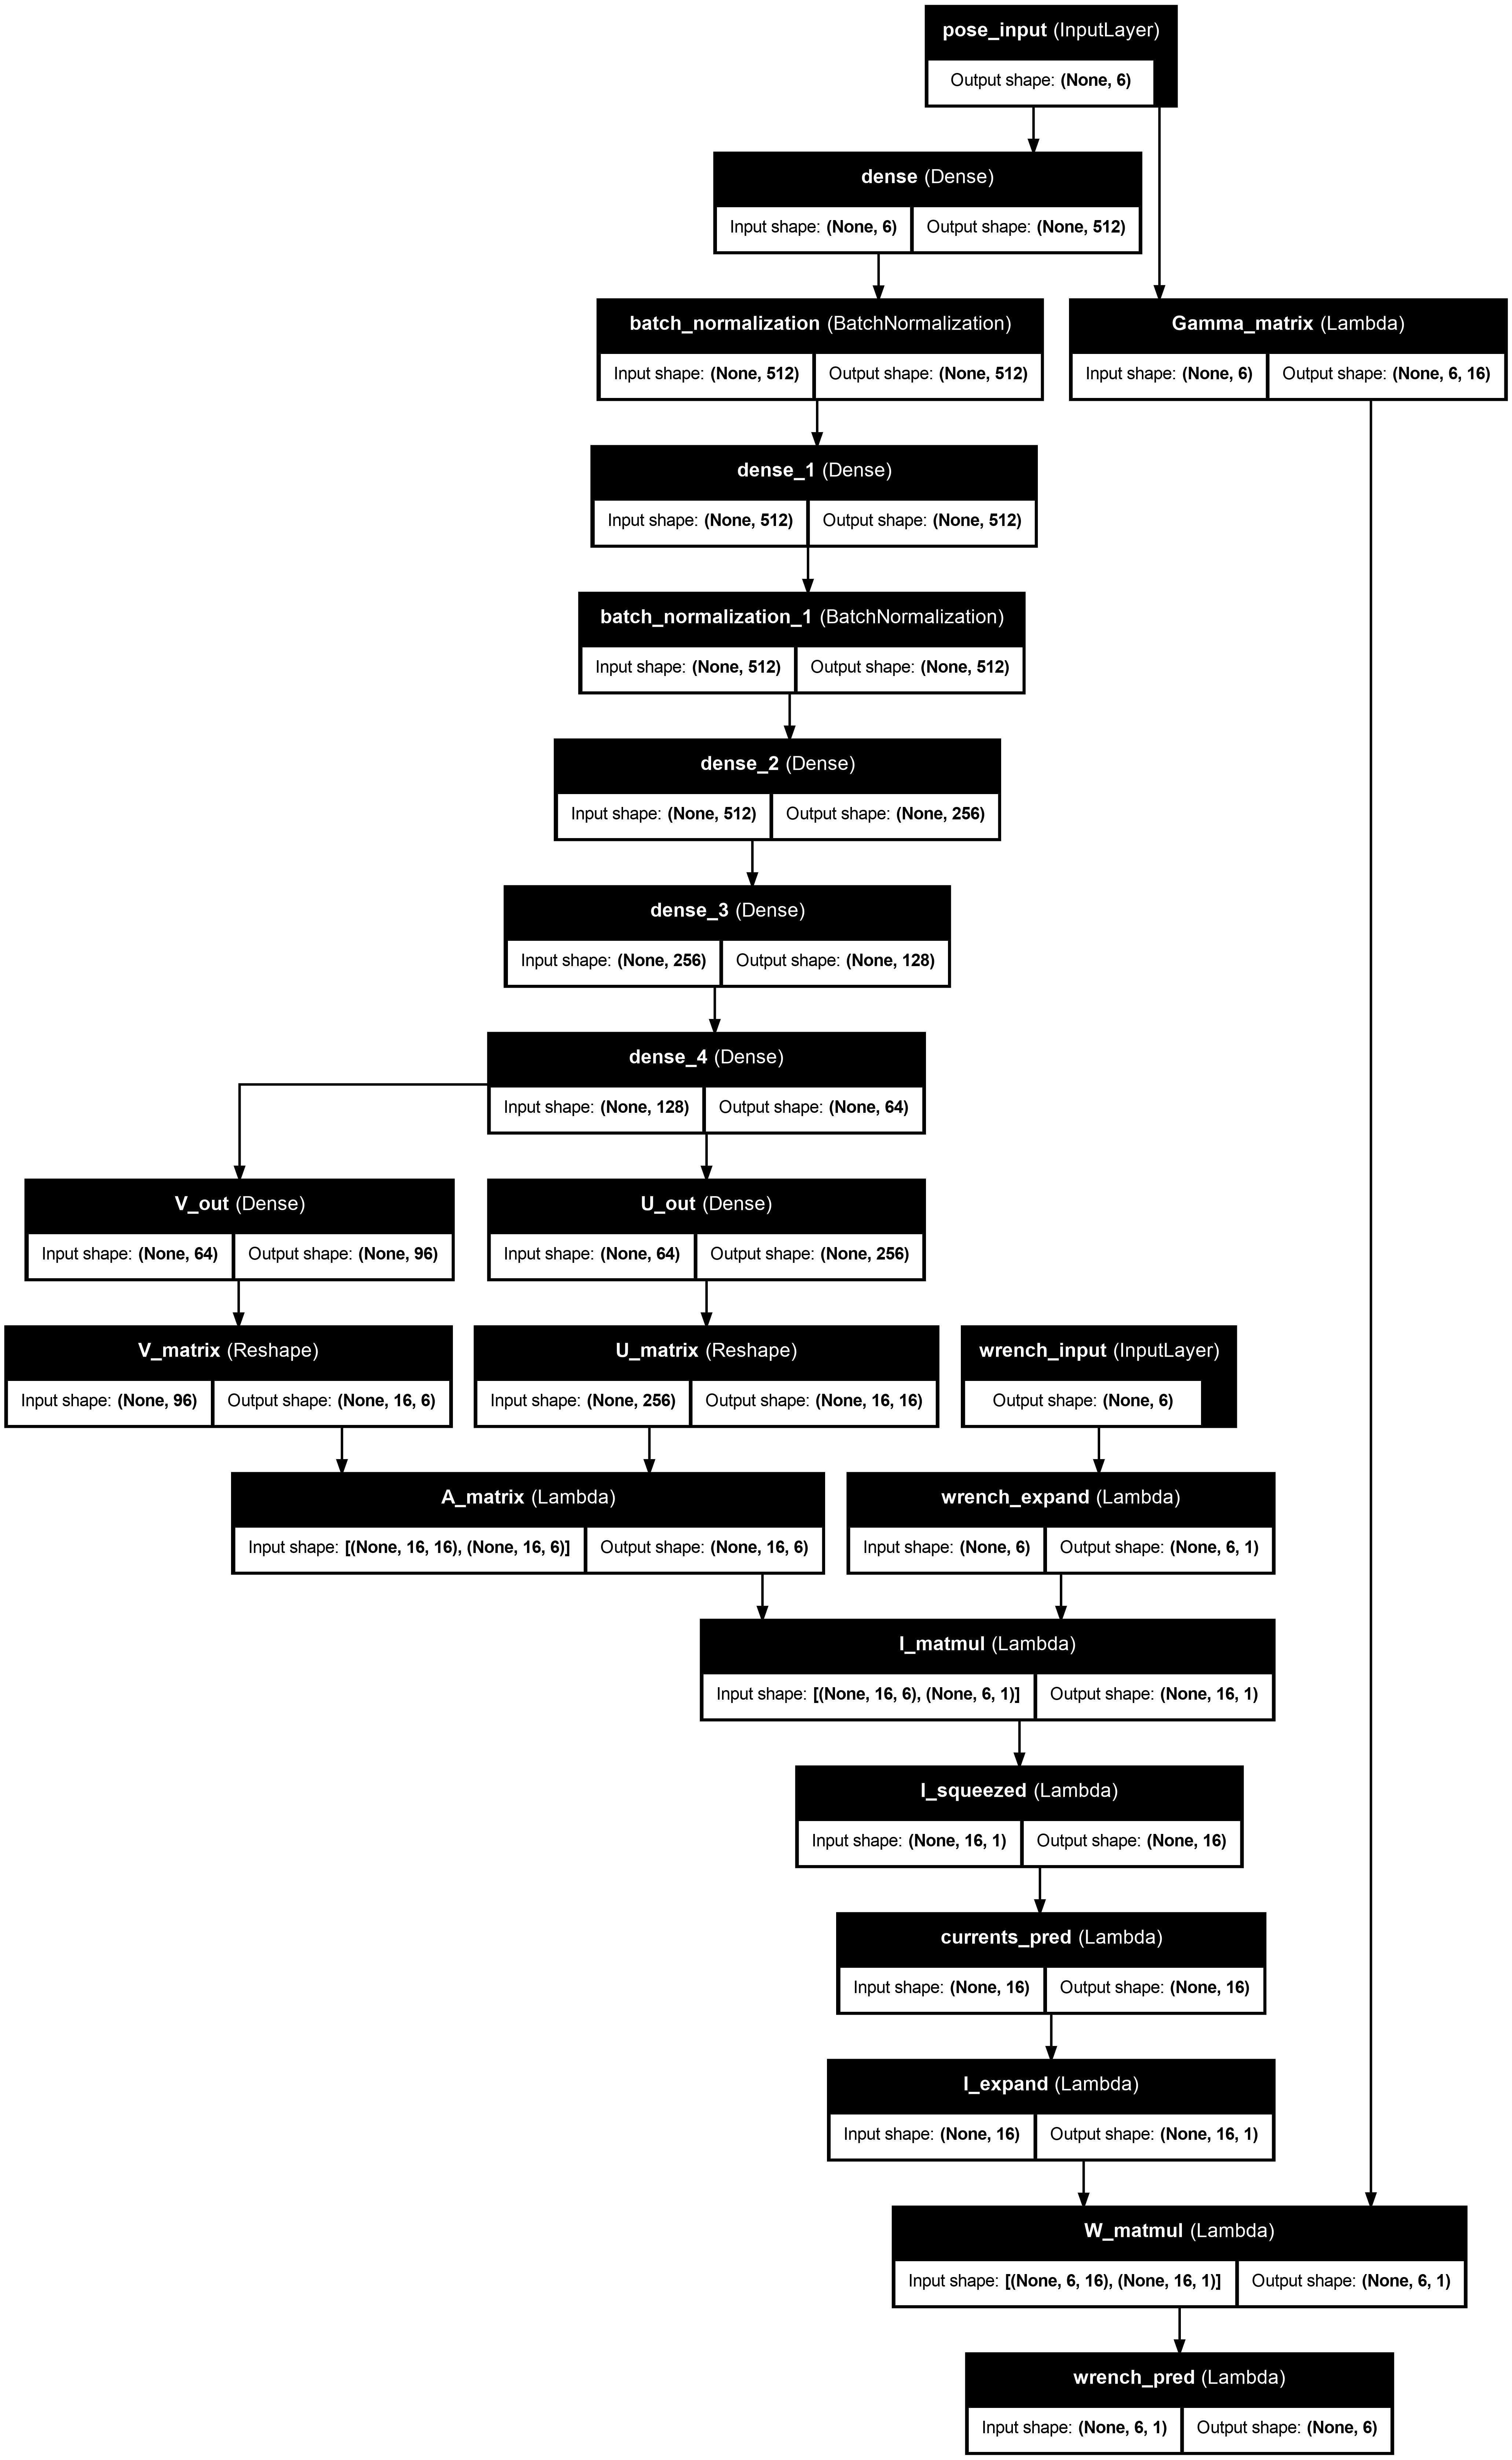

In [35]:
from tensorflow.keras.utils import plot_model

plot_model(
    model,
    to_file="model_structure10.png",
    show_shapes=True,
    show_layer_names=True,
    expand_nested=True,
    dpi=240
)


In [38]:
W_out

array([[-3.01587677e+00,  1.69033208e+01,  5.73525992e+01,
         2.00740743e+00,  1.84917647e-01, -1.24027631e+00],
       [ 1.71768131e+00,  3.66277700e+01,  3.85289768e+00,
         7.42816085e-01,  1.81312828e-01,  2.16042451e-01],
       [ 8.34677636e+00, -1.12472683e+00,  2.00919230e+00,
        -1.20779712e+00,  6.17948601e-01, -3.61195423e-01],
       ...,
       [-5.77306248e+00,  1.36639840e+01,  6.68855193e+01,
        -6.18786153e+00,  4.18683924e-01, -4.21409988e-02],
       [ 1.80015818e+01,  6.18502954e+00,  1.52180386e+01,
         1.04696425e+00,  6.03827537e+00, -8.15177694e+00],
       [-1.42723876e+01,  1.12932010e+01, -6.28735996e+01,
        -3.92452515e+00,  4.22720794e+00, -1.75425182e+00]])

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# --- Split first ---
(Xp_tr_raw, Xp_va_raw,
 Xw_tr_raw, Xw_va_raw,
 Ic_tr_raw, Ic_va_raw,
 Wo_tr_raw, Wo_va_raw) = train_test_split(
    X_feat.values.astype("float32"),
    W.values.astype("float32"),
    I.values.astype("float32"),
    W_out.astype("float32"),
    test_size=0.1, random_state=42, shuffle=True
)

# --- Pose scaler (z-score) ---
scaler_pose = StandardScaler().fit(Xp_tr_raw)
Xp_tr = scaler_pose.transform(Xp_tr_raw)
Xp_va = scaler_pose.transform(Xp_va_raw)

# --- Desired wrench scaler (z-score) ---
scaler_wrench = StandardScaler().fit(Xw_tr_raw)
Xw_tr = scaler_wrench.transform(Xw_tr_raw)
Xw_va = scaler_wrench.transform(Xw_va_raw)

# --- Currents (no scaling, keep physical range [-10,10]) ---
Ic_tr = Ic_tr_raw   # used only for inspection, not training loss
Ic_va = Ic_va_raw

# --- Realized wrench scaler (z-score) ---
scaler_wrench_out = StandardScaler().fit(Wo_tr_raw)
Wo_tr = scaler_wrench_out.transform(Wo_tr_raw)
Wo_va = scaler_wrench_out.transform(Wo_va_raw)

# --- Final inputs/targets ---
train_inputs  = [Xp_tr, Xw_tr]
train_targets = {"currents_pred": Ic_tr, "wrench_pred": Wo_tr}

val_inputs  = [Xp_va, Xw_va]
val_targets = {"currents_pred": Ic_va, "wrench_pred": Wo_va}


In [52]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import ExponentialDecay
import tensorflow as tf

# --- Learning rate schedule ---
lr_schedule = ExponentialDecay(
    initial_learning_rate=1e-3,  # start high for exploration
    decay_steps=5000,
    decay_rate=0.96,
    staircase=True
)

# --- Dynamic weight for wrench loss ---
wrench_weight = tf.Variable(0.0, trainable=False, dtype=tf.float32)

# --- Base MSE loss ---
def mse_loss(y_true, y_pred):
    return tf.reduce_mean(tf.square(y_true - y_pred))

# --- Weighted wrench loss ---
def weighted_mse_wrench(y_true, y_pred):
    return wrench_weight * mse_loss(y_true, y_pred)

# --- Anti-collapse penalty for currents (no ground truth needed) ---
def anti_collapse_loss(y_true, y_pred, penalty_factor=50.0, eps=1e-6):
    # No supervision → ignore y_true, only penalize degenerate predictions
    norms = tf.norm(y_pred, axis=-1)  # (batch,)
    penalty = penalty_factor * tf.reduce_mean(tf.exp(-norms + eps))
    return penalty

# --- Optimizer ---
optimizer = Adam(learning_rate=lr_schedule)

# --- Compile model ---
model.compile(
    optimizer=optimizer,
    loss={
        "currents_pred": anti_collapse_loss,   # only penalty
        "wrench_pred":  weighted_mse_wrench,   # supervised
    },
    metrics={
        "wrench_pred": ["mae"],   # track wrench error
    }
)


In [53]:
class WrenchWeightAnnealer(tf.keras.callbacks.Callback):
    def __init__(self, start_after=10, factor=0.05, every=5, max_wrench=1.0):
        super().__init__()
        self.start_after = start_after
        self.factor = factor
        self.every = every
        self.max_wrench = max_wrench

    def on_epoch_end(self, epoch, logs=None):
        if epoch+1 <= self.start_after:
            wrench_weight.assign(1e-2)
            print(f"[Annealer] Epoch {epoch+1}: wrench_weight held at 1e-6")
            return

        if (epoch+1 - self.start_after) % self.every == 0:
            new_val = min(wrench_weight.numpy() + self.factor, self.max_wrench)
            wrench_weight.assign(new_val)
            print(f"[Annealer] Epoch {epoch+1}: wrench_weight updated → {new_val:.3f}")


In [54]:
annealer = WrenchWeightAnnealer(start_after=10, factor=0.1, every=10)

history = model.fit(
    train_inputs, train_targets,
    validation_data=(val_inputs, val_targets),
    epochs=50,
    batch_size=512,
    callbacks=[annealer],
    verbose=1
)


Epoch 1/50
  70/1386 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - currents_pred_loss: 23.9077 - loss: 23.9134 - wrench_pred_loss: 0.0000e+00 - wrench_pred_mae: 351373.0312

2025-08-27 15:41:40.480435: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'input_clamp_reduce_fusion', 8 bytes spill stores, 8 bytes spill loads



1386/1386 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - currents_pred_loss: 3.0322 - loss: 3.0353 - wrench_pred_loss: 0.0000e+00 - wrench_pred_mae: 8767552.0000

2025-08-27 15:41:51.944525: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'input_clamp_reduce_fusion', 8 bytes spill stores, 8 bytes spill loads

2025-08-27 15:41:59.963564: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'input_reduce_fusion_5', 8 bytes spill stores, 24 bytes spill loads



[Annealer] Epoch 1: wrench_weight held at 1e-6
1386/1386 ━━━━━━━━━━━━━━━━━━━━ 38s 20ms/step - currents_pred_loss: 0.6135 - loss: 0.6156 - wrench_pred_loss: 0.0000e+00 - wrench_pred_mae: 11091944.0000 - val_currents_pred_loss: 4.6796e-14 - val_loss: 8.3622e-04 - val_wrench_pred_loss: 0.0000e+00 - val_wrench_pred_mae: 12858849.0000
Epoch 2/50
  46/1386 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - currents_pred_loss: 1.5009 - loss: 2601739091968.0000 - wrench_pred_loss: 2601739091968.0000 - wrench_pred_mae: 6591462.5000      

2025-08-27 15:42:07.792732: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'input_reduce_fusion_6', 4 bytes spill stores, 12 bytes spill loads



1364/1386 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - currents_pred_loss: 33.6442 - loss: 221598924800.0000 - wrench_pred_loss: 221598924800.0000 - wrench_pred_mae: 652364.0000[Annealer] Epoch 2: wrench_weight held at 1e-6
1386/1386 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - currents_pred_loss: 40.5055 - loss: 39019737088.0000 - wrench_pred_loss: 39014785024.0000 - wrench_pred_mae: 143983.2500 - val_currents_pred_loss: 44.7533 - val_loss: 8373814.0000 - val_wrench_pred_loss: 8373563.0000 - val_wrench_pred_mae: 13528.7217
Epoch 3/50
1366/1386 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - currents_pred_loss: 45.0993 - loss: 6756014.0000 - wrench_pred_loss: 6755971.0000 - wrench_pred_mae: 11936.0654[Annealer] Epoch 3: wrench_weight held at 1e-6
1386/1386 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - currents_pred_loss: 45.4218 - loss: 5239871.0000 - wrench_pred_loss: 5239439.5000 - wrench_pred_mae: 10425.3828 - val_currents_pred_loss: 45.9657 - val_loss: 2660495.2500 - val_wrench_pred_loss: 2660380.0000 - val_wrench_pred_mae: 

In [55]:
sample_pose = X_feat.values[:8].astype("float32")
sample_wrench = W.values[:8].astype("float32")

I_pred, W_pred = model([sample_pose, sample_wrench], training=False)

print("I_pred max:", tf.reduce_max(tf.abs(I_pred)).numpy())
print("W_pred max:", tf.reduce_max(tf.abs(W_pred)).numpy())


I_pred max: 0.00018578184
W_pred max: 0.0024576567


In [85]:
sample_pose = X_feat.values[:4].astype("float32")
sample_wrench = W.values[:4].astype("float32")

I_test, W_test = model([sample_pose, sample_wrench], training=False)
print("Max current:", tf.reduce_max(tf.abs(I_test)).numpy())
print("Max wrench:", tf.reduce_max(tf.abs(W_test)).numpy())


Max current: 8.1433234e-07
Max wrench: 5.6699664e-06


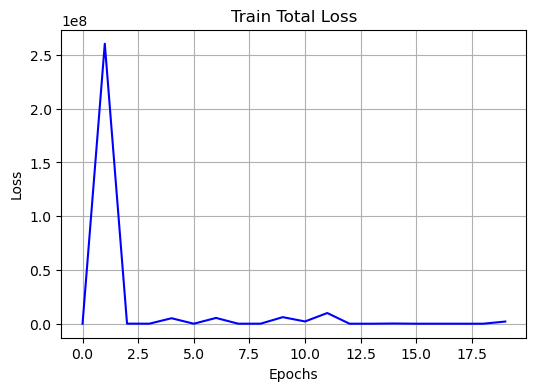

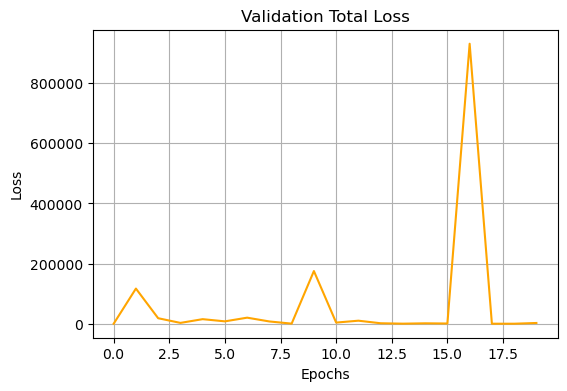

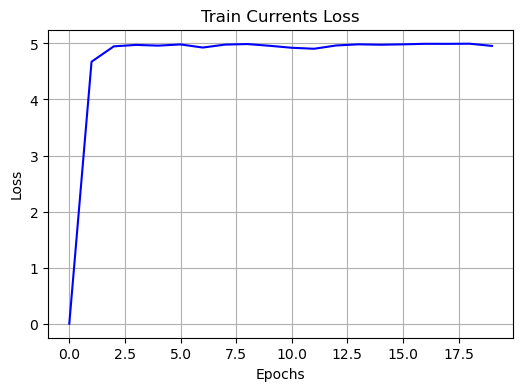

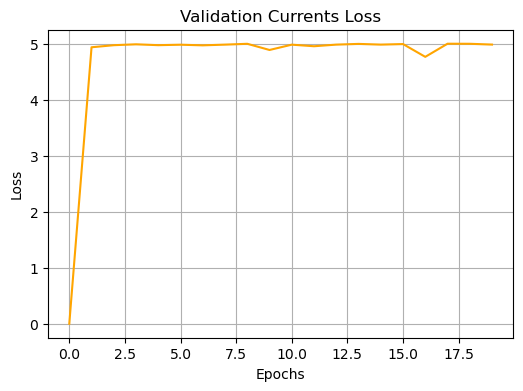

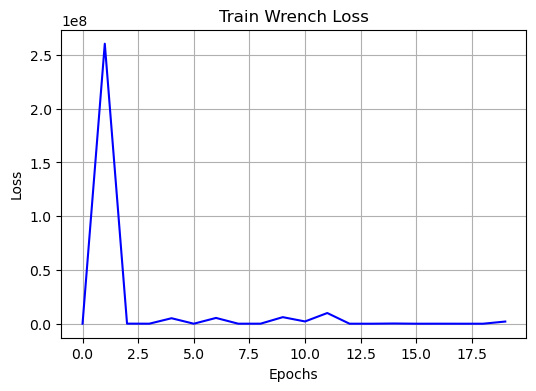

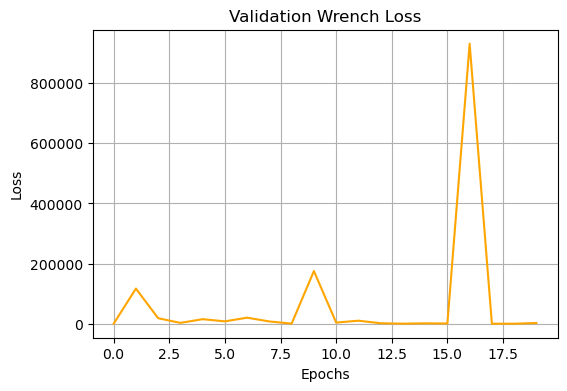

In [46]:
import matplotlib.pyplot as plt

def plot_losses_separately(history):
    # --- Total Loss ---
    plt.figure(figsize=(6,4))
    plt.plot(history.history["loss"], label="Train Total Loss", color="blue")
    plt.xlabel("Epochs"); plt.ylabel("Loss")
    plt.title("Train Total Loss")
    plt.grid(True); plt.show()

    plt.figure(figsize=(6,4))
    plt.plot(history.history["val_loss"], label="Val Total Loss", color="orange")
    plt.xlabel("Epochs"); plt.ylabel("Loss")
    plt.title("Validation Total Loss")
    plt.grid(True); plt.show()

    # --- Currents Loss ---
    if "currents_pred_loss" in history.history:
        plt.figure(figsize=(6,4))
        plt.plot(history.history["currents_pred_loss"], label="Train Currents Loss", color="blue")
        plt.xlabel("Epochs"); plt.ylabel("Loss")
        plt.title("Train Currents Loss")
        plt.grid(True); plt.show()

        plt.figure(figsize=(6,4))
        plt.plot(history.history["val_currents_pred_loss"], label="Val Currents Loss", color="orange")
        plt.xlabel("Epochs"); plt.ylabel("Loss")
        plt.title("Validation Currents Loss")
        plt.grid(True); plt.show()

    # --- Wrench Loss ---
    if "wrench_pred_loss" in history.history:
        plt.figure(figsize=(6,4))
        plt.plot(history.history["wrench_pred_loss"], label="Train Wrench Loss", color="blue")
        plt.xlabel("Epochs"); plt.ylabel("Loss")
        plt.title("Train Wrench Loss")
        plt.grid(True); plt.show()

        plt.figure(figsize=(6,4))
        plt.plot(history.history["val_wrench_pred_loss"], label="Val Wrench Loss", color="orange")
        plt.xlabel("Epochs"); plt.ylabel("Loss")
        plt.title("Validation Wrench Loss")
        plt.grid(True); plt.show()

# Call after training
plot_losses_separately(history)

In [87]:
report = regression_report(model, val_inputs, val_targets,
                          scaler_currents=True,
                          scaler_wrench=scaler_wrench_out)

NameError: name 'regression_report' is not defined

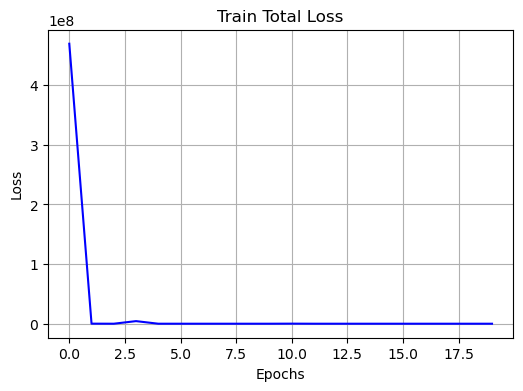

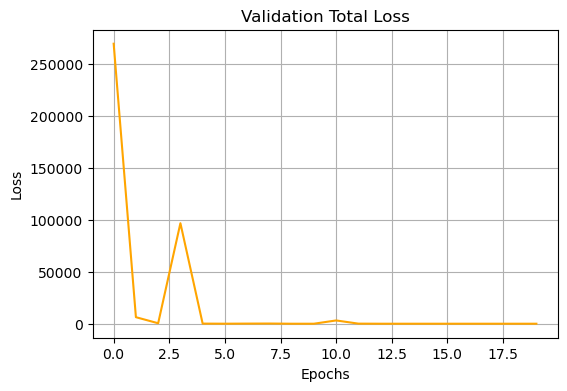

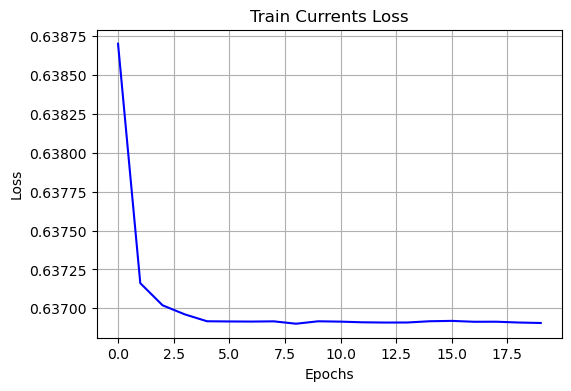

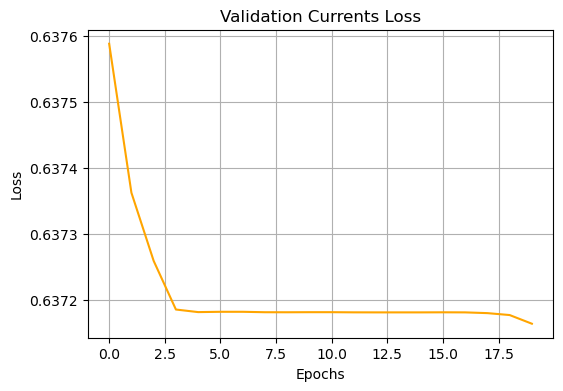

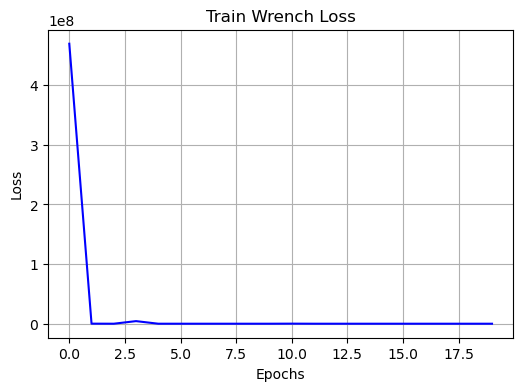

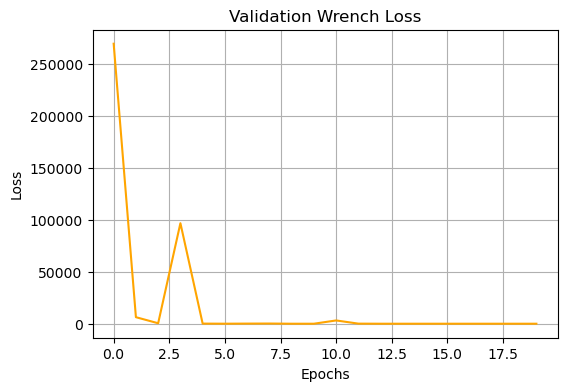

In [88]:
import matplotlib.pyplot as plt

def plot_losses_separately(history):
    # --- Total Loss ---
    plt.figure(figsize=(6,4))
    plt.plot(history.history["loss"], label="Train Total Loss", color="blue")
    plt.xlabel("Epochs"); plt.ylabel("Loss")
    plt.title("Train Total Loss")
    plt.grid(True); plt.show()

    plt.figure(figsize=(6,4))
    plt.plot(history.history["val_loss"], label="Val Total Loss", color="orange")
    plt.xlabel("Epochs"); plt.ylabel("Loss")
    plt.title("Validation Total Loss")
    plt.grid(True); plt.show()

    # --- Currents Loss ---
    if "currents_pred_loss" in history.history:
        plt.figure(figsize=(6,4))
        plt.plot(history.history["currents_pred_loss"], label="Train Currents Loss", color="blue")
        plt.xlabel("Epochs"); plt.ylabel("Loss")
        plt.title("Train Currents Loss")
        plt.grid(True); plt.show()

        plt.figure(figsize=(6,4))
        plt.plot(history.history["val_currents_pred_loss"], label="Val Currents Loss", color="orange")
        plt.xlabel("Epochs"); plt.ylabel("Loss")
        plt.title("Validation Currents Loss")
        plt.grid(True); plt.show()

    # --- Wrench Loss ---
    if "wrench_pred_loss" in history.history:
        plt.figure(figsize=(6,4))
        plt.plot(history.history["wrench_pred_loss"], label="Train Wrench Loss", color="blue")
        plt.xlabel("Epochs"); plt.ylabel("Loss")
        plt.title("Train Wrench Loss")
        plt.grid(True); plt.show()

        plt.figure(figsize=(6,4))
        plt.plot(history.history["val_wrench_pred_loss"], label="Val Wrench Loss", color="orange")
        plt.xlabel("Epochs"); plt.ylabel("Loss")
        plt.title("Validation Wrench Loss")
        plt.grid(True); plt.show()

# Call after training
plot_losses_separately(history)


In [47]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def regression_report(model, val_inputs, val_targets,
                      scaler_currents=None, scaler_wrench=None):
    """
    Generate regression metrics (MAE, MSE, R²) for currents and wrench.
    Assumes currents were scaled by /10, and wrench normalized with StandardScaler.
    """

    # --- Predictions ---
    preds = model.predict(val_inputs, verbose=0)
    I_pred, W_pred = preds[0], preds[1]

    I_true = val_targets["currents_pred"]
    W_true = val_targets["wrench_pred"]

    # --- Denormalize if scalers provided ---
    if scaler_currents is not None:
        I_pred = I_pred * 10.0
        I_true = I_true * 10.0

    if scaler_wrench is not None:
        W_pred = scaler_wrench.inverse_transform(W_pred)
        W_true = scaler_wrench.inverse_transform(W_true)

    # --- Metrics for currents ---
    I_mae = mean_absolute_error(I_true, I_pred)
    I_mse = mean_squared_error(I_true, I_pred)
    I_r2  = r2_score(I_true, I_pred)

    # --- Metrics for wrench ---
    W_mae = mean_absolute_error(W_true, W_pred)
    W_mse = mean_squared_error(W_true, W_pred)
    W_r2  = r2_score(W_true, W_pred)

    print("===== Regression Report =====")
    print("Currents:")
    print(f"  MAE : {I_mae:.4f}")
    print(f"  MSE : {I_mse:.4f}")
    print(f"  R²  : {I_r2:.4f}")
    print("")
    print("Wrench:")
    print(f"  MAE : {W_mae:.4f}")
    print(f"  MSE : {W_mse:.4f}")
    print(f"  R²  : {W_r2:.4f}")

    return {
        "currents": {"MAE": I_mae, "MSE": I_mse, "R2": I_r2},
        "wrench":   {"MAE": W_mae, "MSE": W_mse, "R2": W_r2}
    }

# Example call:
report = regression_report(model, val_inputs, val_targets,
                          scaler_currents=True,
                          scaler_wrench=scaler_wrench_out)


===== Regression Report =====
Currents:
  MAE : 68.1152
  MSE : 6371.3477
  R²  : 0.0000

Wrench:
  MAE : 11750.3799
  MSE : 855648576.0000
  R²  : -2315995.7500


In [77]:
import numpy as np

def debug_predictions(model, val_inputs, val_targets, batch_size=5):
    """
    Print a small batch of true vs predicted currents & wrenches (normalized space).
    """
    # --- Get a random batch ---
    idx = np.random.choice(len(val_inputs[0]), size=batch_size, replace=False)
    batch_inputs = [val_inputs[0][idx], val_inputs[1][idx]]  # [pose, wrench]
    batch_targets_I = val_targets["currents_pred"][idx]
    batch_targets_W = val_targets["wrench_pred"][idx]

    # --- Model predictions ---
    I_pred, W_pred = model.predict(batch_inputs, verbose=0)

    print("===== Debug Predictions (Normalized Space) =====")
    for i in range(batch_size):
        print(f"\nSample {i+1}")
        print(" True Currents  :", np.round(batch_targets_I[i], 3))
        print(" Pred Currents  :", np.round(I_pred[i], 3))
        print(" True Wrench    :", np.round(batch_targets_W[i], 3))
        print(" Pred Wrench    :", np.round(W_pred[i], 3))

# Example call:
debug_predictions(model, val_inputs, val_targets, batch_size=5)


===== Debug Predictions (Normalized Space) =====

Sample 1
 True Currents  : [-0.858  1.     1.    -0.749 -1.     1.     1.    -1.     1.    -1.
 -1.     1.    -1.     0.061  1.    -1.   ]
 Pred Currents  : [-0.  0.  0.  0.  0.  0.  0.  0. -0.  0. -0.  0. -0. -0. -0.  0.]
 True Wrench    : [ 1.979e+00 -1.076e+00  6.450e-01 -5.380e-01 -8.500e-02  1.000e-03]
 Pred Wrench    : [-0. -0. -0.  0. -0.  0.]

Sample 2
 True Currents  : [ 0.092 -0.163  0.102 -0.005 -0.173  0.382  0.     0.     0.    -0.
 -0.     0.     0.    -0.    -0.     0.   ]
 Pred Currents  : [ 0. -0. -0. -0. -0. -0.  0. -0.  0. -0.  0. -0. -0. -0.  0.  0.]
 True Wrench    : [ 0.224 -0.184 -0.219  0.129 -0.019  0.001]
 Pred Wrench    : [-0.176 -0.195 -0.013 -0.017 -0.012  0.106]

Sample 3
 True Currents  : [ 1.    -1.     1.    -1.    -1.     1.    -1.     1.    -0.089 -0.089
  1.    -1.     1.    -1.     1.    -1.   ]
 Pred Currents  : [-0.  0.  0.  0.  0.  0.  0.  0.  0.  0. -0.  0. -0. -0. -0.  0.]
 True Wrench    : [-9.

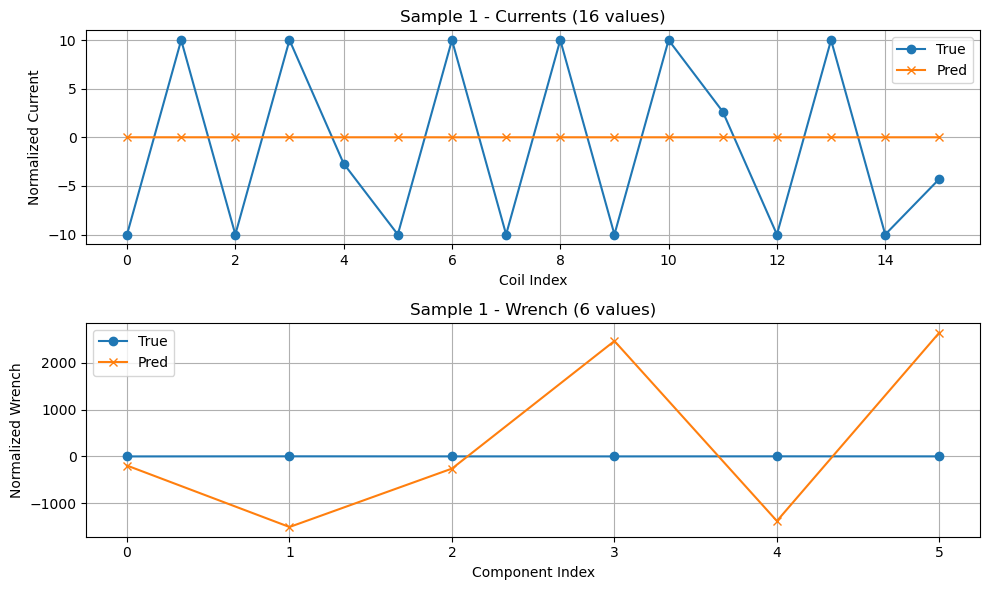

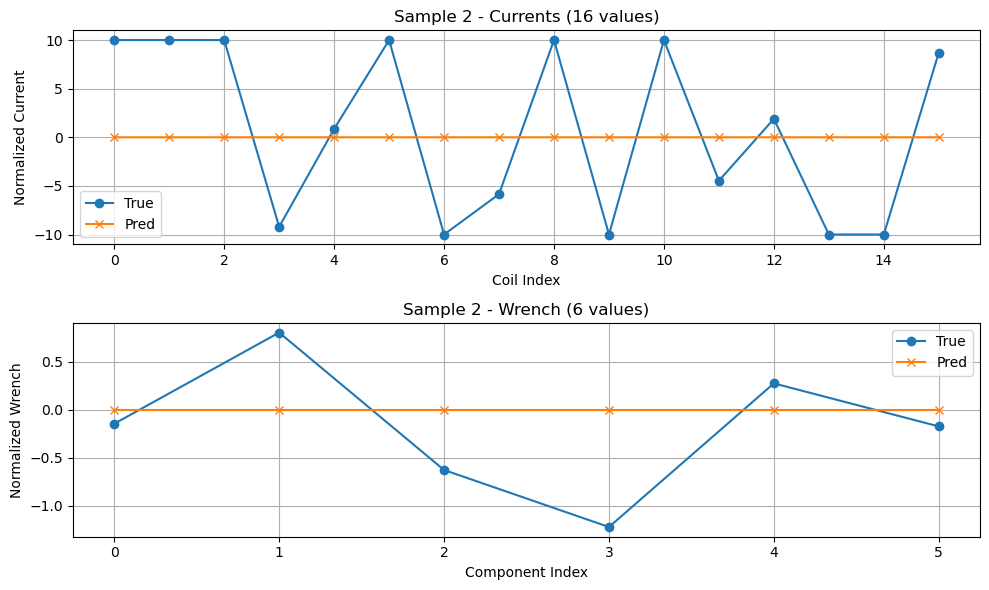

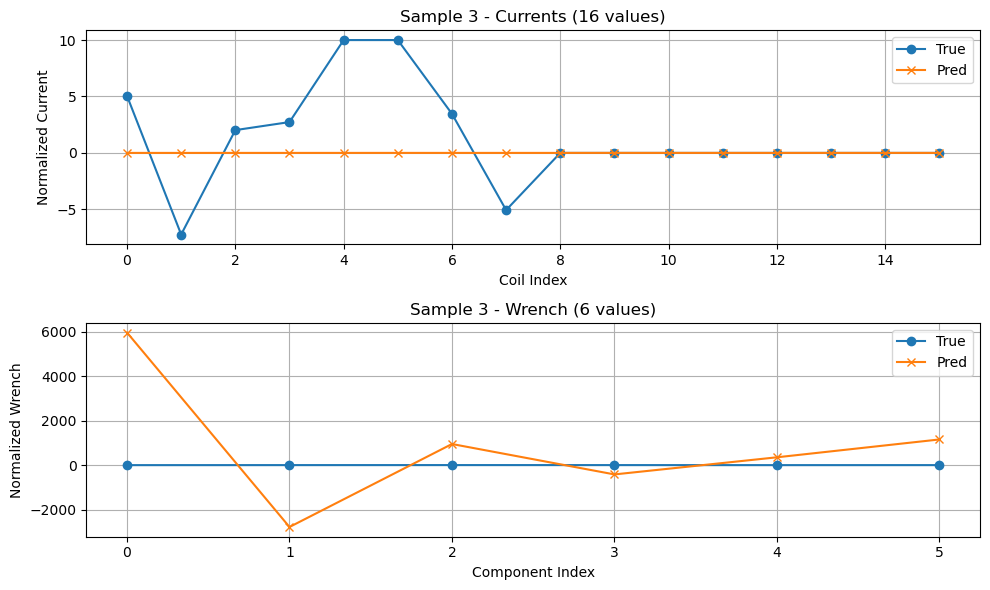

In [48]:
import matplotlib.pyplot as plt
import numpy as np

def plot_debug_predictions(model, val_inputs, val_targets, num_samples=3):
    """
    Plot predicted vs true currents (16) and wrenches (6) for a few validation samples.
    """
    # pick random samples
    idx = np.random.choice(len(val_inputs[0]), size=num_samples, replace=False)
    batch_inputs = [val_inputs[0][idx], val_inputs[1][idx]]
    I_true = val_targets["currents_pred"][idx]
    W_true = val_targets["wrench_pred"][idx]

    I_pred, W_pred = model.predict(batch_inputs, verbose=0)

    for i in range(num_samples):
        fig, axs = plt.subplots(2, 1, figsize=(10,6))

        # --- Currents (16) ---
        axs[0].plot(I_true[i], label="True", marker="o")
        axs[0].plot(I_pred[i], label="Pred", marker="x")
        axs[0].set_title(f"Sample {i+1} - Currents (16 values)")
        axs[0].set_xlabel("Coil Index")
        axs[0].set_ylabel("Normalized Current")
        axs[0].grid(True); axs[0].legend()

        # --- Wrench (6) ---
        axs[1].plot(W_true[i], label="True", marker="o")
        axs[1].plot(W_pred[i], label="Pred", marker="x")
        axs[1].set_title(f"Sample {i+1} - Wrench (6 values)")
        axs[1].set_xlabel("Component Index")
        axs[1].set_ylabel("Normalized Wrench")
        axs[1].grid(True); axs[1].legend()

        plt.tight_layout()
        plt.show()

# Example call:
plot_debug_predictions(model, val_inputs, val_targets, num_samples=3)


# PCA on currents

In [36]:
I.head()

,current_1_cls,current_2_cls,current_3_cls,current_4_cls,current_5_cls,current_6_cls,current_7_cls,current_8_cls,current_9_cls,current_10_cls,current_11_cls,current_12_cls,current_13_cls,current_14_cls,current_15_cls,current_16_cls
0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
1,2,2,1,2,2,1,0,1,1,1,1,1,1,1,1,1
2,1,1,0,2,1,0,2,1,1,1,1,1,1,1,1,1
3,1,1,1,0,1,1,1,1,1,1,1,1,1,1,1,1
4,0,0,0,2,2,2,0,2,1,1,1,2,0,2,1,1


In [41]:
I.columns

Index(['current_1_cls', 'current_2_cls', 'current_3_cls', 'current_4_cls',
       'current_5_cls', 'current_6_cls', 'current_7_cls', 'current_8_cls',
       'current_9_cls', 'current_10_cls', 'current_11_cls', 'current_12_cls',
       'current_13_cls', 'current_14_cls', 'current_15_cls', 'current_16_cls'],
      dtype='object')

In [36]:
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from scipy import sparse

# one-hot encode the dataframe
enc = OneHotEncoder(sparse_output=True, dtype=np.float32)  # sparse to save RAM
X_encoded = enc.fit_transform(I)

print(f"Encoded shape: {X_encoded.shape}, sparse={sparse.issparse(X_encoded)}")


Encoded shape: (1287658, 48), sparse=True


In [37]:
from sklearn.decomposition import TruncatedSVD

# compress to ~40 components (safe since you only had 48 one-hot cols)
svd = TruncatedSVD(n_components=40, random_state=42)
X_svd = svd.fit_transform(X_encoded).astype(np.float32)

print("SVD reduced shape:", X_svd.shape)


SVD reduced shape: (1287658, 40)


In [38]:
import umap.umap_ as umap

# Subsample before SVD/UMAP
frac = 0.5
n_sub = int(frac * X_encoded.shape[0])
idx = np.random.choice(X_encoded.shape[0], size=n_sub, replace=False)

X_sub = X_encoded[idx]
X_svd = svd.fit_transform(X_sub).astype(np.float32)

um_hi = umap.UMAP(n_components=10, n_neighbors=30, min_dist=0.05, random_state=42)
X_umap10 = um_hi.fit_transform(X_svd)


/home/alireza-linux/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/alireza-linux/.local/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [45]:
Xc = X_umap10  # use the 10D UMAP embedding as clustering input


In [47]:
# FAST GMM: BIC on a small sample + diag cov, then final full fit

from sklearn.mixture import GaussianMixture
from sklearn.cluster import MiniBatchKMeans
import numpy as np

# ---- 1) small sample for BIC sweep ----
m = min(20000, len(Xc))
idx_bic = np.random.choice(len(Xc), size=m, replace=False)
Xc_bic = Xc[idx_bic].astype(np.float32)
Xc_bic = Xc_bic.astype(np.float64)


k_list = [8, 12, 16, 20]  # tighten sweep first; refine around the winner later
bic_log, models = [], {}

for k in k_list:
    km = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=4096, n_init=5)
    km.fit(Xc_bic)
    gmm_diag = GaussianMixture(
    n_components=k, covariance_type="diag",
    reg_covar=1e-4, max_iter=200, n_init=1, tol=1e-3,
    means_init=km.cluster_centers_, random_state=42
    ).fit(Xc_bic)
    bic = gmm_diag.bic(Xc_bic)
    bic_log.append((k, bic))
    models[k] = gmm_diag
    print(f"k={k}, BIC={bic:.2f}")

best_k, best_bic = min(bic_log, key=lambda t: t[1])
print(f"\nSelected k (sampled BIC) = {best_k}")

# ---- 2) final fit on ALL Xc (option A: diag, fast) ----
gmm = GaussianMixture(
    n_components=best_k, covariance_type="diag",
    reg_covar=1e-6, max_iter=300, n_init=2, tol=1e-3,
    means_init=models[best_k].means_, random_state=42, verbose=1
).fit(Xc.astype(np.float32))

# (option B: if you really want full cov, switch covariance_type="full" here;
# keep means_init from diag model to speed convergence.)

labels = gmm.predict(Xc)
proba  = gmm.predict_proba(Xc)
print(f"Done. k={best_k}, proba shape={proba.shape}")



k=8, BIC=595118.59
k=12, BIC=594255.31
k=16, BIC=565986.22
k=20, BIC=495822.52

Selected k (sampled BIC) = 20
Initialization 0
  Iteration 10
  Iteration 20
  Iteration 30
Initialization converged.
Initialization 1
  Iteration 10
Initialization converged.
Done. k=20, proba shape=(643829, 20)


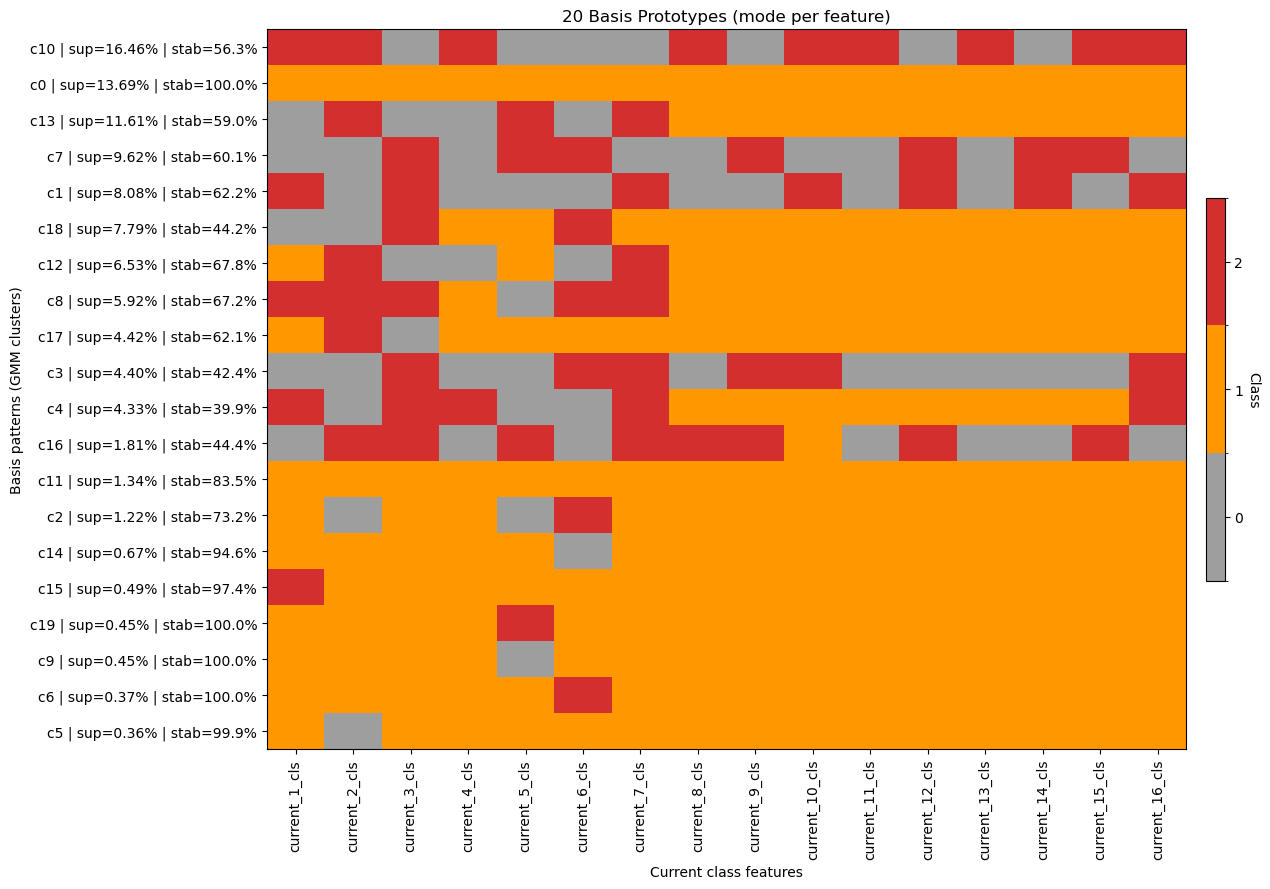

In [48]:
# === Build 20 basis patterns from GMM on your 0.5% subset ===
# Requires: I (original df), idx (indices of the 0.5% subset),
#           labels (shape [len(idx)]), proba (shape [len(idx), 20])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

# 1) attach cluster labels to the subsample
I_sub = I.iloc[idx].copy()
I_sub["cluster"] = labels

# 2) prototype (mode) + stability (% of rows matching the mode) + support (%)
rows = []
for c in np.unique(labels):
    sub = I_sub[I_sub["cluster"] == c]
    sup = 100 * len(sub) / len(I_sub)
    for col in I.columns:
        mv = sub[col].mode()[0]
        stab = sub[col].value_counts(normalize=True).get(mv, 0.0) * 100
        rows.append({"cluster": int(c), "feature": col,
                     "proto_val": int(mv), "stability_%": round(stab, 1),
                     "support_%": round(sup, 2)})

catalog = pd.DataFrame(rows)

# 3) summary per cluster
summary = (catalog.groupby("cluster")["stability_%"].mean()
           .rename("avg_stability_%").to_frame()
           .join(catalog.groupby("cluster")["support_%"].first()))

# 4) pivot to matrix [clusters x features], sort clusters by support desc
feat_order = sorted(I.columns, key=lambda c: int(c.split("_")[1]))
order = summary.sort_values(["support_%","avg_stability_%"], ascending=[False, False]).index.tolist()

proto_mat = (catalog.pivot_table(index="cluster", columns="feature",
                                 values="proto_val", aggfunc="first")
             .reindex(index=order, columns=feat_order))

# 5) optional: export the basis as a compact dict
basis = {int(cid): proto_mat.loc[cid].astype(int).tolist() for cid in proto_mat.index}

# 6) heatmap (rows=basis patterns, cols=currents, color=class 0/1/2)
cmap = ListedColormap(["#9e9e9e", "#ff9800", "#d32f2f"])  # 0,1,2
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)

row_labels = [f"c{int(cid)} | sup={summary.loc[cid,'support_%']:.2f}% | stab={summary.loc[cid,'avg_stability_%']:.1f}%"
              for cid in proto_mat.index]

fig, ax = plt.subplots(figsize=(0.55*proto_mat.shape[1] + 4, 0.35*proto_mat.shape[0] + 2))
im = ax.imshow(proto_mat.values, aspect="auto", cmap=cmap, norm=norm, interpolation="nearest")
ax.set_xticks(np.arange(len(feat_order))); ax.set_xticklabels(feat_order, rotation=90)
ax.set_yticks(np.arange(len(row_labels))); ax.set_yticklabels(row_labels)

cbar = fig.colorbar(im, ax=ax, ticks=[0,1,2], fraction=0.02, pad=0.02)
cbar.set_label("Class", rotation=270, labelpad=12)

ax.set_xlabel("Current class features")
ax.set_ylabel("Basis patterns (GMM clusters)")
ax.set_title("20 Basis Prototypes (mode per feature)")

plt.tight_layout()
plt.show()

# 7) save the basis + summaries (so you can reuse without recomputing)
catalog.to_pickle("basis_catalog_gmm20.pkl")
summary.to_pickle("basis_summary_gmm20.pkl")
pd.DataFrame.from_dict(basis, orient="index").to_pickle("basis_vectors_gmm20.pkl")


In [49]:
# 1) Reload your saved GMM + UMAP if needed
# (assuming you still have `gmm` from before and `um_hi` the 10D UMAP)

from scipy import sparse
import pandas as pd

# --- Encode the whole dataframe I ---
enc = OneHotEncoder(sparse_output=True, dtype=np.float32)
X_encoded_full = enc.fit_transform(I)

# --- Reduce with the same SVD ---
svd_full = TruncatedSVD(n_components=40, random_state=42)
X_svd_full = svd_full.fit_transform(X_encoded_full).astype(np.float32)

# --- Transform with the UMAP fitted on subsample ---
X_umap10_full = um_hi.transform(X_svd_full)

# --- Predict with the GMM fitted on subsample ---
labels_full = gmm.predict(X_umap10_full)
proba_full  = gmm.predict_proba(X_umap10_full)

print("Full dataset assigned:", labels_full.shape, proba_full.shape)


/usr/lib/python3/dist-packages/scipy/sparse/_index.py:143: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)


Full dataset assigned: (1287658,) (1287658, 20)


In [50]:
# Add hard cluster and soft weights
proba_cols = [f"pat_{i}" for i in range(proba_full.shape[1])]
I_with_patterns = pd.concat([
    I.reset_index(drop=True),
    pd.DataFrame(labels_full, columns=["cluster"]),
    pd.DataFrame(proba_full, columns=proba_cols)
], axis=1)

print(I_with_patterns.head())


   current_1_cls  current_2_cls  current_3_cls  current_4_cls  current_5_cls  \
0              1              1              1              1              1   
1              2              2              1              2              2   
2              1              1              0              2              1   
3              1              1              1              0              1   
4              0              0              0              2              2   

   current_6_cls  current_7_cls  current_8_cls  current_9_cls  current_10_cls  \
0              1              1              1              1               1   
1              1              0              1              1               1   
2              0              2              1              1               1   
3              1              1              1              1               1   
4              2              0              2              1               1   

   ...         pat_10         pa

In [52]:
I_with_patterns['cluster'].head()

0     0
1     8
2    12
3    11
4    13
Name: cluster, dtype: int64

In [54]:
I_with_patterns.to_pickle("I_with_patterns.pkl")


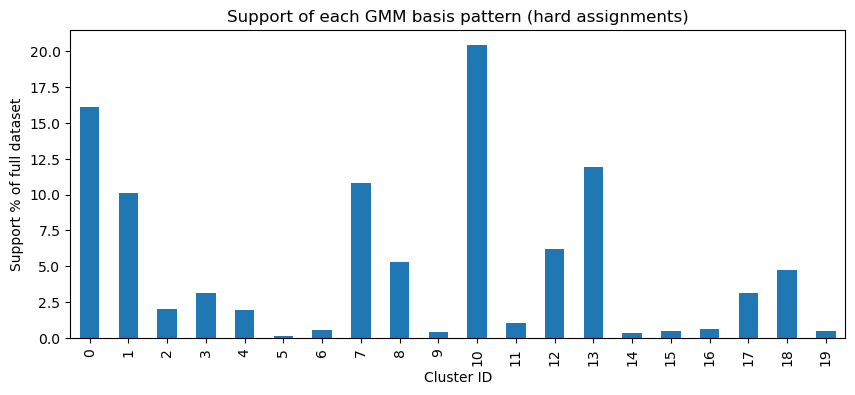

In [55]:
import matplotlib.pyplot as plt

cluster_counts = I_with_patterns["cluster"].value_counts(normalize=True).sort_index() * 100

plt.figure(figsize=(10,4))
cluster_counts.plot(kind="bar")
plt.ylabel("Support % of full dataset")
plt.xlabel("Cluster ID")
plt.title("Support of each GMM basis pattern (hard assignments)")
plt.show()


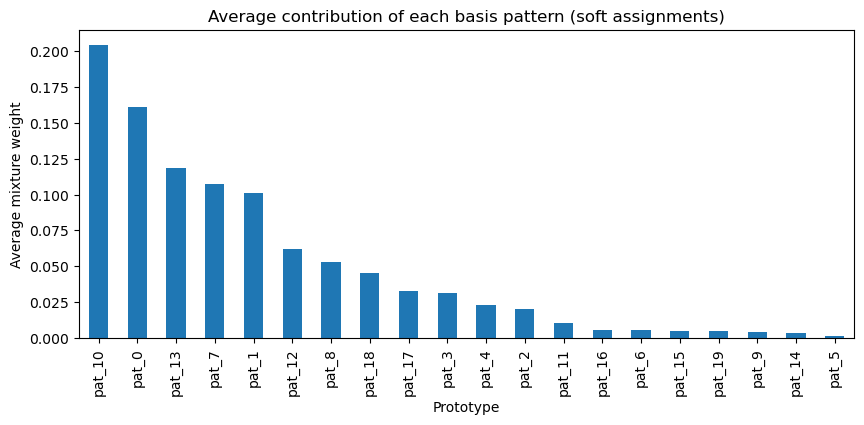

In [56]:
proba_cols = [c for c in I_with_patterns.columns if c.startswith("pat_")]

mean_weights = I_with_patterns[proba_cols].mean().sort_values(ascending=False)

plt.figure(figsize=(10,4))
mean_weights.plot(kind="bar")
plt.ylabel("Average mixture weight")
plt.xlabel("Prototype")
plt.title("Average contribution of each basis pattern (soft assignments)")
plt.show()


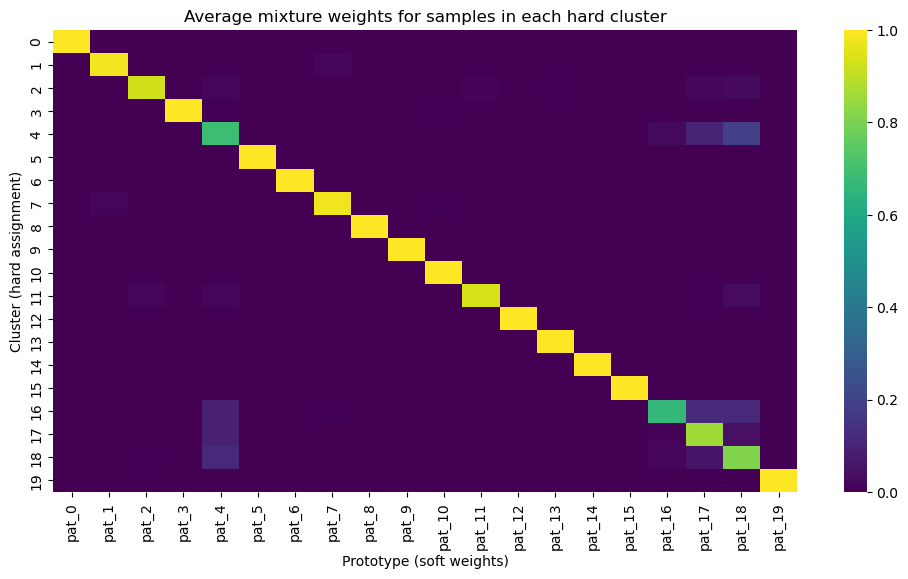

In [57]:
import seaborn as sns

avg_proba_per_cluster = I_with_patterns.groupby("cluster")[proba_cols].mean()

plt.figure(figsize=(12,6))
sns.heatmap(avg_proba_per_cluster, cmap="viridis", annot=False)
plt.title("Average mixture weights for samples in each hard cluster")
plt.xlabel("Prototype (soft weights)")
plt.ylabel("Cluster (hard assignment)")
plt.show()


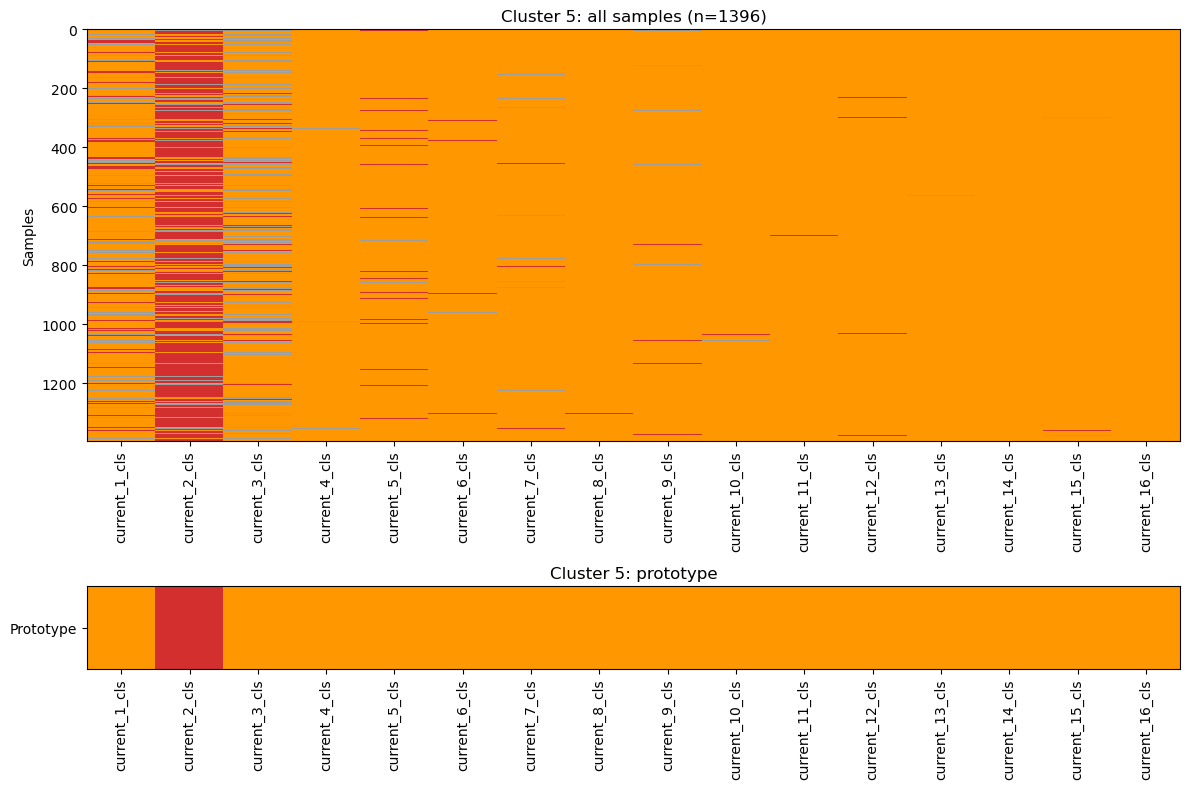

In [65]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

cluster_id = 5   # pick the cluster you want
feat_order = sorted([c for c in I_with_patterns.columns if c.startswith("current_")],
                    key=lambda c: int(c.split("_")[1]))

# subset rows belonging to that cluster
sub = I_with_patterns[I_with_patterns["cluster"] == cluster_id][feat_order].astype(int)

# prototype row
proto = sub.mode(dropna=False).iloc[0].values.reshape(1, -1)

# --- Plot ---
cmap = ListedColormap(["#9e9e9e", "#ff9800", "#d32f2f"])  # 0=gray, 1=orange, 2=red
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), gridspec_kw={"height_ratios":[5,1]})

# (A) all samples in cluster
axes[0].imshow(sub.values, aspect="auto", cmap=cmap, norm=norm, interpolation="nearest")
axes[0].set_title(f"Cluster {cluster_id}: all samples (n={len(sub)})")
axes[0].set_xticks(range(len(feat_order)))
axes[0].set_xticklabels(feat_order, rotation=90)
axes[0].set_ylabel("Samples")

# (B) prototype (mode)
axes[1].imshow(proto, aspect="auto", cmap=cmap, norm=norm, interpolation="nearest")
axes[1].set_xticks(range(len(feat_order)))
axes[1].set_xticklabels(feat_order, rotation=90)
axes[1].set_yticks([0]); axes[1].set_yticklabels(["Prototype"])
axes[1].set_title(f"Cluster {cluster_id}: prototype")

plt.tight_layout()
plt.show()


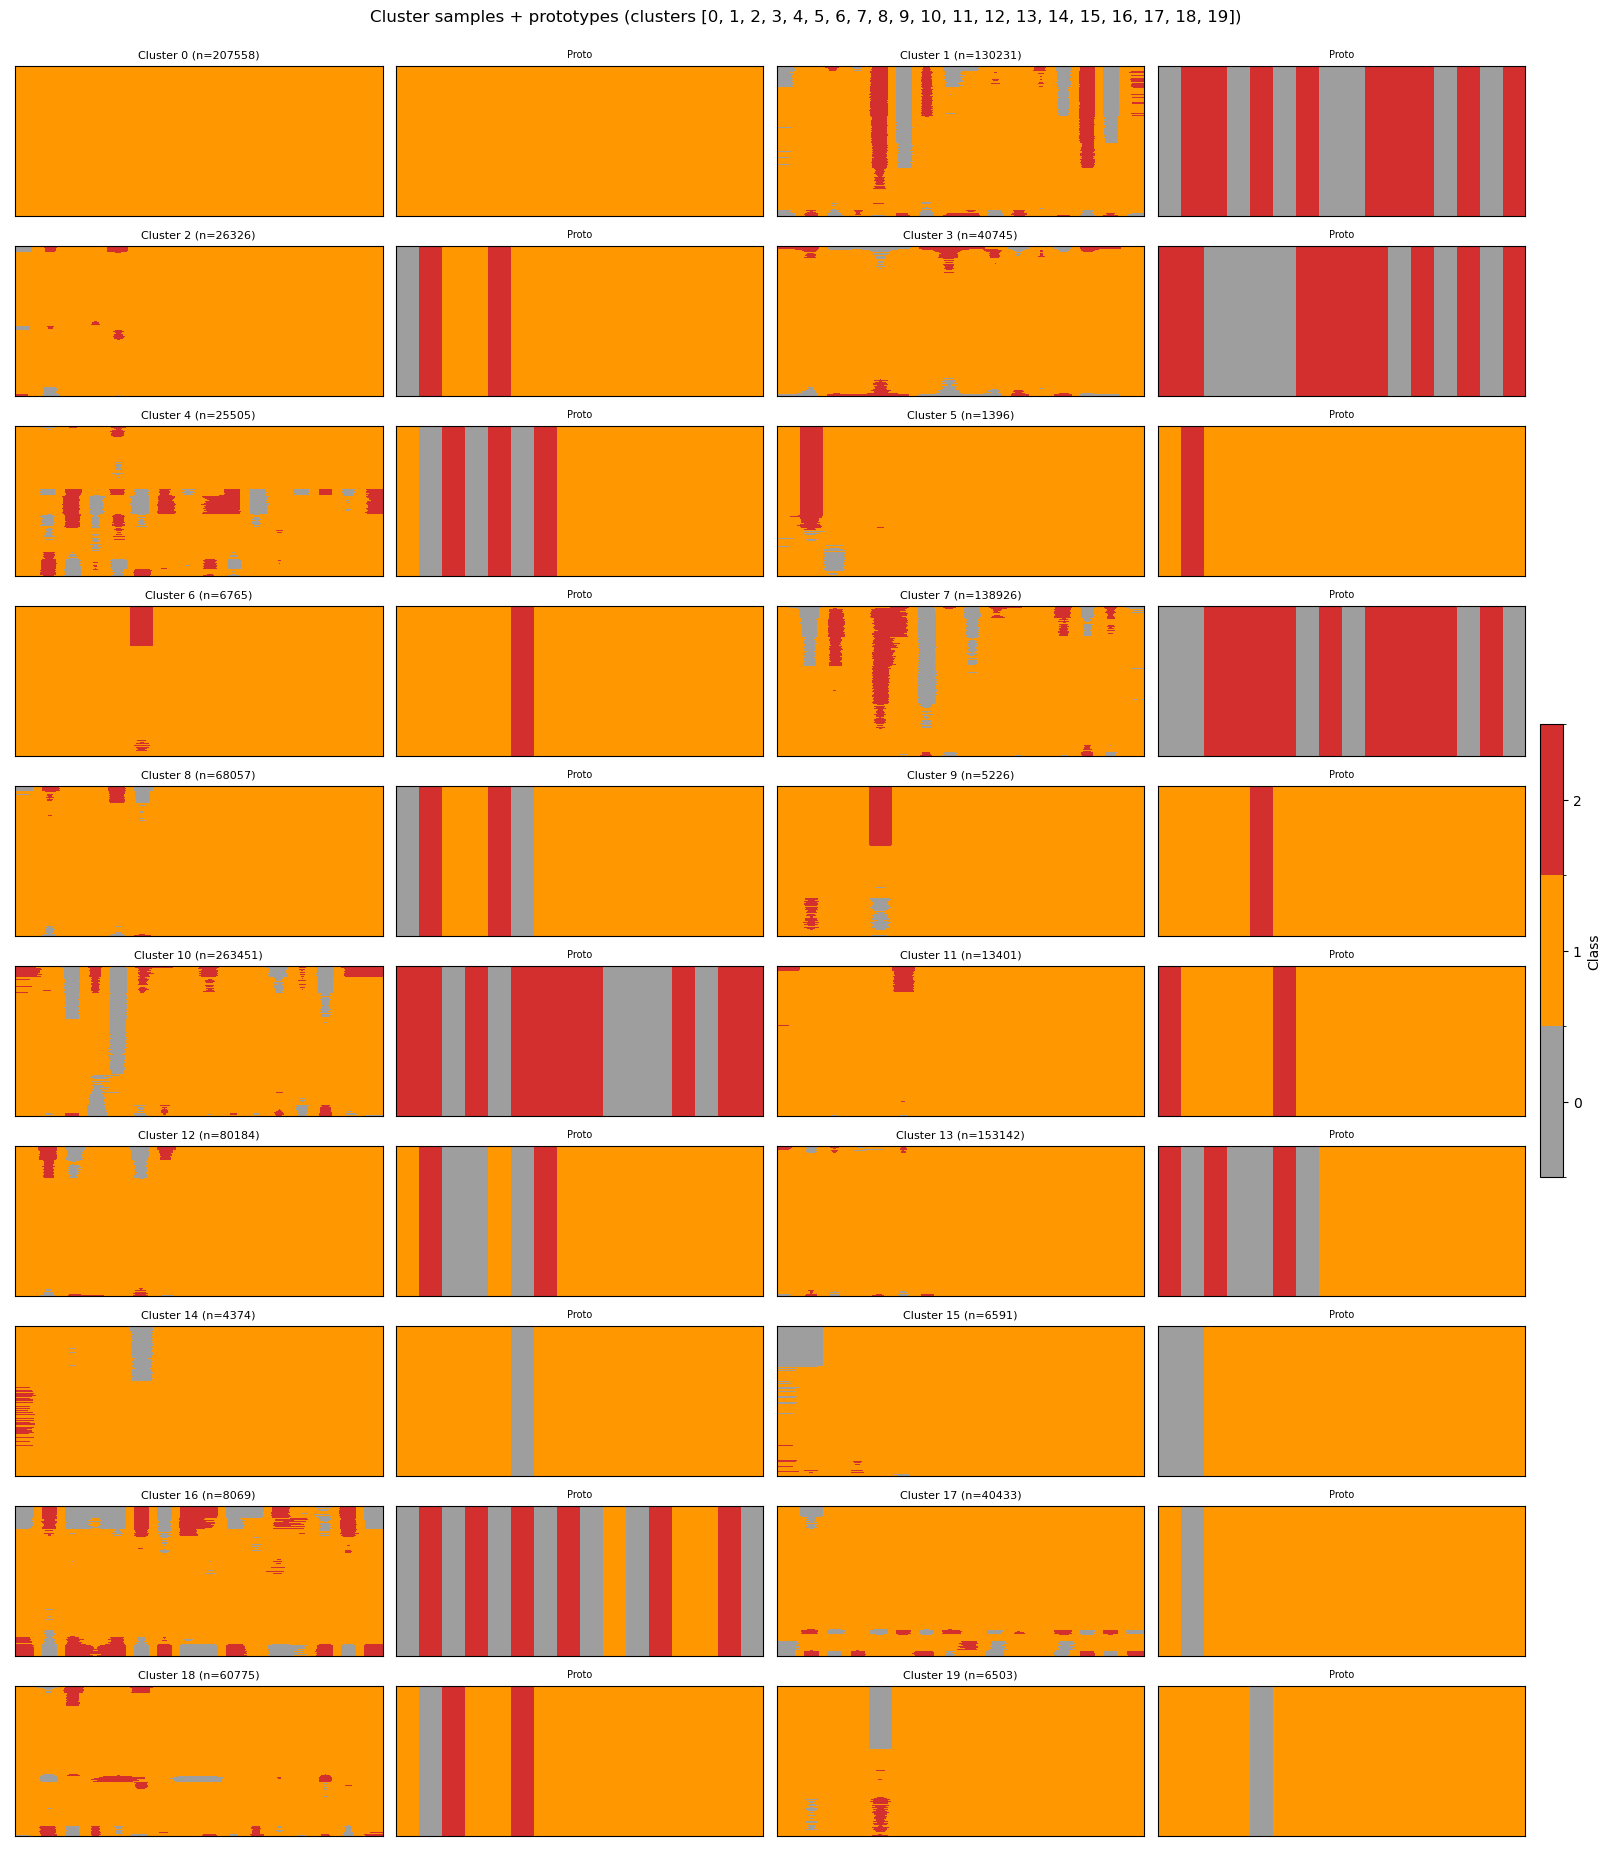

In [73]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

# config
MAX_ROWS_PER_CLUSTER = 1000000  # cap rows per cluster for readability
GRID_ROWS, GRID_COLS = 5, 4  # 4x4 grid per page
SORT_BY_SIMILARITY = True

feat_order = sorted([c for c in I_with_patterns.columns if c.startswith("current_")],
                    key=lambda c: int(c.split("_")[1]))
clusters = sorted(I_with_patterns["cluster"].unique())

cmap = ListedColormap(["#9e9e9e", "#ff9800", "#d32f2f"])
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)

def hamming(a, b):
    return (a != b).sum(axis=1)

# paginate over clusters
per_page = GRID_ROWS * GRID_COLS
for page_start in range(0, len(clusters), per_page):
    page_clusters = clusters[page_start:page_start+per_page]

    fig, axes = plt.subplots(GRID_ROWS*2, GRID_COLS, figsize=(4*GRID_COLS, 1.8*GRID_ROWS*2),
                             constrained_layout=True)
    axes = axes.ravel()

    last_im = None
    for j, cid in enumerate(page_clusters):
        sub = I_with_patterns[I_with_patterns["cluster"] == cid][feat_order].astype(int)
        proto = sub.mode(dropna=False).iloc[0].values.reshape(1, -1)

        # sort by similarity if desired
        if SORT_BY_SIMILARITY:
            d = hamming(sub.values, proto)
            order = np.argsort(d)
            sub = sub.iloc[order]

        # cap rows
        if len(sub) > MAX_ROWS_PER_CLUSTER:
            idx = np.random.choice(len(sub), size=MAX_ROWS_PER_CLUSTER, replace=False)
            sub = sub.iloc[idx]

        # pick positions: row=2*gridrow, row+1=prototype
        grid_pos = j*2
        ax_samples = axes[grid_pos]
        last_im = ax_samples.imshow(sub.values, aspect="auto", cmap=cmap, norm=norm)
        ax_samples.set_title(f"Cluster {cid} (n={len(sub)})", fontsize=8)
        ax_samples.set_xticks([]); ax_samples.set_yticks([])

        ax_proto = axes[grid_pos+1]
        ax_proto.imshow(proto, aspect="auto", cmap=cmap, norm=norm)
        ax_proto.set_xticks([]); ax_proto.set_yticks([])
        ax_proto.set_title("Proto", fontsize=7)

    # hide unused axes
    for ax in axes[len(page_clusters)*2:]:
        ax.axis("off")

    fig.colorbar(last_im, ax=axes, ticks=[0,1,2], fraction=0.015, pad=0.01, label="Class")
    fig.suptitle(f"Cluster samples + prototypes (clusters {page_clusters})", y=1.02)
    plt.show()


In [30]:
Y_soft.head()

,pat_0,pat_1,pat_2,pat_3,pat_4,pat_5,pat_6,pat_7,pat_8,pat_9,pat_10,pat_11,pat_12,pat_13,pat_14,pat_15,pat_16,pat_17,pat_18,pat_19
0,1.0,0.0,1.274793e-17,0.0,5.544864e-28,0.0,0.0,0.0,0.000000e+00,0.0,0.0,6.612444e-24,0.000000e+00,0.0,0.0,0.0,1.252761e-41,2.440567e-18,2.448054e-19,0.0
1,0.0,0.0,5.019338e-09,0.0,5.620128e-15,0.0,0.0,0.0,1.000000e+00,0.0,0.0,7.641373e-26,9.809089e-45,0.0,0.0,0.0,5.953941e-25,5.169662e-12,7.317964e-13,0.0
2,0.0,0.0,2.906027e-06,0.0,1.994967e-11,0.0,0.0,0.0,0.000000e+00,0.0,0.0,0.000000e+00,9.999971e-01,0.0,0.0,0.0,1.219233e-19,4.513328e-10,4.724652e-10,0.0
3,0.0,0.0,4.298860e-27,0.0,2.484897e-06,0.0,0.0,0.0,0.000000e+00,0.0,0.0,9.840893e-01,0.000000e+00,0.0,0.0,0.0,2.264839e-11,9.101342e-03,6.806883e-03,0.0
4,0.0,0.0,1.973551e-08,0.0,4.287194e-15,0.0,0.0,0.0,2.649660e-12,0.0,0.0,0.000000e+00,4.256599e-32,1.0,0.0,0.0,2.512135e-25,9.867977e-13,4.400651e-13,0.0


In [76]:
# pick 5 random rows
check_idx = np.random.choice(len(I), size=5, replace=False)

for idx in check_idx:
    print(f"\nRow {idx}")
    print("Original currents:", I.iloc[idx].to_numpy())
    print("Assigned cluster:", I_with_patterns.iloc[idx]["cluster"])
    print("Top-3 mixture weights:", 
          I_with_patterns.iloc[idx][[f"pat_{i}" for i in np.argsort(-I_with_patterns.iloc[idx][proba_cols].values)[:3]]])



Row 198527
Original currents: [0 2 0 2 2 0 0 2 2 0 2 0 0 1 2 0]
Assigned cluster: 1.0
Top-3 mixture weights: pat_1     9.999915e-01
pat_7     8.272699e-06
pat_18    1.012107e-07
Name: 198527, dtype: float64

Row 305627
Original currents: [1 2 0 2 0 2 0 2 1 2 1 1 2 1 1 1]
Assigned cluster: 13.0
Top-3 mixture weights: pat_13    9.998802e-01
pat_2     1.198364e-04
pat_17    6.855623e-09
Name: 305627, dtype: float64

Row 941836
Original currents: [2 2 0 2 0 2 2 0 0 0 2 0 2 1 0 2]
Assigned cluster: 10.0
Top-3 mixture weights: pat_10    9.999991e-01
pat_18    5.515275e-07
pat_4     2.854527e-07
Name: 941836, dtype: float64

Row 1187823
Original currents: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
Assigned cluster: 0.0
Top-3 mixture weights: pat_0     1.000000e+00
pat_2     2.608512e-18
pat_17    4.880699e-19
Name: 1187823, dtype: float64

Row 684324
Original currents: [2 0 2 2 0 0 2 2 0 2 1 0 1 1 1 1]
Assigned cluster: 13.0
Top-3 mixture weights: pat_13    1.000000e+00
pat_2     1.845464e-09
pat_17 

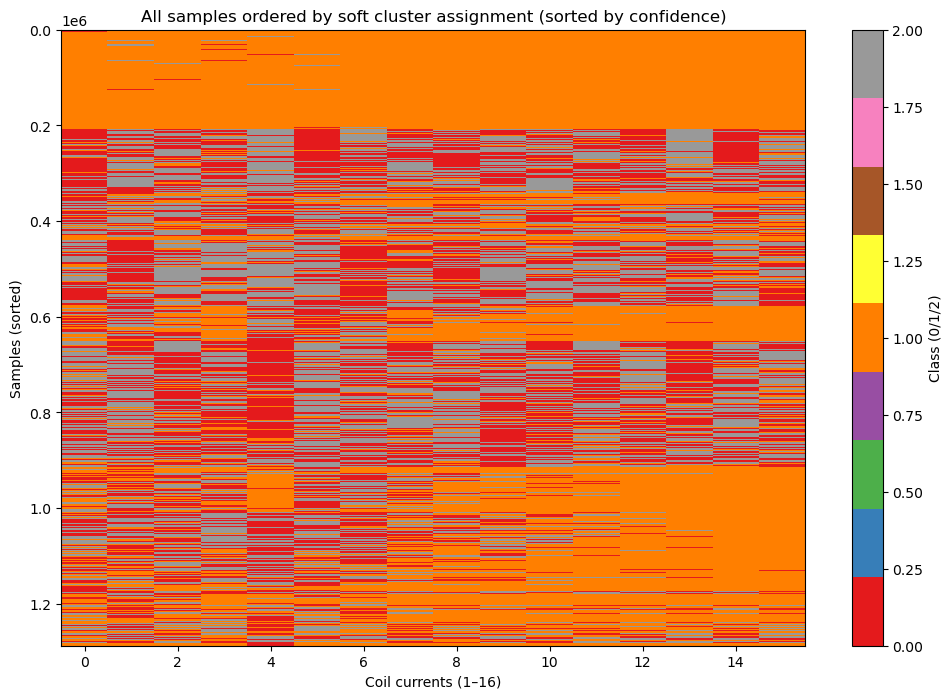

In [75]:
import numpy as np
import matplotlib.pyplot as plt

proba_cols = [c for c in I_with_patterns.columns if c.startswith("pat_")]
feat_cols  = sorted([c for c in I_with_patterns.columns if c.startswith("current_")],
                    key=lambda x: int(x.split("_")[1]))
W = I_with_patterns[proba_cols].to_numpy()    # [N, K]
Y = I_with_patterns[feat_cols].to_numpy()     # [N, 16]

# pick top cluster + confidence
top = W.argmax(axis=1)
conf = W.max(axis=1)

# sort samples: first by cluster, then by confidence (so "weak" assignments go to bottom)
order = np.lexsort((1-conf, top))  
Y_sorted = Y[order]
top_sorted = top[order]

# plot big heatmap
plt.figure(figsize=(12,8))
plt.imshow(Y_sorted, aspect="auto", cmap="Set1", interpolation="nearest")
plt.colorbar(label="Class (0/1/2)")
plt.title("All samples ordered by soft cluster assignment (sorted by confidence)")
plt.xlabel("Coil currents (1–16)")
plt.ylabel("Samples (sorted)")
plt.show()


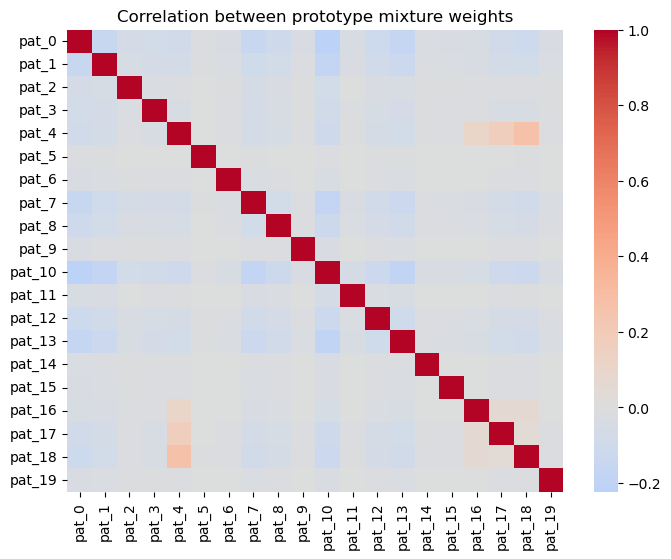

In [58]:
corr = I_with_patterns[proba_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation between prototype mixture weights")
plt.show()


In [42]:
import pandas as pd

# wrap the numpy array into a DataFrame with nice col names
X_umap10_df = pd.DataFrame(X_umap10, columns=[f"umap{i+1}" for i in range(X_umap10.shape[1])])

# save to disk (choose your path)
X_umap10_df.to_parquet("X_umap10.parquet", index=False)   # efficient binary format
# or
X_umap10_df.to_csv("X_umap10.csv", index=False)           # plain text, bigger

print("Saved:", X_umap10_df.shape)


ArrowKeyError: A type extension with name pandas.period already defined

In [82]:
import numpy as np

# your coil current columns
feat_cols = [c for c in I_with_patterns.columns if c.startswith("current_")]

# cluster labels
labels = I_with_patterns["cluster"].to_numpy()

# initialize prototype tensor: (clusters × coils × 3 classes)
D = np.zeros((gmm.n_components, len(feat_cols), 3))

for k in range(gmm.n_components):
    rows = I_with_patterns.loc[labels == k, feat_cols]
    if len(rows) == 0:
        continue
    for j, col in enumerate(feat_cols):
        vals = rows[col].values
        for c in [0, 1, 2]:
            D[k, j, c] = np.mean(vals == c)

print("D shape:", D.shape)  # should be (20, 16, 3)


D shape: (20, 16, 3)


In [83]:
import joblib, json, numpy as np, os

save_dir = "/media/alireza-linux/MagLev Simulator and Beyond/ML saved files"
os.makedirs(save_dir, exist_ok=True)

joblib.dump(svd,  os.path.join(save_dir, "svd_model.pkl"))
joblib.dump(um_hi, os.path.join(save_dir, "umap_model.pkl"))
joblib.dump(gmm,  os.path.join(save_dir, "gmm_model.pkl"))

np.save(os.path.join(save_dir, "soft_prototypes.npy"), D)

meta = {"features": feat_cols, "K": D.shape[0], "classes": [0,1,2]}
with open(os.path.join(save_dir, "training_meta.json"), "w") as f:
    json.dump(meta, f)

proba_cols = [c for c in I_with_patterns.columns if c.startswith("pat_")]
np.savez_compressed(
    os.path.join(save_dir, "assignments_full.npz"),
    labels=I_with_patterns["cluster"].to_numpy(),
    proba=I_with_patterns[proba_cols].to_numpy(dtype=np.float32),
)
